# Análisis Predictivo del Cáncer de Mama mediante Machine Learning

Este notebook desarrolla la parte experimental del TFM.  
El objetivo es construir, evaluar e interpretar modelos de aprendizaje automático para predecir la supervivencia a cinco años en pacientes diagnosticadas de cáncer de mama a partir de datos clínico-epidemiológicos.

In [ ]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

# 1. Carga y comprensión inicial del dataset

En esta sección se realiza la carga inicial del conjunto de datos procedente del programa SEER, así como una primera inspección de su estructura, tipos de variables y calidad general.

El objetivo de esta fase es comprender la naturaleza del dataset antes de aplicar cualquier transformación. Esta etapa resulta especialmente relevante en datos clínico-epidemiológicos, donde es habitual encontrar valores faltantes, códigos especiales, variables categóricas de alta cardinalidad y diferencias de disponibilidad entre periodos temporales.

El problema planteado en este trabajo se formula como una tarea de clasificación supervisada orientada a predecir la supervivencia a cinco años tras el diagnóstico de cáncer de mama.

## 1.1 Carga del dataset

El archivo original no contiene cabeceras, por lo que se asignan manualmente los nombres de las variables a partir de la documentación del dataset.

Para facilitar el análisis posterior, se utilizan nombres de columnas simplificados y consistentes, manteniendo el significado clínico de cada variable.

In [ ]:
import csv

columns = [
    "age_group",
    "sex",
    "race",
    "year_diagnosis",
    "marital_status",
    "primary_site",
    "histologic_type",
    "behavior_code",
    "tumor_size",
    "summary_stage",
    "eod_stage_group",
    "eod_t",
    "eod_n",
    "eod_m",
    "surgery_primary_site",
    "radiation",
    "chemotherapy",
    "vital_status",
    "survival_months",
    "seer_cause_specific_death"
]

df = pd.read_csv(
    "seer_breast_cancer.csv",
    header=None
)

df.columns = columns

df.head()

,age_group,sex,race,year_diagnosis,marital_status,primary_site,histologic_type,behavior_code,tumor_size,summary_stage,eod_stage_group,eod_t,eod_n,eod_m,surgery_primary_site,radiation,chemotherapy,vital_status,survival_months,seer_cause_specific_death
0,75-79 years,Female,White,2003,Divorced,506,8520,Malignant,Blank(s),Regional,Blank(s),Blank(s),Blank(s),Blank(s),22,None/Unknown,No/Unknown,Dead,0014,Dead (attributable to this cancer dx)
1,70-74 years,Female,Black,2010,Single (never married),509,8500,Malignant,Blank(s),Localized,Blank(s),Blank(s),Blank(s),Blank(s),80,Beam radiation,No/Unknown,Dead,0012,Alive or dead of other cause
2,70-74 years,Female,White,2018,Single (never married),508,8500,Malignant,024,Blank(s),2A,T2,N0,M0,22,Beam radiation,Yes,Alive,0059,Alive or dead of other cause
3,60-64 years,Female,White,2005,Widowed,501,8520,Malignant,Blank(s),Regional,Blank(s),Blank(s),Blank(s),Blank(s),41,None/Unknown,No/Unknown,Dead,0081,Dead (attributable to this cancer dx)
4,70-74 years,Female,White,2005,Widowed,509,8500,Malignant,Blank(s),Regional,Blank(s),Blank(s),Blank(s),Blank(s),41,None/Unknown,No/Unknown,Dead,0007,Alive or dead of other cause


## 1.2 Dimensiones del dataset

Se inspecciona el número de observaciones y variables disponibles. Esta primera comprobación permite verificar que la carga del archivo se ha realizado correctamente.

In [ ]:
print(f"Número de filas: {df.shape[0]:,}")
print(f"Número de columnas: {df.shape[1]}")

Número de filas: 1,365,329
Número de columnas: 20


## 1.3 Tipos de datos y valores no nulos

A continuación se revisan los tipos de datos inferidos por `pandas` y el número de valores no nulos por variable. Esta inspección inicial permite detectar columnas que requieren conversión de tipo, así como posibles valores faltantes.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1365329 entries, 0 to 1365328
Data columns (total 20 columns):
 #   Column                     Non-Null Count    Dtype 
---  ------                     --------------    ----- 
 0   age_group                  1365329 non-null  object
 1   sex                        1365329 non-null  object
 2   race                       1365329 non-null  object
 3   year_diagnosis             1365329 non-null  int64 
 4   marital_status             1365329 non-null  object
 5   primary_site               1365329 non-null  int64 
 6   histologic_type            1365329 non-null  int64 
 7   behavior_code              1365329 non-null  object
 8   tumor_size                 1365329 non-null  object
 9   summary_stage              1365329 non-null  object
 10  eod_stage_group            1365329 non-null  object
 11  eod_t                      1365329 non-null  object
 12  eod_n                      1365329 non-null  object
 13  eod_m                      

La inspección inicial muestra que el dataset contiene 1.365.329 observaciones y 20 variables. La mayoría de variables se han cargado como tipo `object`, lo que es coherente con la naturaleza categórica de gran parte de la información clínica, tumoral y de tratamiento. También existen cuatro variables cargadas como enteros: `year_diagnosis`, `primary_site`, `histologic_type` y `surgery_primary_site`.

No se observan valores nulos explícitos en ninguna columna. Sin embargo, esto no implica que el dataset esté libre de valores faltantes, ya que en registros clínico-epidemiológicos como SEER es habitual que la ausencia de información se codifique mediante etiquetas o códigos específicos.

La variable `survival_months`, aunque representa una magnitud temporal numérica, aparece inicialmente como tipo `object`. Esto se debe a que sus valores están codificados como texto, por ejemplo `0000`, `0001` o `0012`, y además contiene valores no numéricos como `Unknown`. Por tanto, será necesario convertirla cuidadosamente a formato numérico en la fase de limpieza.


## 1.4 Descripción de las variables

El conjunto de datos contiene variables demográficas, clínicas, tumorales, de tratamiento y de supervivencia. Estas variables permiten formular el problema desde una perspectiva pronóstica.

In [ ]:
variable_description = pd.DataFrame({
    "variable": [
        "age_group",
        "sex",
        "race",
        "year_diagnosis",
        "marital_status",
        "primary_site",
        "histologic_type",
        "behavior_code",
        "tumor_size",
        "summary_stage",
        "eod_stage_group",
        "eod_t",
        "eod_n",
        "eod_m",
        "surgery_primary_site",
        "radiation",
        "chemotherapy",
        "vital_status",
        "survival_months",
        "seer_cause_specific_death"
    ],
    "description": [
        "Grupo de edad del paciente en el momento del diagnóstico.",
        "Sexo del paciente.",
        "Raza o grupo étnico recodificado.",
        "Año de diagnóstico.",
        "Estado civil en el momento del diagnóstico.",
        "Localización primaria del tumor.",
        "Tipo histológico según la clasificación ICD-O-3.",
        "Código de comportamiento tumoral.",
        "Tamaño tumoral resumido.",
        "Estadio resumen del cáncer según Summary Stage 2000.",
        "Grupo de estadio derivado del sistema EOD 2018.",
        "Categoría T derivada del sistema EOD 2018.",
        "Categoría N derivada del sistema EOD 2018.",
        "Categoría M derivada del sistema EOD 2018.",
        "Código de cirugía realizada sobre el sitio primario.",
        "Tratamiento con radioterapia.",
        "Tratamiento con quimioterapia.",
        "Estado vital al cierre del estudio.",
        "Meses de supervivencia desde el diagnóstico.",
        "Indicador de muerte específica atribuible al cáncer diagnosticado."
    ],
    "group": [
        "Demográfica",
        "Demográfica",
        "Demográfica",
        "Temporal",
        "Demográfica",
        "Tumoral",
        "Tumoral",
        "Tumoral",
        "Tumoral",
        "Estadificación",
        "Estadificación",
        "Estadificación",
        "Estadificación",
        "Estadificación",
        "Tratamiento",
        "Tratamiento",
        "Tratamiento",
        "Resultado",
        "Resultado",
        "Resultado"
    ]
})

variable_description

,variable,description,group
0,age_group,Grupo de edad del paciente en el momento del d...,Demográfica
1,sex,Sexo del paciente.,Demográfica
2,race,Raza o grupo étnico recodificado.,Demográfica
3,year_diagnosis,Año de diagnóstico.,Temporal
4,marital_status,Estado civil en el momento del diagnóstico.,Demográfica
5,primary_site,Localización primaria del tumor.,Tumoral
6,histologic_type,Tipo histológico según la clasificación ICD-O-3.,Tumoral
7,behavior_code,Código de comportamiento tumoral.,Tumoral
8,tumor_size,Tamaño tumoral resumido.,Tumoral
9,summary_stage,Estadio resumen del cáncer según Summary Stage...,Estadificación


## 1.5 Inspección inicial de categorías

Se revisan las categorías más frecuentes de cada variable. Esta exploración permite identificar valores dominantes, códigos especiales, posibles valores faltantes codificados como texto y variables con alta cardinalidad.

In [ ]:
for col in df.columns:
    print(f"\n{'=' * 80}")
    print(col)
    print(f"{'=' * 80}")
    print(df[col].value_counts(dropna=False).head(15))


age_group
age_group
60-64 years    175222
65-69 years    173283
55-59 years    163428
50-54 years    149928
70-74 years    149915
45-49 years    127717
75-79 years    117985
40-44 years     83537
80-84 years     83319
85-89 years     48714
35-39 years     41241
90+ years       25072
30-34 years     18689
25-29 years      6125
20-24 years      1026
Name: count, dtype: int64

sex
sex
Female    1355045
Male        10284
Name: count, dtype: int64

race
race
White                            1088699
Black                             140776
Asian or Pacific Islander         118471
Unknown                             8777
American Indian/Alaska Native       8606
Name: count, dtype: int64

year_diagnosis
year_diagnosis
2021    72860
2022    71411
2019    70115
2018    67935
2017    66264
2016    64457
2015    64169
2020    63882
2014    62228
2013    61067
2012    59682
2011    58715
2009    56965
2010    56463
2008    55665
Name: count, dtype: int64

marital_status
marital_status
Married (inc

## 1.6 Resumen inicial de calidad del dato

Tras la inspección de categorías, se construye una tabla resumen con el tipo de dato, número de valores faltantes explícitos, porcentaje de valores faltantes y número de valores únicos por variable.

La tabla confirma que no existen valores nulos explícitos (`NaN`) en el dataset cargado. No obstante, esta revisión debe complementarse con una búsqueda de valores especiales, ya que muchas ausencias de información no aparecen como valores nulos, sino codificadas mediante etiquetas o códigos propios del registro SEER.

También se observa que algunas variables presentan alta cardinalidad, como `histologic_type`, `tumor_size` y `surgery_primary_site`, aspecto que deberá considerarse posteriormente durante la codificación de variables.


In [ ]:
quality_summary = pd.DataFrame({
    "variable": df.columns,
    "dtype": df.dtypes.astype(str).values,
    "n_missing": df.isna().sum().values,
    "pct_missing": (df.isna().mean().values * 100).round(4),
    "n_unique": df.nunique(dropna=False).values
})

quality_summary

,variable,dtype,n_missing,pct_missing,n_unique
0,age_group,object,0,0.0,20
1,sex,object,0,0.0,2
2,race,object,0,0.0,5
3,year_diagnosis,int64,0,0.0,23
4,marital_status,object,0,0.0,7
5,primary_site,int64,0,0.0,9
6,histologic_type,int64,0,0.0,189
7,behavior_code,object,0,0.0,1
8,tumor_size,object,0,0.0,290
9,summary_stage,object,0,0.0,5


## 1.7 Identificación de valores especiales

En registros clínico-epidemiológicos como SEER es habitual que determinados valores faltantes, desconocidos o no evaluables no estén representados como `NaN`, sino mediante códigos o etiquetas específicas.

Por este motivo, se identifican explícitamente algunos valores especiales observados durante la inspección inicial, como `Blank(s)`, `Unknown`, `Unknown/unstaged`, `99`, `999`, `TX` y `NX`.

Esta identificación es relevante porque estos valores no deben tratarse automáticamente como categorías clínicas ordinarias. Su tratamiento dependerá del significado de cada variable y de su utilidad para el modelado.


In [ ]:
special_values = [
    "Blank(s)",
    "Unknown",
    "Unknown/unstaged",
    "None",
    "99",
    "999",
    "TX",
    "NX"
]

special_values_summary = []

for col in df.columns:
    counts = df[col].astype(str).value_counts(dropna=False)

    for value in special_values:
        if value in counts.index:
            special_values_summary.append({
                "variable": col,
                "special_value": value,
                "count": counts[value],
                "percentage": round(counts[value] / len(df) * 100, 3)
            })

special_values_summary = pd.DataFrame(special_values_summary)

special_values_summary

,variable,special_value,count,percentage
0,race,Unknown,8777,0.643
1,marital_status,Unknown,66668,4.883
2,tumor_size,Blank(s),888405,65.069
3,tumor_size,999,26812,1.964
4,summary_stage,Blank(s),346203,25.357
5,summary_stage,Unknown/unstaged,25772,1.888
6,eod_stage_group,Blank(s),1019126,74.643
7,eod_stage_group,99,35651,2.611
8,eod_t,Blank(s),1019126,74.643
9,eod_t,TX,19347,1.417


## 1.8 Primeras observaciones

A partir de la comprensión inicial del dataset se identifican varios aspectos relevantes para las siguientes fases del análisis:

1. El dataset contiene 1.365.329 observaciones y 20 variables, por lo que se dispone de un volumen de datos amplio y adecuado para el desarrollo de modelos predictivos.

2. La mayoría de variables son categóricas o códigos clínicos, aunque algunas se han cargado como enteros por su codificación numérica, como `primary_site`, `histologic_type` y `surgery_primary_site`.

3. No se detectan valores nulos explícitos en la carga inicial. Sin embargo, existen valores especiales que representan ausencia de información o categorías no evaluables, por lo que la limpieza no puede basarse únicamente en `NaN`.

4. La variable `behavior_code` presenta un único valor, `Malignant`, en todas las observaciones. Por tanto, no aporta variabilidad predictiva y será eliminada antes del modelado.

5. La variable `survival_months` representa los meses de supervivencia desde el diagnóstico, pero se ha cargado como texto y contiene 6.052 registros con valor `Unknown`, equivalentes aproximadamente al 0,443 % del dataset.

6. La variable `sex` está fuertemente desbalanceada: 1.355.045 registros corresponden a pacientes mujeres y 10.284 a pacientes hombres. Dado que el cáncer de mama en hombres es poco frecuente pero clínicamente posible, su tratamiento deberá decidirse explícitamente.

7. La variable `tumor_size` presenta una proporción muy elevada de valores `Blank(s)`, con 888.405 registros, aproximadamente el 65,1 % del dataset. Además, el código `999` aparece en 26.812 registros, alrededor del 2,0 %. Esta variable requerirá un tratamiento específico antes de decidir su uso en el modelado.

8. La variable `summary_stage` contiene información general de estadificación, pero presenta 346.203 valores `Blank(s)`, aproximadamente el 25,4 %, y 25.772 valores `Unknown/unstaged`, aproximadamente el 1,9 %.

9. Las variables derivadas del sistema EOD 2018 (`eod_stage_group`, `eod_t`, `eod_n` y `eod_m`) presentan 1.019.126 valores `Blank(s)`, aproximadamente el 74,6 % del dataset. Esto sugiere que su disponibilidad está asociada al periodo temporal del registro.

10. Las variables relacionadas con supervivencia y estado vital (`survival_months`, `vital_status` y `seer_cause_specific_death`) deberán tratarse con especial cuidado. Son necesarias para definir la variable objetivo, pero no deben utilizarse posteriormente como variables predictoras, ya que podrían introducir fuga de información.

11. El dataset presenta alta cardinalidad en variables como `histologic_type`, con 189 categorías, `tumor_size`, con 290 valores distintos, y `surgery_primary_site`, con 48 categorías. Estas variables requerirán codificación adecuada y posiblemente agrupación o tratamiento específico en fases posteriores.


# 2. Limpieza inicial y preparación de variables

En esta sección se realiza una primera limpieza del dataset con el objetivo de corregir problemas básicos detectados durante la comprensión inicial de los datos.

Esta fase no corresponde todavía al preprocesamiento final para modelado, sino a una preparación inicial necesaria para poder analizar correctamente las variables principales del estudio.

Las tareas principales de esta sección son:

- Revisar y tratar registros incompletos o mal codificados.
- Convertir la variable `survival_months` a formato numérico.
- Analizar los registros con supervivencia desconocida.
- Eliminar variables sin variabilidad predictiva.
- Dejar documentadas las primeras decisiones metodológicas.

In [ ]:
df_clean = df.copy()

print(f"Dimensiones iniciales del dataset de trabajo: {df_clean.shape}")

Dimensiones iniciales del dataset de trabajo: (1365329, 20)


## 2.1 Revisión de registros incompletos

Aunque el dataset presenta muy pocos valores nulos explícitos, la inspección inicial mostró la existencia de una observación con valores faltantes en varias variables relacionadas con tratamiento, estado vital y supervivencia.

Antes de aplicar transformaciones adicionales, se identifican estos registros para evaluar si deben eliminarse.

In [ ]:
missing_rows = df_clean[df_clean.isna().any(axis=1)]

print(f"Número de filas con al menos un valor nulo explícito: {missing_rows.shape[0]}")

missing_rows

Número de filas con al menos un valor nulo explícito: 0


,age_group,sex,race,year_diagnosis,marital_status,primary_site,histologic_type,behavior_code,tumor_size,summary_stage,eod_stage_group,eod_t,eod_n,eod_m,surgery_primary_site,radiation,chemotherapy,vital_status,survival_months,seer_cause_specific_death


La comprobación confirma que no existen filas con valores nulos explícitos en el dataset de trabajo. Por tanto, la operación de eliminación de nulos no elimina ninguna observación.

Esta conclusión es importante porque indica que los problemas de calidad del dato se concentran principalmente en valores especiales codificados como texto o códigos clínicos, y no en valores `NaN` convencionales.


## 2.2 Conversión de la variable de supervivencia

La variable `survival_months` representa los meses de supervivencia desde el diagnóstico. Sin embargo, se ha cargado inicialmente como texto debido a que sus valores aparecen codificados con ceros a la izquierda y porque existen registros con valores no numéricos, como `Unknown`.

Para poder utilizar esta variable en la definición del objetivo del modelo, se convierte a formato numérico. Los valores que no puedan convertirse se transformarán en `NaN`.

In [ ]:
df_clean["survival_months_numeric"] = pd.to_numeric(
    df_clean["survival_months"],
    errors="coerce"
)

df_clean[["survival_months", "survival_months_numeric"]].head(10)

,survival_months,survival_months_numeric
0,0014,14.0
1,0012,12.0
2,0059,59.0
3,0081,81.0
4,0007,7.0
5,0260,260.0
6,0084,84.0
7,0050,50.0
8,0130,130.0
9,0028,28.0


Se comprueba cuántos registros no han podido convertirse correctamente a formato numérico. Estos casos corresponden a observaciones en las que la supervivencia no está informada de forma válida.

En este dataset, los registros no convertibles corresponden al valor `Unknown`.


In [ ]:
unknown_survival = df_clean[df_clean["survival_months_numeric"].isna()]

print(f"Registros con supervivencia no numérica: {unknown_survival.shape[0]:,}")
print(f"Porcentaje sobre el total: {unknown_survival.shape[0] / df_clean.shape[0] * 100:.3f}%")

df_clean.loc[df_clean["survival_months_numeric"].isna(), "survival_months"].value_counts(dropna=False)

Registros con supervivencia no numérica: 6,052
Porcentaje sobre el total: 0.443%


,count
survival_months,
Unknown,6052


Los 6.052 registros con supervivencia desconocida representan aproximadamente el 0,443 % del dataset de trabajo. Estos casos no permiten construir de forma fiable la variable objetivo de supervivencia a cinco años.

Por ello, se eliminan del dataset de trabajo. Esta decisión se justifica porque la variable `survival_months` es necesaria para definir el desenlace del problema supervisado. Mantener registros sin esta información impediría asignar correctamente la clase objetivo.


In [ ]:
rows_before = df_clean.shape[0]

df_clean = df_clean.dropna(subset=["survival_months_numeric"])

rows_after = df_clean.shape[0]

print(f"Filas antes de eliminar supervivencia desconocida: {rows_before:,}")
print(f"Filas después de eliminar supervivencia desconocida: {rows_after:,}")
print(f"Filas eliminadas: {rows_before - rows_after:,}")

Filas antes de eliminar supervivencia desconocida: 1,365,329
Filas después de eliminar supervivencia desconocida: 1,359,277
Filas eliminadas: 6,052


Una vez eliminados los registros sin supervivencia conocida, se sustituye la variable original `survival_months` por su versión numérica.

Tras la conversión, la variable presenta valores entre 0 y 275 meses, con una mediana de 78 meses. Esto confirma que existe un rango amplio de seguimiento y que la variable puede utilizarse para definir la supervivencia a cinco años.


In [ ]:
df_clean["survival_months"] = df_clean["survival_months_numeric"].astype(int)
df_clean = df_clean.drop(columns=["survival_months_numeric"])

df_clean["survival_months"].describe()

,survival_months
count,1.359277e+06
mean,9.392091e+01
std,7.242585e+01
min,0.000000e+00
25%,3.300000e+01
50%,7.800000e+01
75%,1.440000e+02
max,2.750000e+02


## 2.3 Revisión de variables sin variabilidad

Las variables que presentan un único valor en todas las observaciones no aportan información predictiva al modelo, ya que no permiten diferenciar entre pacientes.

Se identifican las variables con un único valor único después de la limpieza inicial.

In [ ]:
constant_columns = [
    col for col in df_clean.columns
    if df_clean[col].nunique(dropna=False) == 1
]

constant_columns

['behavior_code']

La variable `behavior_code` presenta un único valor, `Malignant`, en todas las observaciones. Esto es coherente con el hecho de que el dataset contiene casos de cáncer de mama maligno, pero implica que la variable no aporta variabilidad para el modelado.

Por tanto, se elimina del conjunto de datos de trabajo.

In [ ]:
df_clean = df_clean.drop(columns=constant_columns)

print(f"Variables eliminadas por ausencia de variabilidad: {constant_columns}")
print(f"Dimensiones tras eliminar variables constantes: {df_clean.shape}")

Variables eliminadas por ausencia de variabilidad: ['behavior_code']
Dimensiones tras eliminar variables constantes: (1359277, 19)


## 2.4 Revisión de la variable sexo

Aunque el cáncer de mama afecta mayoritariamente a mujeres, el dataset incluye también casos masculinos. Se analiza la distribución de la variable `sex` antes de decidir si se mantiene o se filtra.

Desde el punto de vista metodológico, mantener los casos masculinos permite conservar toda la información disponible y reconocer que el cáncer de mama también puede presentarse en hombres. No obstante, el fuerte desbalance deberá tenerse en cuenta en la interpretación de resultados.

In [ ]:
sex_distribution = (
    df_clean["sex"]
    .value_counts()
    .rename_axis("sex")
    .reset_index(name="count")
)

sex_distribution["percentage"] = (
    sex_distribution["count"] / len(df_clean) * 100
).round(3)

sex_distribution

,sex,count,percentage
0,Female,1349057,99.248
1,Male,10220,0.752


En este trabajo se mantienen tanto los casos femeninos como masculinos. Tras la limpieza inicial, el dataset contiene 1.349.057 registros femeninos, que representan el 99,248 %, y 10.220 registros masculinos, equivalentes al 0,752 %.

Esta decisión permite utilizar el conjunto completo de datos disponible y evita excluir una población clínicamente válida, aunque minoritaria. La variable `sex` se conservará inicialmente como predictor, y su posible influencia será evaluada posteriormente durante el análisis exploratorio y la interpretabilidad del modelo.


## 2.5 Revisión del rango temporal del dataset

Se analiza el rango de años de diagnóstico disponible. Esta comprobación es importante porque algunas variables clínicas, especialmente las derivadas del sistema EOD 2018, solo están disponibles en determinados periodos.

In [ ]:
print("Año mínimo de diagnóstico:", df_clean["year_diagnosis"].min())
print("Año máximo de diagnóstico:", df_clean["year_diagnosis"].max())

year_distribution = (
    df_clean["year_diagnosis"]
    .value_counts()
    .sort_index()
    .rename_axis("year_diagnosis")
    .reset_index(name="count")
)

year_distribution

Año mínimo de diagnóstico: 2000
Año máximo de diagnóstico: 2022


,year_diagnosis,count
0,2000,50785
1,2001,51811
2,2002,51581
3,2003,49674
4,2004,50593
5,2005,50995
6,2006,51753
7,2007,54025
8,2008,55459
9,2009,56749


## 2.6 Disponibilidad temporal de variables EOD 2018

Las variables `eod_stage_group`, `eod_t`, `eod_n` y `eod_m` presentan una proporción elevada de valores `Blank(s)`. Esto puede deberse a que estas variables no están disponibles para todos los años del dataset.

Se analiza el porcentaje de valores `Blank(s)` por año de diagnóstico para comprobar si la ausencia de información está asociada al periodo temporal.

In [ ]:
eod_cols = ["eod_stage_group", "eod_t", "eod_n", "eod_m"]

eod_blank_by_year = (
    df_clean
    .assign(eod_stage_blank=df_clean["eod_stage_group"].eq("Blank(s)"))
    .groupby("year_diagnosis")["eod_stage_blank"]
    .mean()
    .mul(100)
    .round(2)
    .rename("pct_blank_eod_stage_group")
    .reset_index()
)

eod_blank_by_year

,year_diagnosis,pct_blank_eod_stage_group
0,2000,100.0
1,2001,100.0
2,2002,100.0
3,2003,100.0
4,2004,100.0
5,2005,100.0
6,2006,100.0
7,2007,100.0
8,2008,100.0
9,2009,100.0


El análisis temporal confirma que las variables derivadas del sistema EOD 2018 (`eod_stage_group`, `eod_t`, `eod_n` y `eod_m`) presentan un 100 % de valores `Blank(s)` entre los años 2000 y 2017, mientras que están disponibles a partir de 2018.

Esto indica que la ausencia de información no es aleatoria, sino que está determinada por el periodo de diagnóstico y por la disponibilidad del sistema de estadificación en el registro.

Por este motivo, estas variables no se utilizarán en el modelo principal entrenado sobre el periodo completo 2000–2022. Incluirlas directamente podría introducir un sesgo temporal, ya que el modelo podría aprender diferencias asociadas al año de diagnóstico o a la disponibilidad del sistema EOD 2018, en lugar de patrones clínicos generales.

Las variables EOD 2018 podrían analizarse posteriormente en un análisis secundario limitado al periodo 2018–2022, pero quedan excluidas del modelo principal.


In [ ]:
eod_cols = ["eod_stage_group", "eod_t", "eod_n", "eod_m"]

df_clean = df_clean.drop(columns=eod_cols)

print(f"Variables EOD 2018 eliminadas del modelo principal: {eod_cols}")
print(f"Dimensiones tras eliminar variables EOD 2018: {df_clean.shape}")

Variables EOD 2018 eliminadas del modelo principal: ['eod_stage_group', 'eod_t', 'eod_n', 'eod_m']
Dimensiones tras eliminar variables EOD 2018: (1359277, 15)


## 2.7 Resumen tras la limpieza inicial

Tras esta primera fase de limpieza y preparación:

- Se ha comprobado que no existen valores nulos explícitos en el dataset de trabajo, por lo que no se eliminan filas por este motivo.
- Se ha convertido `survival_months` a formato numérico.
- Se han eliminado 6.052 registros con supervivencia desconocida (`Unknown`), equivalentes aproximadamente al 0,443 % del dataset inicial.
- Se ha eliminado la variable `behavior_code` por no presentar variabilidad, ya que todos los casos están codificados como `Malignant`.
- Se ha decidido mantener los casos masculinos, que representan aproximadamente el 0,752 % tras la limpieza inicial.
- Se ha analizado el rango temporal del dataset, que abarca diagnósticos entre 2000 y 2022.
- Se ha comprobado que las variables EOD 2018 solo están disponibles desde 2018 en adelante.
- Se han eliminado `eod_stage_group`, `eod_t`, `eod_n` y `eod_m` del modelo principal para evitar sesgo temporal y problemas de disponibilidad estructural.

Tras estas operaciones, el dataset de trabajo contiene 1.359.277 observaciones y 15 variables. El dataset resultante queda preparado para la siguiente fase: la definición formal de la variable objetivo de supervivencia a cinco años.


# 3. Definición de la variable objetivo

El objetivo predictivo de este trabajo es estimar la supervivencia a cinco años tras el diagnóstico de cáncer de mama.

Para ello, se construye una variable binaria que indica si la paciente ha sobrevivido al menos 60 meses desde el diagnóstico.

La definición de esta variable requiere especial cuidado, ya que en los datos clínicos pueden existir casos censurados. En particular, los pacientes que siguen vivos pero tienen menos de 60 meses de seguimiento no pueden clasificarse de forma fiable como supervivientes o no supervivientes a cinco años.

Por este motivo, se aplica el siguiente criterio:

- `1`: pacientes con supervivencia igual o superior a 60 meses.
- `0`: pacientes fallecidos antes de alcanzar los 60 meses.
- No clasificables: pacientes vivos con menos de 60 meses de seguimiento.

Los casos no clasificables se excluyen del modelado supervisado, ya que no permiten asignar una etiqueta objetivo fiable.

## 3.1 Revisión de las variables de desenlace

Antes de construir la variable objetivo, se revisan las variables relacionadas con supervivencia y estado vital:

- `survival_months`: meses de supervivencia desde el diagnóstico.
- `vital_status`: estado vital al cierre del estudio.
- `seer_cause_specific_death`: indicador de muerte específica atribuible al cáncer diagnosticado.

Estas variables son necesarias para definir el desenlace, pero no deberán utilizarse posteriormente como variables predictoras, ya que contienen información directa sobre el resultado final.

In [ ]:
df_clean[["survival_months", "vital_status", "seer_cause_specific_death"]].head()

,survival_months,vital_status,seer_cause_specific_death
0,14,Dead,Dead (attributable to this cancer dx)
1,12,Dead,Alive or dead of other cause
2,59,Alive,Alive or dead of other cause
3,81,Dead,Dead (attributable to this cancer dx)
4,7,Dead,Alive or dead of other cause


In [ ]:
print("Distribución de vital_status:")
display(df_clean["vital_status"].value_counts(dropna=False))

print("\nDistribución de seer_cause_specific_death:")
display(df_clean["seer_cause_specific_death"].value_counts(dropna=False))

print("\nResumen de survival_months:")
display(df_clean["survival_months"].describe())

Distribución de vital_status:


,count
vital_status,
Alive,920439
Dead,438838



Distribución de seer_cause_specific_death:


,count
seer_cause_specific_death,
Alive or dead of other cause,1152840
Dead (attributable to this cancer dx),199648
Dead (missing/unknown COD),6789



Resumen de survival_months:


,survival_months
count,1.359277e+06
mean,9.392091e+01
std,7.242585e+01
min,0.000000e+00
25%,3.300000e+01
50%,7.800000e+01
75%,1.440000e+02
max,2.750000e+02


Tras la limpieza inicial, el dataset contiene 920.439 pacientes vivos y 438.838 pacientes fallecidos. La variable de muerte específica indica 199.648 fallecimientos atribuibles al cáncer diagnosticado, 6.789 fallecimientos con causa desconocida y 1.152.840 casos vivos o fallecidos por otras causas.

Estas variables son necesarias para definir el desenlace, pero no deberán utilizarse posteriormente como variables predictoras, ya que contienen información directa sobre el resultado final.

## 3.2 Identificación de casos censurados

Para construir una variable objetivo válida, se identifican los pacientes vivos con menos de 60 meses de seguimiento.

Estos registros no deben considerarse como no supervivientes a cinco años, ya que el hecho de tener menos de 60 meses registrados puede deberse simplemente a que el seguimiento disponible todavía no ha alcanzado ese horizonte temporal.

In [ ]:
censored_less_60 = (
    (df_clean["vital_status"] == "Alive") &
    (df_clean["survival_months"] < 60)
)

n_censored_less_60 = censored_less_60.sum()
pct_censored_less_60 = n_censored_less_60 / len(df_clean) * 100

print(f"Pacientes vivos con menos de 60 meses de seguimiento: {n_censored_less_60:,}")
print(f"Porcentaje sobre el dataset limpio: {pct_censored_less_60:.2f}%")

Pacientes vivos con menos de 60 meses de seguimiento: 330,544
Porcentaje sobre el dataset limpio: 24.32%


In [ ]:
censored_by_year = (
    df_clean
    .assign(censored_less_60=censored_less_60)
    .groupby("year_diagnosis")["censored_less_60"]
    .mean()
    .mul(100)
    .round(2)
    .rename("pct_alive_less_60_months")
    .reset_index()
)

censored_by_year

,year_diagnosis,pct_alive_less_60_months
0,2000,0.54
1,2001,0.60
2,2002,0.69
3,2003,0.74
4,2004,0.78
5,2005,0.76
6,2006,0.83
7,2007,0.98
8,2008,1.09
9,2009,1.29


La revisión identifica 330.544 pacientes vivos con menos de 60 meses de seguimiento, lo que representa el 24,32 % del dataset limpio. Estos registros no deben etiquetarse como no supervivientes, ya que su seguimiento no permite confirmar el desenlace a cinco años.

El análisis por año de diagnóstico muestra que este problema se concentra especialmente en los años recientes. Entre 2000 y 2017 el porcentaje de pacientes vivos con menos de 60 meses es reducido, mientras que a partir de 2018 aumenta de forma muy marcada: 84,22 % en 2018, 87,37 % en 2019, 90,30 % en 2020, 93,96 % en 2021 y 97,50 % en 2022.

Este resultado es metodológicamente esperable, ya que los casos diagnosticados en años cercanos al cierre del estudio tienen menor tiempo potencial de observación. Incluirlos directamente como no supervivientes generaría un sesgo importante en la variable objetivo.


## 3.3 Construcción de la variable objetivo

Se construye la variable `survived_5_years` siguiendo el criterio definido:

- Valor `1`: supervivencia igual o superior a 60 meses.
- Valor `0`: fallecimiento antes de 60 meses.
- Valor faltante: paciente vivo con menos de 60 meses de seguimiento.

Posteriormente, los casos con variable objetivo no clasificable se eliminan del dataset utilizado para modelado.

In [ ]:
df_model = df_clean.copy()

df_model["survived_5_years"] = np.nan

df_model.loc[
    df_model["survival_months"] >= 60,
    "survived_5_years"
] = 1

df_model.loc[
    (df_model["survival_months"] < 60) &
    (df_model["vital_status"] == "Dead"),
    "survived_5_years"
] = 0

df_model["survived_5_years"].value_counts(dropna=False)

,count
survived_5_years,
1.0,803498
NaN,330544
0.0,225235


La construcción inicial de `survived_5_years` genera 803.498 pacientes clasificados como supervivientes a cinco años, 225.235 pacientes fallecidos antes de alcanzar los 60 meses y 330.544 casos no clasificables.

Los valores faltantes en `survived_5_years` corresponden a pacientes vivos con menos de 60 meses de seguimiento. Estos registros se excluyen del conjunto de modelado, ya que su desenlace a cinco años no puede determinarse de forma fiable con la información disponible.


In [ ]:
rows_before = df_model.shape[0]

df_model = df_model.dropna(subset=["survived_5_years"])

df_model["survived_5_years"] = df_model["survived_5_years"].astype(int)

rows_after = df_model.shape[0]

print(f"Filas antes de eliminar casos no clasificables: {rows_before:,}")
print(f"Filas después de eliminar casos no clasificables: {rows_after:,}")
print(f"Filas eliminadas: {rows_before - rows_after:,}")

Filas antes de eliminar casos no clasificables: 1,359,277
Filas después de eliminar casos no clasificables: 1,028,733
Filas eliminadas: 330,544


## 3.4 Distribución de la variable objetivo

Una vez definida la variable objetivo, se analiza su distribución. Esta comprobación permite identificar si existe desbalance entre las clases, aspecto relevante para la selección de métricas y modelos.

In [ ]:
target_distribution = (
    df_model["survived_5_years"]
    .value_counts()
    .sort_index()
    .rename_axis("survived_5_years")
    .reset_index(name="count")
)

target_distribution["percentage"] = (
    target_distribution["count"] / len(df_model) * 100
).round(2)

target_distribution

,survived_5_years,count,percentage
0,0,225235,21.89
1,1,803498,78.11


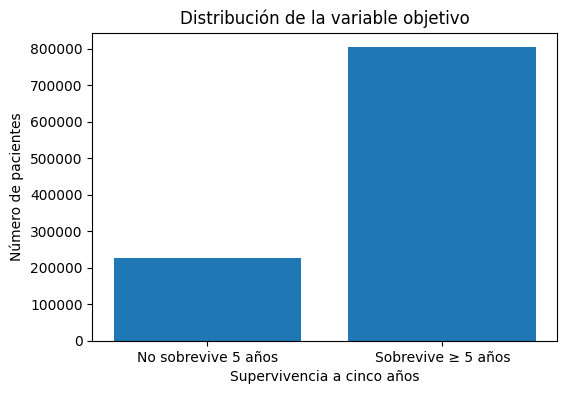

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6, 4))
plt.bar(
    target_distribution["survived_5_years"].astype(str),
    target_distribution["count"]
)
plt.title("Distribución de la variable objetivo")
plt.xlabel("Supervivencia a cinco años")
plt.ylabel("Número de pacientes")
plt.xticks(
    ticks=[0, 1],
    labels=["No sobrevive 5 años", "Sobrevive ≥ 5 años"]
)
plt.show()

El dataset de modelado contiene 1.028.733 observaciones: 225.235 pacientes no supervivientes a cinco años y 803.498 pacientes supervivientes a cinco años.


## 3.5 Revisión de la variable objetivo por año de diagnóstico

La variable objetivo presenta un desbalance moderado: el 21,89 % de los casos corresponden a no supervivencia a cinco años y el 78,11 % a supervivencia igual o superior a cinco años.

Se analiza también la distribución de la variable objetivo según el año de diagnóstico. Esta revisión permite comprobar si la exclusión de casos censurados afecta de forma desigual a los años más recientes.


In [ ]:
target_by_year = (
    df_model
    .groupby("year_diagnosis")["survived_5_years"]
    .value_counts(normalize=True)
    .mul(100)
    .rename("percentage")
    .reset_index()
)

target_by_year.head()

,year_diagnosis,survived_5_years,percentage
0,2000,1,78.027003
1,2000,0,21.972997
2,2001,1,78.827596
3,2001,0,21.172404
4,2002,1,79.076623


In [ ]:
target_by_year_pivot = target_by_year.pivot(
    index="year_diagnosis",
    columns="survived_5_years",
    values="percentage"
)

target_by_year_pivot

survived_5_years,0,1
year_diagnosis,,
2000,21.972997,78.027003
2001,21.172404,78.827596
2002,20.923377,79.076623
2003,20.983247,79.016753
2004,20.646652,79.353348
2005,20.336706,79.663294
2006,19.547173,80.452827
2007,19.482923,80.517077
2008,19.379068,80.620932


La distribución por año muestra un patrón relevante. Entre 2000 y 2017 la proporción de supervivencia a cinco años se sitúa aproximadamente entre el 78 % y el 82 %, con una proporción de no supervivencia cercana al 18 %–22 %.

En cambio, para los años 2018–2022 solo aparecen casos etiquetados como `0` tras la exclusión de pacientes vivos con menos de 60 meses de seguimiento. Esto ocurre porque, para esos años recientes, los pacientes vivos todavía no han podido acumular 60 meses de seguimiento, mientras que los fallecimientos tempranos sí pueden observarse.

Por este motivo, los años 2018–2022 introducen una distorsión temporal importante si se mantienen en el modelo principal. En la siguiente fase deberá valorarse excluir estos años del conjunto de modelado principal o realizar un análisis específico limitado a años con seguimiento suficiente.


## 3.6 Eliminación de variables de desenlace para evitar fuga de información

Una vez construida la variable objetivo, las variables utilizadas para definirla no deben formar parte del conjunto de predictores.

En concreto, se excluyen:

- `survival_months`
- `vital_status`
- `seer_cause_specific_death`

Estas variables contienen información posterior al diagnóstico o directamente relacionada con el desenlace, por lo que su inclusión en el modelo produciría fuga de información y una evaluación artificialmente optimista.

In [ ]:
outcome_columns = [
    "survival_months",
    "vital_status",
    "seer_cause_specific_death"
]

df_model = df_model.drop(columns=outcome_columns)

print(f"Variables de desenlace eliminadas: {outcome_columns}")
print(f"Dimensiones del dataset de modelado: {df_model.shape}")

Variables de desenlace eliminadas: ['survival_months', 'vital_status', 'seer_cause_specific_death']
Dimensiones del dataset de modelado: (1028733, 13)


Tras esta eliminación, el dataset de modelado conserva únicamente variables disponibles antes o durante el diagnóstico/tratamiento inicial, junto con la variable objetivo `survived_5_years`.

## 3.7 Resumen de la definición del objetivo

En esta sección se ha definido la variable objetivo `survived_5_years`, que representa la supervivencia a cinco años tras el diagnóstico.

La construcción de esta variable se ha realizado teniendo en cuenta la censura de seguimiento:

- Los pacientes con supervivencia igual o superior a 60 meses se etiquetan como supervivientes a cinco años.
- Los pacientes fallecidos antes de 60 meses se etiquetan como no supervivientes a cinco años.
- Los pacientes vivos con menos de 60 meses de seguimiento se excluyen por no disponer de desenlace confirmado.

Como resultado, se eliminan 330.544 casos no clasificables y el dataset de modelado queda formado por 1.028.733 observaciones. La variable objetivo presenta un 21,89 % de casos de no supervivencia a cinco años y un 78,11 % de casos de supervivencia a cinco años.

Además, se han eliminado `survival_months`, `vital_status` y `seer_cause_specific_death` para evitar fuga de información.

Un punto metodológico importante detectado en esta sección es que los años 2018–2022 quedan representados únicamente por fallecimientos tempranos tras eliminar los casos censurados vivos. Por tanto, antes del modelado será necesario tomar una decisión sobre el rango temporal final del análisis, especialmente para evitar sesgo asociado al seguimiento insuficiente en los años recientes.


<Figure size 1000x500 with 0 Axes>

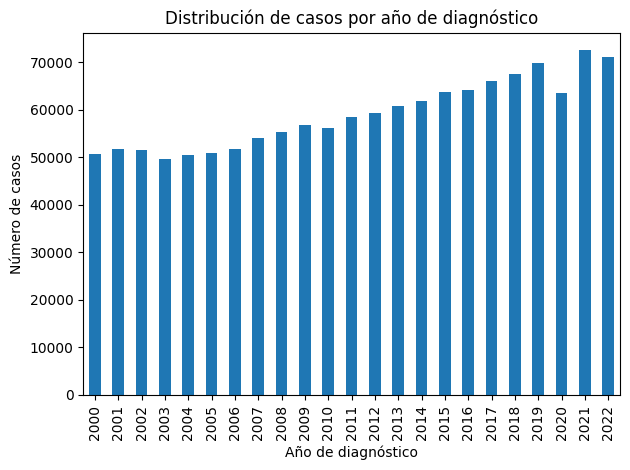

In [ ]:
plt.figure(figsize=(10, 5))
year_distribution.plot(
    x="year_diagnosis",
    y="count",
    kind="bar",
    legend=False
)
plt.title("Distribución de casos por año de diagnóstico")
plt.xlabel("Año de diagnóstico")
plt.ylabel("Número de casos")
plt.tight_layout()
plt.savefig("figuras/distribucion_anual_diagnosticos.png", dpi=300)
plt.show()

# 4. Análisis exploratorio de datos

Una vez construida la variable objetivo `survived_5_years` y eliminadas las variables que podrían producir fuga de información, se realiza un análisis exploratorio orientado al problema predictivo.

El objetivo de esta fase es estudiar la distribución de las variables disponibles, analizar su relación con la supervivencia a cinco años e identificar posibles patrones, desequilibrios o problemas que deban tenerse en cuenta antes del modelado.

Este análisis se centra en tres bloques principales:

- Distribución general del dataset de modelado.
- Análisis de variables demográficas.
- Análisis de variables clínicas, tumorales y de tratamiento.

## 4.1 Revisión del dataset de modelado

Antes de comenzar el análisis exploratorio, se revisa la estructura del dataset que se utilizará en las siguientes fases. Este dataset ya contiene la variable objetivo y no incluye variables directamente relacionadas con el desenlace, como `survival_months`, `vital_status` o `seer_cause_specific_death`.

In [ ]:
print(f"Número de filas del dataset de modelado: {df_model.shape[0]:,}")
print(f"Número de columnas del dataset de modelado: {df_model.shape[1]}")

df_model.head()

Número de filas del dataset de modelado: 1,028,733
Número de columnas del dataset de modelado: 13


,age_group,sex,race,year_diagnosis,marital_status,primary_site,histologic_type,tumor_size,summary_stage,surgery_primary_site,radiation,chemotherapy,survived_5_years
0,75-79 years,Female,White,2003,Divorced,506,8520,Blank(s),Regional,22,None/Unknown,No/Unknown,0
1,70-74 years,Female,Black,2010,Single (never married),509,8500,Blank(s),Localized,80,Beam radiation,No/Unknown,0
3,60-64 years,Female,White,2005,Widowed,501,8520,Blank(s),Regional,41,None/Unknown,No/Unknown,1
4,70-74 years,Female,White,2005,Widowed,509,8500,Blank(s),Regional,41,None/Unknown,No/Unknown,0
5,40-44 years,Female,White,2001,Married (including common law),504,8513,Blank(s),Localized,23,Beam radiation,Yes,1


In [ ]:
df_model.info()

<class 'pandas.core.frame.DataFrame'>
Index: 1028733 entries, 0 to 1365328
Data columns (total 13 columns):
 #   Column                Non-Null Count    Dtype 
---  ------                --------------    ----- 
 0   age_group             1028733 non-null  object
 1   sex                   1028733 non-null  object
 2   race                  1028733 non-null  object
 3   year_diagnosis        1028733 non-null  int64 
 4   marital_status        1028733 non-null  object
 5   primary_site          1028733 non-null  int64 
 6   histologic_type       1028733 non-null  int64 
 7   tumor_size            1028733 non-null  object
 8   summary_stage         1028733 non-null  object
 9   surgery_primary_site  1028733 non-null  int64 
 10  radiation             1028733 non-null  object
 11  chemotherapy          1028733 non-null  object
 12  survived_5_years      1028733 non-null  int64 
dtypes: int64(5), object(8)
memory usage: 109.9+ MB


## 4.2 Distribución de la variable objetivo

Aunque la variable objetivo ya fue construida en el apartado anterior, se analiza de nuevo al inicio del análisis exploratorio porque constituye el eje del problema predictivo.

La distribución de `survived_5_years` permite comprobar cuántos pacientes alcanzan el umbral de supervivencia a cinco años y cuántos fallecen antes de dicho horizonte temporal. Esta revisión es especialmente importante porque un posible desbalance entre clases puede condicionar la elección de métricas, la estrategia de entrenamiento y la interpretación de los modelos.

In [ ]:
target_distribution = (
    df_model["survived_5_years"]
    .value_counts()
    .sort_index()
    .rename_axis("survived_5_years")
    .reset_index(name="count")
)

target_distribution["percentage"] = (
    target_distribution["count"] / len(df_model) * 100
).round(2)

target_distribution

,survived_5_years,count,percentage
0,0,225235,21.89
1,1,803498,78.11


La variable objetivo presenta un desbalance moderado entre clases. De los 1.028.733 registros incluidos en el dataset de modelado, 803.498 pacientes alcanzan la supervivencia a cinco años, lo que representa el 78,11 % del total. Por el contrario, 225.235 pacientes fallecen antes de los cinco años, equivalentes al 21,89 %.

Esta distribución es coherente con un problema pronóstico en cáncer de mama, donde una proporción relevante de pacientes supera el umbral de cinco años. No obstante, desde el punto de vista del modelado, la clase minoritaria corresponde precisamente a los pacientes que no alcanzan la supervivencia a cinco años, que son especialmente relevantes desde una perspectiva clínica.

Por este motivo, la evaluación de los modelos no deberá basarse únicamente en la exactitud global. Un modelo podría obtener una accuracy elevada favoreciendo la clase mayoritaria, pero tener una capacidad limitada para identificar correctamente los casos de peor pronóstico. En fases posteriores será necesario utilizar métricas complementarias como sensibilidad, precisión, F1-score, matriz de confusión, AUC-ROC y, si procede, estrategias específicas para manejar el desbalance de clases.

## 4.3 Funciones auxiliares para el análisis exploratorio

Para mantener el notebook ordenado y evitar repetir código en el análisis de variables categóricas, se definen funciones auxiliares.

Estas funciones permiten obtener, para cada variable, una tabla con el número de observaciones por categoría, el porcentaje que representa cada categoría dentro del dataset y la tasa media de supervivencia a cinco años.

Además, se define una función de visualización que representa la tasa de supervivencia a cinco años por categoría. Esta representación facilita la identificación de posibles diferencias entre grupos antes de la fase de modelado.

In [ ]:
def categorical_summary(df, column, target="survived_5_years"):
    """
    Devuelve una tabla resumen con:
    - número de observaciones por categoría
    - porcentaje sobre el total del dataset
    - tasa media de supervivencia a cinco años
    """
    summary = (
        df
        .groupby(column)
        .agg(
            count=(target, "size"),
            survival_5y_rate=(target, "mean")
        )
        .reset_index()
        .sort_values("count", ascending=False)
    )

    summary["percentage"] = (
        summary["count"] / len(df) * 100
    ).round(2)

    summary["survival_5y_rate"] = (
        summary["survival_5y_rate"] * 100
    ).round(2)

    return summary


def plot_survival_rate_by_category(df, column, top_n=15, target="survived_5_years"):
    """
    Representa la tasa de supervivencia a cinco años por categoría.

    Para variables con muchas categorías, permite mostrar únicamente las categorías
    más frecuentes mediante el parámetro top_n.
    """
    summary = categorical_summary(df, column, target=target)

    if top_n is not None:
        summary = summary.head(top_n)

    plt.figure(figsize=(10, 5))

    plt.bar(
        summary[column].astype(str),
        summary["survival_5y_rate"]
    )

    plt.title(f"Tasa de supervivencia a cinco años según {column}")
    plt.xlabel(column)
    plt.ylabel("Supervivencia a cinco años (%)")
    plt.xticks(rotation=45, ha="right")
    plt.ylim(0, 100)
    plt.tight_layout()
    plt.show()

    return summary

## 4.4 Análisis temporal: año de diagnóstico

Se analiza la distribución de los casos según el año de diagnóstico. Esta variable es relevante porque el dataset cubre un periodo amplio y porque algunas decisiones metodológicas previas, como la exclusión de variables EOD 2018 o el tratamiento de la censura, están directamente relacionadas con la dimensión temporal.

Además, revisar la distribución temporal permite comprobar cómo queda representado cada año después de eliminar los pacientes cuyo desenlace a cinco años no podía determinarse de forma fiable.

In [ ]:
year_distribution_model = (
    df_model["year_diagnosis"]
    .value_counts()
    .sort_index()
    .rename_axis("year_diagnosis")
    .reset_index(name="count")
)

year_distribution_model["percentage"] = (
    year_distribution_model["count"] / len(df_model) * 100
).round(2)

year_distribution_model

,year_diagnosis,count,percentage
0,2000,50512,4.91
1,2001,51501,5.01
2,2002,51225,4.98
3,2003,49306,4.79
4,2004,50197,4.88
5,2005,50608,4.92
6,2006,51322,4.99
7,2007,53493,5.20
8,2008,54853,5.33
9,2009,56017,5.45


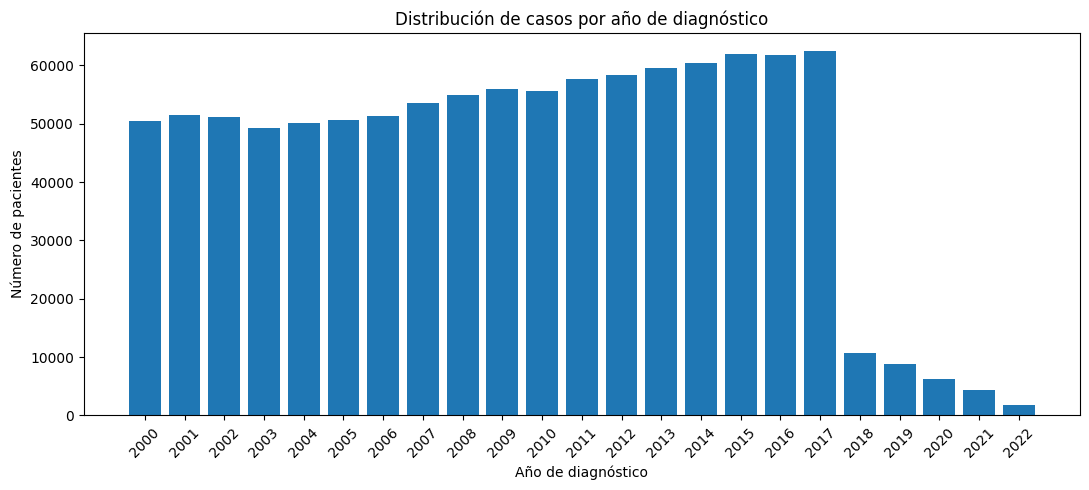

In [ ]:
plt.figure(figsize=(11, 5))

plt.bar(
    year_distribution_model["year_diagnosis"].astype(str),
    year_distribution_model["count"]
)

plt.title("Distribución de casos por año de diagnóstico")
plt.xlabel("Año de diagnóstico")
plt.ylabel("Número de pacientes")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

La distribución por año de diagnóstico muestra que, tras la limpieza inicial y la exclusión de casos censurados, el dataset de modelado conserva una representación amplia del periodo 2000--2017. En estos años, el número de registros por año se mantiene relativamente estable, con valores aproximados entre 49.000 y 62.000 pacientes por año.

A partir de 2018 se observa una caída muy acusada en el número de casos incluidos en el dataset de modelado. Mientras que en 2017 se mantienen 62.449 registros, en 2018 la cifra desciende a 10.671, y continúa reduciéndose progresivamente hasta 1.777 casos en 2022.

Este patrón es coherente con la definición de la variable objetivo. Los pacientes diagnosticados en años recientes tienen menor tiempo potencial de seguimiento, por lo que muchos casos vivos con menos de 60 meses han sido excluidos al no poder determinarse de forma fiable su supervivencia a cinco años.

Por tanto, la variable `year_diagnosis` deberá tratarse con cautela en fases posteriores. Si se incluye directamente como predictor, el modelo podría capturar parcialmente efectos asociados a la disponibilidad de seguimiento y no únicamente cambios clínicos o terapéuticos reales. Esta cuestión será especialmente relevante al definir el conjunto final de variables para el modelado.

## 4.5 Supervivencia a cinco años según año de diagnóstico

Además del número de casos disponibles por año, se analiza la proporción de pacientes que alcanzan la supervivencia a cinco años según el año de diagnóstico.

Este análisis permite detectar posibles patrones temporales y valorar si los años más recientes presentan un comportamiento diferente tras la exclusión de pacientes censurados.

In [ ]:
survival_by_year = (
    df_model
    .groupby("year_diagnosis")["survived_5_years"]
    .mean()
    .mul(100)
    .round(2)
    .rename("survival_5y_rate")
    .reset_index()
)

survival_by_year

,year_diagnosis,survival_5y_rate
0,2000,78.03
1,2001,78.83
2,2002,79.08
3,2003,79.02
4,2004,79.35
5,2005,79.66
6,2006,80.45
7,2007,80.52
8,2008,80.62
9,2009,80.98


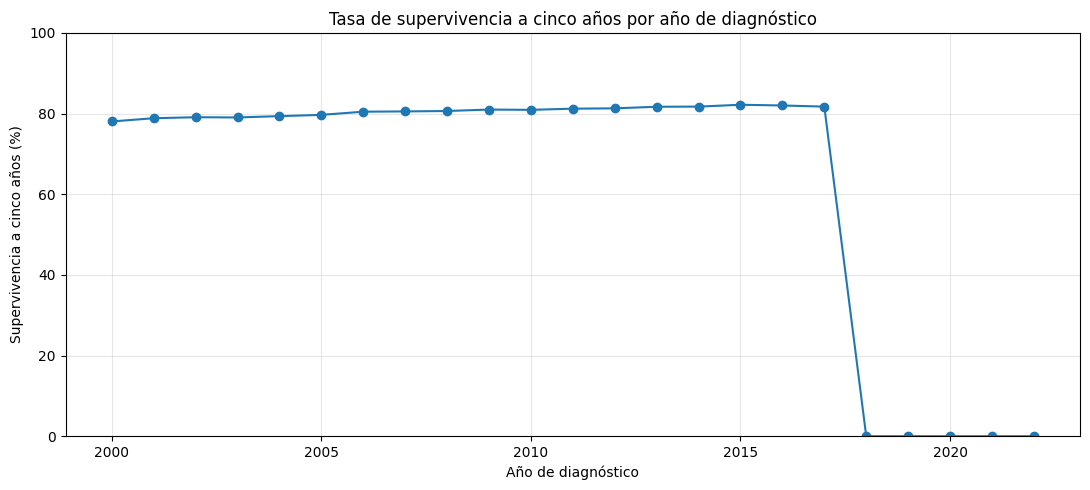

In [ ]:
plt.figure(figsize=(11, 5))

plt.plot(
    survival_by_year["year_diagnosis"],
    survival_by_year["survival_5y_rate"],
    marker="o"
)

plt.title("Tasa de supervivencia a cinco años por año de diagnóstico")
plt.xlabel("Año de diagnóstico")
plt.ylabel("Supervivencia a cinco años (%)")
plt.ylim(0, 100)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

La tasa de supervivencia a cinco años muestra un patrón relativamente estable y ligeramente creciente entre los años 2000 y 2017. En este periodo, la supervivencia pasa aproximadamente del 78,03 % en 2000 al entorno del 81--82 % en los años más recientes con seguimiento suficiente. Este comportamiento puede estar relacionado con mejoras en diagnóstico, tratamiento o composición de los casos registrados, aunque en esta fase debe interpretarse únicamente como una asociación descriptiva.

Sin embargo, a partir de 2018 la tasa de supervivencia a cinco años aparece como 0 %. Este resultado no debe interpretarse como una caída real de la supervivencia, sino como una consecuencia directa de la definición de la variable objetivo y del seguimiento disponible. Los pacientes diagnosticados entre 2018 y 2022 no disponen, en general, de cinco años completos de seguimiento. Por tanto, los pacientes vivos con menos de 60 meses fueron excluidos como casos censurados, y los registros que permanecen en esos años corresponden a pacientes fallecidos antes de alcanzar los cinco años.

Este resultado confirma una limitación metodológica relevante: los años 2018--2022 quedan distorsionados para una tarea de clasificación basada en supervivencia a cinco años. Incluir estos años en el modelado podría introducir un sesgo importante, ya que el modelo aprendería que los diagnósticos recientes se asocian artificialmente con no supervivencia.

Por este motivo, en las siguientes fases será necesario considerar una decisión metodológica adicional. Para el modelo principal, la opción más prudente será restringir el dataset a los años 2000--2017, periodo en el que existe seguimiento potencial suficiente para observar la supervivencia a cinco años de forma más fiable. Los años 2018--2022 podrían reservarse para un análisis descriptivo separado o quedar excluidos del entrenamiento principal.

### Decisión metodológica sobre el periodo de modelado

Dado que los años 2018--2022 no disponen de seguimiento suficiente para evaluar de forma comparable la supervivencia a cinco años, se define un dataset principal de modelado restringido al periodo 2000--2017.

Esta decisión permite reducir el sesgo temporal introducido por la censura administrativa de los años más recientes y construir un conjunto de datos más coherente con el objetivo predictivo del trabajo.

In [ ]:
df_model_main = df_model[df_model["year_diagnosis"] <= 2017].copy()

print(f"Dataset de modelado original: {df_model.shape[0]:,} filas")
print(f"Dataset principal 2000-2017: {df_model_main.shape[0]:,} filas")
print(f"Filas excluidas por periodo 2018-2022: {df_model.shape[0] - df_model_main.shape[0]:,}")

Dataset de modelado original: 1,028,733 filas
Dataset principal 2000-2017: 996,916 filas
Filas excluidas por periodo 2018-2022: 31,817


In [ ]:
target_distribution_main = (
    df_model_main["survived_5_years"]
    .value_counts()
    .sort_index()
    .rename_axis("survived_5_years")
    .reset_index(name="count")
)

target_distribution_main["percentage"] = (
    target_distribution_main["count"] / len(df_model_main) * 100
).round(2)

target_distribution_main

,survived_5_years,count,percentage
0,0,193418,19.4
1,1,803498,80.6


La restricción del dataset al periodo 2000--2017 reduce el conjunto de modelado de 1.028.733 a 996.916 observaciones, excluyendo 31.817 registros correspondientes a diagnósticos entre 2018 y 2022. Esta pérdida representa una proporción limitada del dataset original de modelado, pero permite evitar una distorsión metodológica importante asociada al seguimiento insuficiente de los años más recientes.

Tras esta restricción temporal, la distribución de la variable objetivo queda formada por 803.498 pacientes que alcanzan la supervivencia a cinco años, equivalentes al 80,60 %, y 193.418 pacientes que fallecen antes de los cinco años, equivalentes al 19,40 %.

El dataset principal mantiene, por tanto, un volumen muy elevado de observaciones y una distribución de clases moderadamente desbalanceada. La clase minoritaria sigue siendo la de pacientes que no alcanzan la supervivencia a cinco años, por lo que en la fase de modelado será necesario utilizar métricas que evalúen adecuadamente la capacidad del modelo para identificar estos casos.

## 4.6 Análisis de variables demográficas

A continuación se analizan las principales variables demográficas disponibles en el dataset principal de modelado: grupo de edad, sexo, raza y estado civil en el momento del diagnóstico.

Estas variables pueden estar relacionadas con diferencias pronósticas, características poblacionales, acceso a tratamiento, comorbilidades o patrones de seguimiento. El objetivo de esta sección no es establecer relaciones causales, sino identificar asociaciones descriptivas relevantes antes de la fase de modelado.

### 4.6.1 Grupo de edad

El grupo de edad es una variable clínicamente relevante en el pronóstico del cáncer de mama. Puede estar asociado tanto a características biológicas del tumor como a comorbilidades, tolerancia al tratamiento y mortalidad por otras causas.

Se analiza su distribución y la tasa de supervivencia a cinco años dentro de cada grupo.

In [ ]:
age_summary = categorical_summary(df_model_main, "age_group")
age_summary

,age_group,count,survival_5y_rate,percentage
12,60-64 years,126639,86.07,12.70
11,55-59 years,122200,86.58,12.26
13,65-69 years,121753,84.33,12.21
10,50-54 years,113851,87.77,11.42
14,70-74 years,102382,80.09,10.27
9,45-49 years,97188,89.30,9.75
15,75-79 years,85119,72.69,8.54
8,40-44 years,62817,88.54,6.30
16,80-84 years,62445,60.80,6.26
17,85-89 years,36342,44.87,3.65


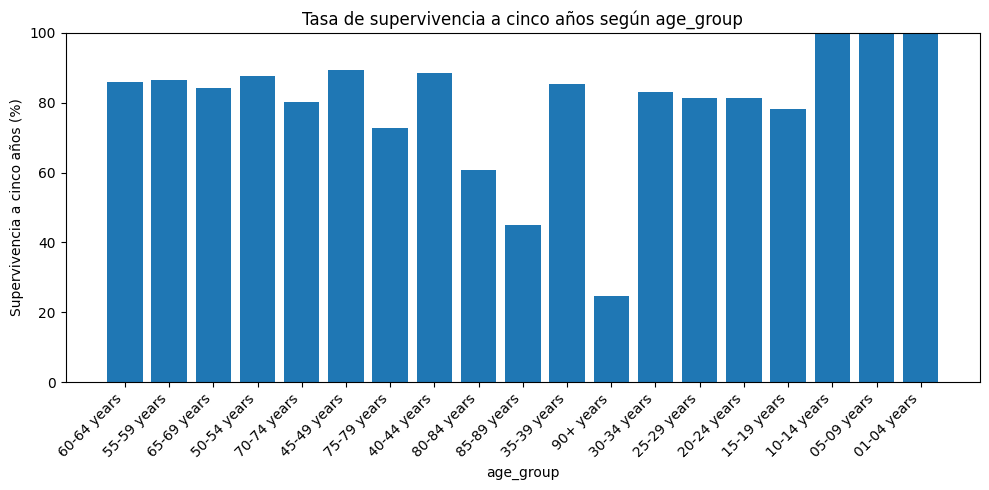

,age_group,count,survival_5y_rate,percentage
12,60-64 years,126639,86.07,12.70
11,55-59 years,122200,86.58,12.26
13,65-69 years,121753,84.33,12.21
10,50-54 years,113851,87.77,11.42
14,70-74 years,102382,80.09,10.27
9,45-49 years,97188,89.30,9.75
15,75-79 years,85119,72.69,8.54
8,40-44 years,62817,88.54,6.30
16,80-84 years,62445,60.80,6.26
17,85-89 years,36342,44.87,3.65


In [ ]:
plot_survival_rate_by_category(
    df_model_main,
    column="age_group",
    top_n=None
)

La distribución por edad muestra que el dataset se concentra principalmente en grupos de edad intermedios y avanzados. Los grupos con mayor número de pacientes son `60-64 years`, `55-59 years`, `65-69 years`, `50-54 years` y `70-74 years`, todos ellos con más de 100.000 registros. Esto es coherente con la epidemiología del cáncer de mama, cuya incidencia aumenta con la edad.

La tasa de supervivencia a cinco años varía de forma clara entre grupos. En edades intermedias, especialmente entre los 45 y 64 años, las tasas de supervivencia se sitúan aproximadamente entre el 86 % y el 89 %. El grupo `45-49 years` presenta una de las tasas más elevadas, con un 89,30 %, seguido de `40-44 years` con un 88,54 % y `50-54 years` con un 87,77 %.

A partir de los 70 años se observa un descenso progresivo de la supervivencia a cinco años. El grupo `70-74 years` presenta una tasa del 80,09 %, que disminuye hasta el 72,69 % en `75-79 years`, el 60,80 % en `80-84 years`, el 44,87 % en `85-89 years` y el 24,67 % en `90+ years`.

Los grupos de edad pediátricos o muy jóvenes presentan tasas aparentemente elevadas, incluso del 100 % en algunos casos, pero su frecuencia es extremadamente baja. Por tanto, estos valores deben interpretarse con cautela, ya que se basan en un número muy reducido de observaciones.

En conjunto, la edad aparece como una variable potencialmente muy relevante para el modelado, tanto por su distribución en el dataset como por la clara variación de la supervivencia a cinco años entre grupos.

### 4.6.2 Sexo

La variable `sex` permite analizar la distribución de pacientes según sexo en el dataset principal de modelado. Aunque el cáncer de mama afecta mayoritariamente a mujeres, el registro también incluye casos masculinos.

Se analiza tanto la frecuencia de cada grupo como su tasa de supervivencia a cinco años.

In [ ]:
sex_summary = categorical_summary(df_model_main, "sex")
sex_summary

,sex,count,survival_5y_rate,percentage
0,Female,989573,80.70,99.26
1,Male,7343,67.19,0.74


La variable `sex` presenta un fuerte desbalance. El 99,26 % de los registros corresponden a pacientes mujeres, con 989.573 observaciones, mientras que los pacientes masculinos representan únicamente el 0,74 %, con 7.343 casos.

Este patrón es coherente con la epidemiología del cáncer de mama, ya que se trata de una enfermedad que afecta mayoritariamente a mujeres. No obstante, la presencia de casos masculinos confirma que el dataset incluye también esta población, aunque de forma muy minoritaria.

La tasa de supervivencia a cinco años es del 80,70 % en mujeres y del 67,19 % en hombres. Esta diferencia descriptiva podría reflejar diferencias clínicas, diagnósticas o de detección entre ambos grupos, aunque debe interpretarse con cautela debido al tamaño mucho menor del grupo masculino.

En este trabajo se mantienen los casos masculinos en el dataset principal, ya que representan una población clínicamente válida. Sin embargo, cualquier interpretación sobre la variable `sex` deberá considerar el fuerte desbalance existente.

### 4.6.3 Raza o grupo étnico

La variable `race` recoge la raza o grupo étnico recodificado del paciente. Su análisis permite identificar la composición poblacional del dataset y explorar posibles diferencias descriptivas en la supervivencia a cinco años.

Estas diferencias no deben interpretarse de forma causal, ya que pueden estar influidas por múltiples factores no observados, como acceso al sistema sanitario, estadio al diagnóstico, comorbilidades, características socioeconómicas o diferencias en el tratamiento recibido.

In [ ]:
race_summary = categorical_summary(df_model_main, "race")
race_summary

,race,count,survival_5y_rate,percentage
4,White,808438,80.97,81.09
2,Black,100866,72.55,10.12
1,Asian or Pacific Islander,78151,86.70,7.84
0,American Indian/Alaska Native,5914,79.78,0.59
3,Unknown,3547,91.80,0.36


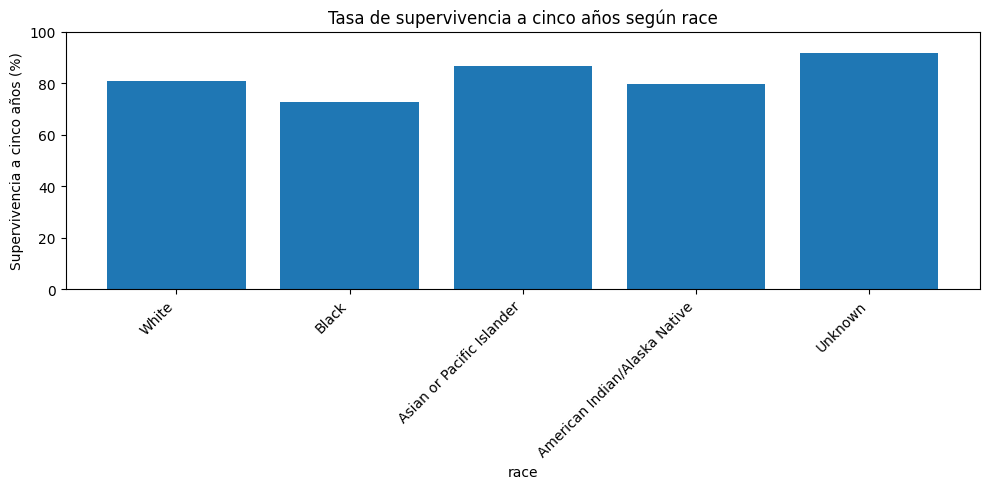

,race,count,survival_5y_rate,percentage
4,White,808438,80.97,81.09
2,Black,100866,72.55,10.12
1,Asian or Pacific Islander,78151,86.70,7.84
0,American Indian/Alaska Native,5914,79.78,0.59
3,Unknown,3547,91.80,0.36


In [ ]:
plot_survival_rate_by_category(
    df_model_main,
    column="race",
    top_n=None
)

La distribución de la variable `race` muestra que la mayor parte del dataset corresponde a pacientes clasificadas como `White`, con 808.438 observaciones, lo que representa el 81,09 % del conjunto principal de modelado. El segundo grupo más frecuente es `Black`, con 100.866 registros, equivalente al 10,12 %, seguido de `Asian or Pacific Islander`, con 78.151 casos, que representan el 7,84 %.

En términos de supervivencia a cinco años, se observan diferencias descriptivas entre grupos. El grupo `Asian or Pacific Islander` presenta la tasa más alta, con un 86,70 %, seguido de `White`, con un 80,97 %, y `American Indian/Alaska Native`, con un 79,78 %. El grupo `Black` presenta una tasa inferior, del 72,55 %.

La categoría `Unknown` muestra una supervivencia del 91,80 %, pero representa únicamente el 0,36 % del dataset. Por tanto, este valor debe interpretarse con cautela, ya que puede estar influido por el reducido tamaño del grupo o por características específicas de los registros sin raza informada.

Estas diferencias deben entenderse como asociaciones descriptivas dentro del conjunto de datos, no como relaciones causales directas. La supervivencia puede estar influida por múltiples factores adicionales, como edad, estadio al diagnóstico, acceso a tratamiento, comorbilidades, características socioeconómicas o diferencias en la calidad del registro.

### 4.6.4 Estado civil en el diagnóstico

La variable `marital_status` recoge el estado civil del paciente en el momento del diagnóstico. Aunque no es una variable clínica directa, puede actuar como indicador indirecto de factores sociales, apoyo familiar, edad, acceso a cuidados o patrones de seguimiento.

Se analiza su distribución y su relación descriptiva con la supervivencia a cinco años.

In [ ]:
marital_summary = categorical_summary(df_model_main, "marital_status")
marital_summary

,marital_status,count,survival_5y_rate,percentage
1,Married (including common law),537717,86.44,53.94
6,Widowed,159948,64.54,16.04
3,Single (never married),135613,78.67,13.60
0,Divorced,104397,80.42,10.47
4,Unknown,47423,74.53,4.76
2,Separated,10179,79.07,1.02
5,Unmarried or Domestic Partner,1639,87.80,0.16


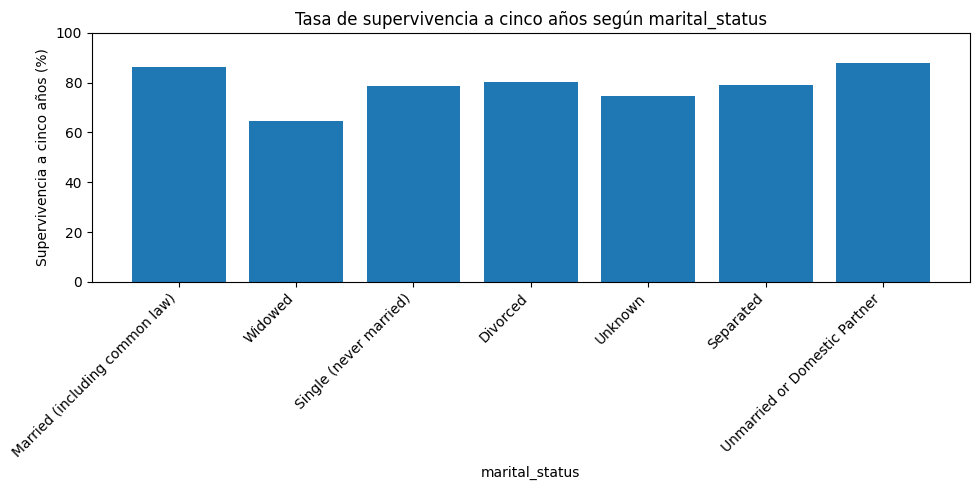

,marital_status,count,survival_5y_rate,percentage
1,Married (including common law),537717,86.44,53.94
6,Widowed,159948,64.54,16.04
3,Single (never married),135613,78.67,13.60
0,Divorced,104397,80.42,10.47
4,Unknown,47423,74.53,4.76
2,Separated,10179,79.07,1.02
5,Unmarried or Domestic Partner,1639,87.80,0.16


In [ ]:
plot_survival_rate_by_category(
    df_model_main,
    column="marital_status",
    top_n=None
)

La distribución de `marital_status` muestra que la categoría más frecuente es `Married (including common law)`, con 537.717 registros, lo que representa el 53,94 % del dataset principal. Le siguen `Widowed`, con 159.948 registros y un 16,04 %, `Single (never married)`, con 135.613 registros y un 13,60 %, y `Divorced`, con 104.397 registros y un 10,47 %.

En términos de supervivencia a cinco años, los pacientes casados presentan una tasa elevada, del 86,44 %. La categoría `Unmarried or Domestic Partner` muestra una tasa del 87,80 %, aunque representa únicamente el 0,16 % del dataset, por lo que debe interpretarse con cautela debido a su bajo tamaño muestral.

La categoría `Widowed` presenta la tasa de supervivencia más baja, con un 64,54 %. Este resultado probablemente está influido por la edad, ya que los pacientes viudos tienden a concentrarse en grupos de mayor edad. Por tanto, esta diferencia no debe interpretarse de forma aislada como un efecto directo del estado civil.

Las categorías `Single`, `Divorced` y `Separated` presentan tasas intermedias, situadas aproximadamente entre el 78 % y el 80 %. La categoría `Unknown`, que representa el 4,76 % del dataset, muestra una supervivencia del 74,53 %, lo que sugiere que los valores no informados también podrían estar asociados a perfiles clínicos o administrativos específicos.

En conjunto, `marital_status` puede aportar información predictiva, pero su interpretación debe realizarse con prudencia, ya que puede actuar como variable indirecta de edad, apoyo social, comorbilidad, acceso a cuidados u otros factores no observados.

### Síntesis del análisis demográfico

El análisis demográfico muestra que variables como la edad, el sexo, la raza y el estado civil presentan diferencias descriptivas relevantes en la supervivencia a cinco años.

La edad muestra uno de los patrones más claros, con una disminución progresiva de la supervivencia en los grupos de mayor edad, especialmente a partir de los 70 años. La variable `sex` está fuertemente desbalanceada, aunque los pacientes masculinos presentan una tasa de supervivencia inferior a la de las mujeres. También se observan diferencias entre grupos raciales y categorías de estado civil, aunque estas asociaciones deben interpretarse con cautela por la posible influencia de factores clínicos, sociales y de acceso al sistema sanitario.

Estas variables se conservarán inicialmente como predictores candidatos para el modelado, tratándolas como variables categóricas y evaluando posteriormente su contribución dentro de los modelos.

## 4.7 Análisis de variables tumorales y de estadificación

Después del análisis demográfico, se estudian las variables relacionadas con las características del tumor y la extensión de la enfermedad. Estas variables son especialmente relevantes en un problema pronóstico, ya que describen aspectos clínicos directamente relacionados con la evolución del cáncer.

En este bloque se analizan:

- `summary_stage`
- `tumor_size`
- `primary_site`
- `histologic_type`

El objetivo es observar su distribución, identificar valores especiales y analizar su relación descriptiva con la supervivencia a cinco años.

### 4.7.1 Estadio resumen del cáncer

La variable `summary_stage` resume la extensión de la enfermedad en el momento del diagnóstico. Sus categorías principales permiten distinguir entre enfermedad localizada, regional, distante, desconocida o no informada.

Desde el punto de vista clínico, esta variable es especialmente relevante porque la extensión del tumor constituye uno de los principales factores pronósticos en cáncer de mama.

In [ ]:
summary_stage_summary = categorical_summary(df_model_main, "summary_stage")
summary_stage_summary

,summary_stage,count,survival_5y_rate,percentage
1,Localized,625596,87.92,62.75
2,Regional,297022,77.31,29.79
0,Distant,53980,25.14,5.41
3,Unknown/unstaged,20318,50.75,2.04


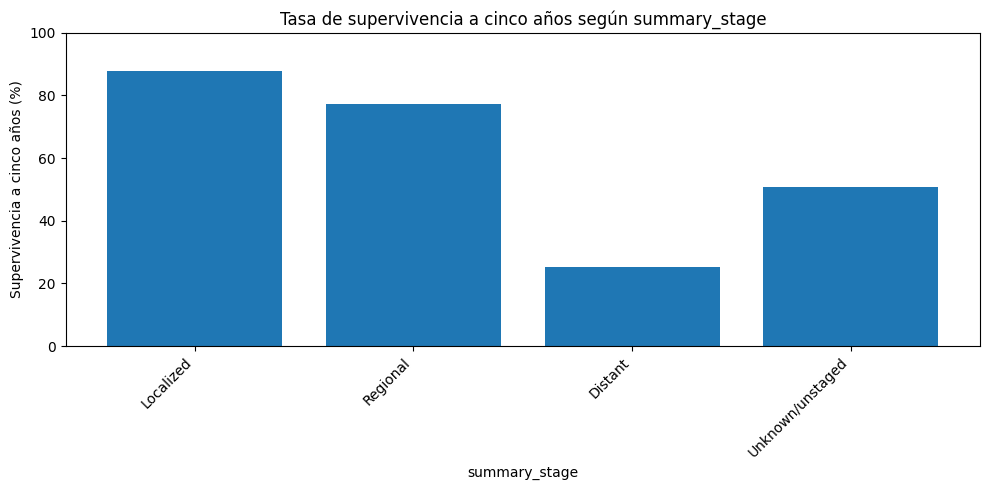

,summary_stage,count,survival_5y_rate,percentage
1,Localized,625596,87.92,62.75
2,Regional,297022,77.31,29.79
0,Distant,53980,25.14,5.41
3,Unknown/unstaged,20318,50.75,2.04


In [ ]:
plot_survival_rate_by_category(
    df_model_main,
    column="summary_stage",
    top_n=None
)

La variable `summary_stage` muestra una asociación muy clara con la supervivencia a cinco años. La mayoría de los casos corresponden a enfermedad localizada, con 625.596 registros, lo que representa el 62,75 % del dataset principal. Este grupo presenta una tasa de supervivencia a cinco años del 87,92 %.

El segundo grupo más frecuente es `Regional`, con 297.022 registros, equivalente al 29,79 % del dataset, y una supervivencia del 77,31 %. Este descenso respecto a la enfermedad localizada es coherente con una mayor extensión tumoral en el momento del diagnóstico.

La categoría `Distant` representa el 5,41 % de los casos, con 53.980 registros, y presenta una tasa de supervivencia mucho menor, del 25,14 %. Este resultado confirma el fuerte impacto pronóstico de la diseminación a distancia en el cáncer de mama.

Finalmente, la categoría `Unknown/unstaged` supone el 2,04 % del dataset y muestra una supervivencia del 50,75 %. Esta categoría debe interpretarse con cautela, ya que no representa un estadio clínico concreto, sino ausencia o imposibilidad de estadificación. No obstante, su tasa intermedia sugiere que los casos no estadificados podrían agrupar perfiles clínicos heterogéneos.

En conjunto, `summary_stage` aparece como una de las variables más relevantes desde el punto de vista pronóstico y deberá conservarse como predictor candidato en la fase de modelado.

### 4.7.2 Tamaño tumoral

La variable `tumor_size` recoge el tamaño tumoral resumido. En el dataset aparece como una variable categórica codificada, con valores numéricos representados como texto y valores especiales como `Blank(s)` o `999`.

Antes de interpretar esta variable, es necesario revisar su distribución y la presencia de códigos no informativos, ya que una proporción elevada de valores desconocidos puede condicionar su utilidad en el modelado.

In [ ]:
tumor_size_summary = categorical_summary(df_model_main, "tumor_size")
tumor_size_summary.head(20)

,tumor_size,count,survival_5y_rate,percentage
225,Blank(s),872634,80.42,87.53
15,015,6446,89.22,0.65
224,999,6395,51.67,0.64
12,012,5647,90.24,0.57
10,010,4593,90.31,0.46
8,008,4467,91.25,0.45
25,025,4133,81.39,0.41
11,011,4109,90.14,0.41
18,018,3991,87.77,0.40
9,009,3982,91.41,0.40


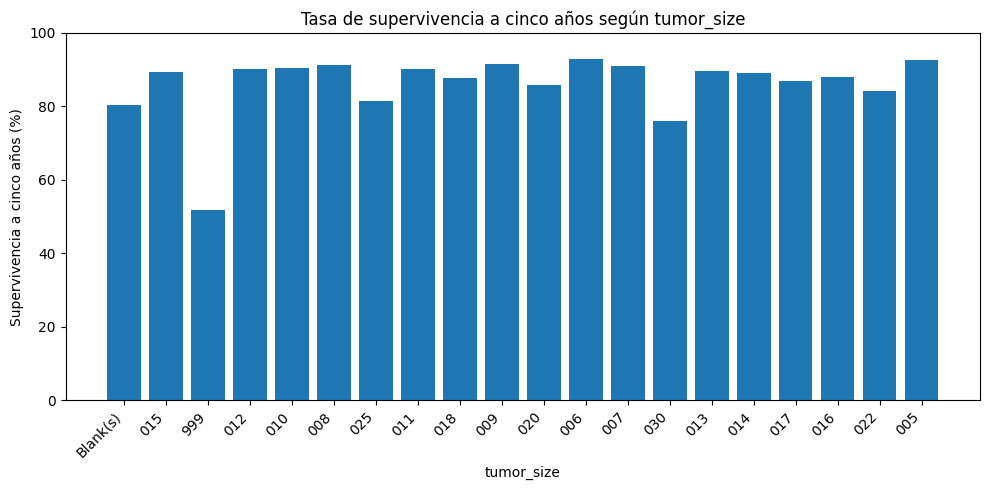

,tumor_size,count,survival_5y_rate,percentage
225,Blank(s),872634,80.42,87.53
15,015,6446,89.22,0.65
224,999,6395,51.67,0.64
12,012,5647,90.24,0.57
10,010,4593,90.31,0.46
8,008,4467,91.25,0.45
25,025,4133,81.39,0.41
11,011,4109,90.14,0.41
18,018,3991,87.77,0.40
9,009,3982,91.41,0.40


In [ ]:
plot_survival_rate_by_category(
    df_model_main,
    column="tumor_size",
    top_n=20
)

La variable `tumor_size` presenta una limitación importante: la categoría `Blank(s)` concentra 872.634 registros, lo que representa el 87,53 % del dataset principal. Esto indica que el tamaño tumoral no está informado para la gran mayoría de observaciones, por lo que su uso directo como predictor podría aportar poca información clínica real y capturar principalmente patrones de disponibilidad del dato.

Entre los valores informados, aparecen tamaños codificados como texto, por ejemplo `015`, `012`, `010`, `008` o `025`. Estos valores parecen representar medidas tumorales codificadas, pero su frecuencia individual es muy baja en comparación con la categoría `Blank(s)`. Por ejemplo, el valor `015` representa solo el 0,65 % del dataset.

El código `999` aparece en 6.395 registros, equivalente al 0,64 %, y presenta una supervivencia a cinco años del 51,67 %. Este valor no debe interpretarse como un tamaño tumoral real, sino como un código especial asociado a tamaño desconocido o no especificado.

En los tamaños tumorales aparentemente informados se observa una tendencia clínica plausible: valores pequeños como `005`, `006`, `008`, `009`, `010` o `012` presentan tasas de supervivencia superiores al 90 %, mientras que valores mayores, como `030`, muestran tasas inferiores, en este caso del 75,99 %. No obstante, debido a la elevada proporción de valores `Blank(s)`, esta interpretación debe hacerse con cautela.

De cara al modelado, será necesario decidir si `tumor_size` se excluye por baja disponibilidad, si se mantiene como variable categórica con una categoría explícita para valores desconocidos, o si se construye una versión recodificada que diferencie entre tamaño informado, desconocido y rangos tumorales clínicamente interpretables.

### 4.7.3 Localización primaria del tumor

La variable `primary_site` recoge la localización primaria del tumor dentro de la mama mediante códigos topográficos. Aunque aparece cargada como variable entera, debe interpretarse como una variable categórica, ya que sus valores representan códigos anatómicos y no magnitudes numéricas.

Se analiza su distribución y su relación descriptiva con la supervivencia a cinco años.

In [ ]:
primary_site_summary = categorical_summary(df_model_main, "primary_site")
primary_site_summary

,primary_site,count,survival_5y_rate,percentage
4,504,326139,83.80,32.71
7,508,213142,81.82,21.38
8,509,159736,67.93,16.02
2,502,109725,85.59,11.01
5,505,68917,84.09,6.91
1,501,53487,77.10,5.37
3,503,53393,83.86,5.36
0,500,6226,74.14,0.62
6,506,6151,78.10,0.62


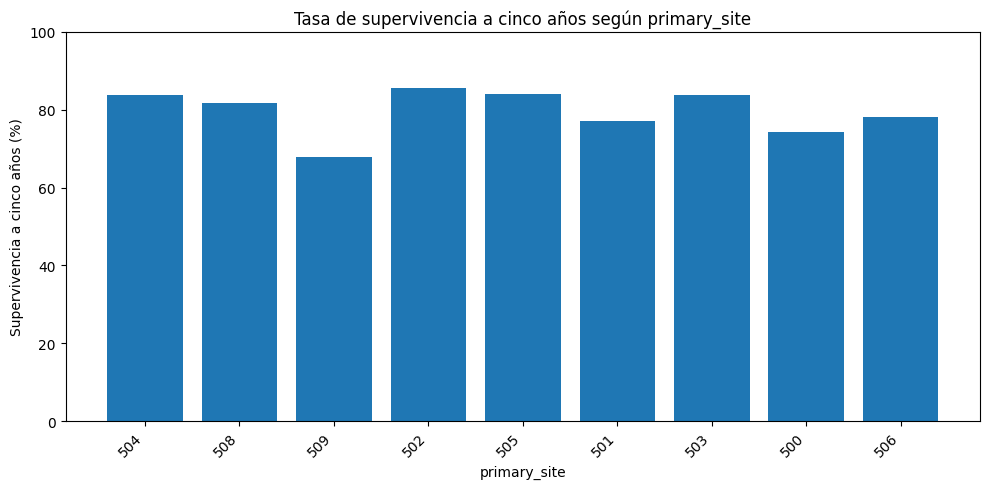

,primary_site,count,survival_5y_rate,percentage
4,504,326139,83.80,32.71
7,508,213142,81.82,21.38
8,509,159736,67.93,16.02
2,502,109725,85.59,11.01
5,505,68917,84.09,6.91
1,501,53487,77.10,5.37
3,503,53393,83.86,5.36
0,500,6226,74.14,0.62
6,506,6151,78.10,0.62


In [ ]:
plot_survival_rate_by_category(
    df_model_main,
    column="primary_site",
    top_n=None
)

La variable `primary_site` presenta una distribución concentrada en varios códigos principales. El código más frecuente es `504`, con 326.139 registros, equivalente al 32,71 % del dataset principal. Le siguen `508`, con 213.142 registros y un 21,38 %, y `509`, con 159.736 registros y un 16,02 %.

En términos de supervivencia a cinco años, se observan diferencias descriptivas entre códigos anatómicos. Los códigos `502`, `505`, `503`, `504` y `508` presentan tasas relativamente elevadas, situadas aproximadamente entre el 81 % y el 86 %. En cambio, el código `509` muestra una tasa inferior, del 67,93 %, pese a representar un porcentaje relevante del dataset.

Los códigos menos frecuentes, como `500` y `506`, representan cada uno alrededor del 0,62 % del conjunto y presentan tasas de supervivencia del 74,14 % y 78,10 %, respectivamente. Debido a su menor frecuencia, su interpretación debe realizarse con mayor cautela.

Es importante recordar que `primary_site` es una variable categórica codificada. Sus valores representan localizaciones anatómicas del tumor primario y no deben interpretarse como una variable numérica continua u ordinal. Por tanto, en la fase de preprocesamiento deberá codificarse adecuadamente antes de entrenar los modelos.

### 4.7.4 Tipo histológico

La variable `histologic_type` recoge el tipo histológico del tumor según la clasificación ICD-O-3. Aunque aparece cargada como variable entera, debe interpretarse como una variable categórica codificada.

Esta variable presenta una cardinalidad elevada, por lo que se analizan las categorías más frecuentes y su relación descriptiva con la supervivencia a cinco años.

In [ ]:
histologic_type_summary = categorical_summary(df_model_main, "histologic_type")
histologic_type_summary.head(20)

,histologic_type,count,survival_5y_rate,percentage
81,8500,706854,81.89,70.90
92,8520,87538,80.69,8.78
94,8522,65753,84.86,6.60
95,8523,29385,85.51,2.95
78,8480,21298,83.46,2.14
5,8010,13579,45.75,1.36
43,8211,8839,92.62,0.89
35,8140,8759,45.15,0.88
0,8000,7815,30.85,0.78
98,8530,5364,34.45,0.54


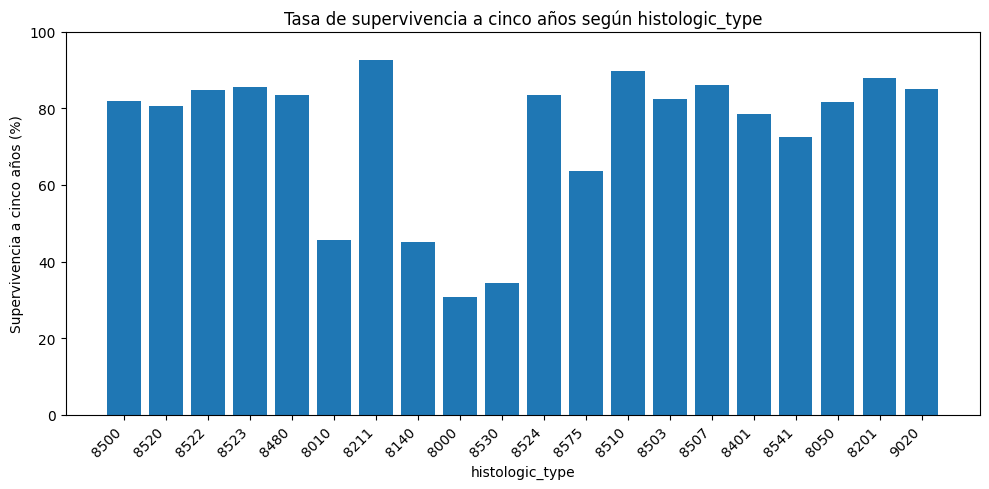

,histologic_type,count,survival_5y_rate,percentage
81,8500,706854,81.89,70.90
92,8520,87538,80.69,8.78
94,8522,65753,84.86,6.60
95,8523,29385,85.51,2.95
78,8480,21298,83.46,2.14
5,8010,13579,45.75,1.36
43,8211,8839,92.62,0.89
35,8140,8759,45.15,0.88
0,8000,7815,30.85,0.78
98,8530,5364,34.45,0.54


In [ ]:
plot_survival_rate_by_category(
    df_model_main,
    column="histologic_type",
    top_n=20
)

La variable `histologic_type` presenta una alta cardinalidad, aunque la distribución está muy concentrada en unos pocos códigos. El código `8500` es claramente mayoritario, con 706.854 registros, lo que representa el 70,90 % del dataset principal. Le siguen `8520`, con 87.538 registros y un 8,78 %, `8522`, con 65.753 registros y un 6,60 %, y `8523`, con 29.385 registros y un 2,95 %.

En términos de supervivencia a cinco años, los códigos histológicos más frecuentes presentan tasas relativamente elevadas. El código `8500` muestra una supervivencia del 81,89 %, `8520` del 80,69 %, `8522` del 84,86 % y `8523` del 85,51 %. Esto sugiere que los tipos histológicos predominantes en el dataset se asocian, en general, con tasas de supervivencia superiores al promedio de la clase negativa.

Sin embargo, algunos códigos menos frecuentes presentan tasas de supervivencia considerablemente más bajas. Por ejemplo, `8010` muestra una tasa del 45,75 %, `8140` del 45,15 %, `8000` del 30,85 % y `8530` del 34,45 %. Aunque estos grupos representan proporciones menores del dataset, podrían aportar información pronóstica relevante.

También existen códigos con supervivencias muy elevadas, como `8211`, con un 92,62 %, o `8510`, con un 89,75 %. No obstante, al tratarse de categorías menos frecuentes, estas tasas deben interpretarse con cautela.

De cara al modelado, `histologic_type` deberá tratarse como una variable categórica codificada, no como una variable numérica continua. Debido a su alta cardinalidad y a la presencia de categorías poco frecuentes, será necesario valorar estrategias de preprocesamiento como la agrupación de categorías minoritarias o una codificación adecuada que evite introducir relaciones ordinales artificiales.

### Síntesis del análisis tumoral y de estadificación

El análisis de variables tumorales y de estadificación muestra que `summary_stage` es una de las variables con mayor relación descriptiva con la supervivencia a cinco años. Los pacientes con enfermedad localizada presentan una supervivencia muy superior a los pacientes con enfermedad distante, lo que confirma la relevancia pronóstica de la extensión tumoral.

La variable `tumor_size` presenta una limitación importante debido a la elevada proporción de valores `Blank(s)`, que alcanza el 87,53 % del dataset principal. Aunque los valores informados muestran patrones clínicamente plausibles, su baja disponibilidad obliga a tratar esta variable con especial cautela en fases posteriores.

Las variables `primary_site` e `histologic_type` aportan información clínica adicional, pero deben tratarse como variables categóricas codificadas. En particular, `histologic_type` presenta alta cardinalidad y una distribución muy concentrada en el código `8500`, junto con múltiples categorías minoritarias que podrían requerir tratamiento específico antes del modelado.

En conjunto, estas variables se conservarán inicialmente como candidatas para el modelado, aunque será necesario aplicar decisiones de preprocesamiento adecuadas para evitar interpretaciones numéricas incorrectas y manejar valores especiales o categorías poco frecuentes.

## 4.8 Análisis de variables de tratamiento

A continuación se analizan las variables relacionadas con el tratamiento registrado en el dataset: cirugía sobre el sitio primario, radioterapia y quimioterapia.

Estas variables pueden estar asociadas a la supervivencia a cinco años, aunque su interpretación debe realizarse con especial cautela. En un registro observacional, el tratamiento recibido no es aleatorio, sino que depende de factores clínicos como el estadio, el tipo tumoral, la edad, el estado general del paciente y las decisiones terapéuticas adoptadas.

Por tanto, las diferencias observadas en supervivencia según tratamiento no deben interpretarse directamente como efectos causales del tratamiento, sino como asociaciones descriptivas dentro del conjunto de datos.

### 4.8.1 Cirugía sobre el sitio primario

La variable `surgery_primary_site` recoge mediante códigos el tipo de cirugía realizada sobre el sitio primario del tumor.

Aunque aparece cargada como variable entera, debe interpretarse como una variable categórica codificada. Sus valores representan procedimientos quirúrgicos o situaciones relacionadas con la cirugía, no cantidades numéricas ni niveles ordinales directos.

Se analizan las categorías más frecuentes y su relación descriptiva con la supervivencia a cinco años.

In [ ]:
surgery_summary = categorical_summary(df_model_main, "surgery_primary_site")
surgery_summary.head(20)

,surgery_primary_site,count,survival_5y_rate,percentage
4,22,302180,87.33,30.31
19,51,136566,73.62,13.70
5,23,102335,91.71,10.27
9,41,92509,80.43,9.28
0,0,85149,34.02,8.54
2,20,47298,87.65,4.74
6,24,44105,88.56,4.42
10,42,21943,89.65,2.20
8,40,17698,79.87,1.78
20,52,17586,81.97,1.76


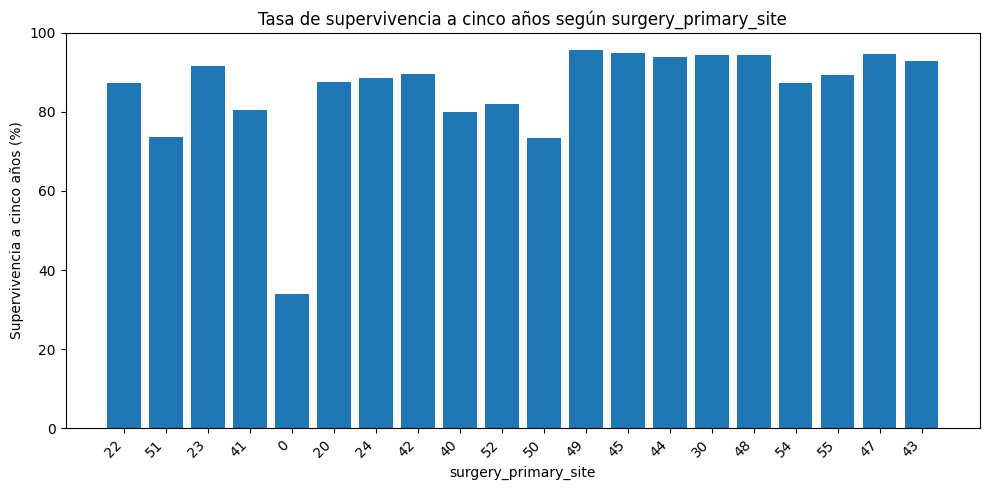

,surgery_primary_site,count,survival_5y_rate,percentage
4,22,302180,87.33,30.31
19,51,136566,73.62,13.70
5,23,102335,91.71,10.27
9,41,92509,80.43,9.28
0,0,85149,34.02,8.54
2,20,47298,87.65,4.74
6,24,44105,88.56,4.42
10,42,21943,89.65,2.20
8,40,17698,79.87,1.78
20,52,17586,81.97,1.76


In [ ]:
plot_survival_rate_by_category(
    df_model_main,
    column="surgery_primary_site",
    top_n=20
)

La variable `surgery_primary_site` presenta una distribución amplia de códigos quirúrgicos, aunque algunos concentran una parte importante del dataset. El código más frecuente es `22`, con 302.180 registros, equivalente al 30,31 % del dataset principal, y una tasa de supervivencia a cinco años del 87,33 %. Le siguen el código `51`, con 136.566 registros y una supervivencia del 73,62 %, y el código `23`, con 102.335 registros y una supervivencia del 91,71 %.

Destaca especialmente el código `0`, que representa 85.149 registros, equivalentes al 8,54 % del dataset, y presenta una tasa de supervivencia mucho más baja, del 34,02 %. Aunque será necesario consultar la codificación exacta de SEER para interpretar clínicamente cada código, esta diferencia sugiere que determinadas categorías quirúrgicas pueden estar asociadas a perfiles de pacientes con peor pronóstico, ausencia de cirugía o situaciones clínicas más avanzadas.

Otros códigos, como `49`, `45`, `44`, `30`, `48` o `47`, presentan tasas de supervivencia superiores al 93 %, aunque su frecuencia es considerablemente menor. Estas diferencias deben interpretarse con cautela, ya que el tipo de cirugía no se asigna aleatoriamente, sino que depende de factores como estadio, tamaño tumoral, edad, estado general y criterio clínico.

De cara al modelado, `surgery_primary_site` deberá tratarse como una variable categórica codificada. No debe interpretarse como una variable numérica continua u ordinal. Además, debido al número de categorías y a la presencia de códigos poco frecuentes, será necesario valorar estrategias de agrupación o codificación adecuadas durante el preprocesamiento.

### 4.8.2 Radioterapia

La variable `radiation` recoge información sobre el tratamiento con radioterapia. Sus categorías distinguen entre diferentes modalidades, ausencia de radioterapia, rechazo del tratamiento o recomendación sin confirmación de administración.

Al tratarse de una variable de tratamiento observacional, su relación con la supervivencia debe interpretarse con cautela, ya que puede estar condicionada por el estadio, el tipo de cirugía, la edad, las características del tumor y otros factores clínicos.

In [ ]:
radiation_summary = categorical_summary(df_model_main, "radiation")
radiation_summary

,radiation,count,survival_5y_rate,percentage
2,None/Unknown,481732,73.99,48.32
0,Beam radiation,447967,87.53,44.94
6,"Recommended, unknown if administered",24235,82.36,2.43
7,Refused (1988+),18595,68.89,1.87
4,Radioactive implants (includes brachytherapy) ...,16574,93.51,1.66
3,"Radiation, NOS method or source not specified",5520,83.10,0.55
1,Combination of beam with implants or isotopes,1906,90.98,0.19
5,Radioisotopes (1988+),387,88.89,0.04


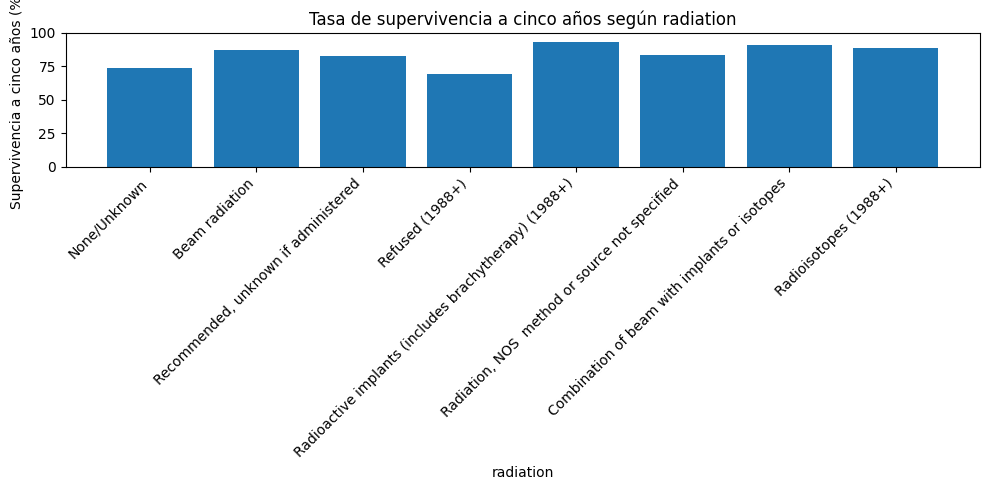

,radiation,count,survival_5y_rate,percentage
2,None/Unknown,481732,73.99,48.32
0,Beam radiation,447967,87.53,44.94
6,"Recommended, unknown if administered",24235,82.36,2.43
7,Refused (1988+),18595,68.89,1.87
4,Radioactive implants (includes brachytherapy) ...,16574,93.51,1.66
3,"Radiation, NOS method or source not specified",5520,83.10,0.55
1,Combination of beam with implants or isotopes,1906,90.98,0.19
5,Radioisotopes (1988+),387,88.89,0.04


In [ ]:
plot_survival_rate_by_category(
    df_model_main,
    column="radiation",
    top_n=None
)

La variable `radiation` muestra una distribución principalmente concentrada en dos categorías. La categoría más frecuente es `None/Unknown`, con 481.732 registros, equivalente al 48,32 % del dataset principal, seguida de `Beam radiation`, con 447.967 registros y un 44,94 %.

En términos de supervivencia a cinco años, los pacientes registrados con `Beam radiation` presentan una tasa del 87,53 %, claramente superior a la observada en la categoría `None/Unknown`, que es del 73,99 %. No obstante, esta diferencia no debe interpretarse como un efecto causal directo de la radioterapia, ya que la indicación del tratamiento depende de múltiples factores clínicos, como estadio, cirugía, edad, características tumorales y estado general del paciente.

La categoría `Refused (1988+)` representa el 1,87 % del dataset y presenta una supervivencia del 68,89 %, inferior a la mayoría de categorías. Este grupo puede reflejar perfiles clínicos o sociales particulares, por lo que su interpretación requiere cautela.

Las modalidades menos frecuentes, como `Radioactive implants`, `Combination of beam with implants or isotopes` o `Radioisotopes`, presentan tasas de supervivencia elevadas, superiores al 88 %, aunque representan proporciones pequeñas del dataset. Por tanto, sus tasas pueden estar condicionadas por el tipo de pacientes seleccionados para estos tratamientos.

En conjunto, `radiation` se conservará como variable candidata para el modelado, tratándola como categórica. Sin embargo, su interpretación posterior deberá considerar que las variables de tratamiento en datos observacionales pueden estar fuertemente condicionadas por el perfil clínico inicial del paciente.

### 4.8.3 Quimioterapia

La variable `chemotherapy` recoge si el paciente recibió quimioterapia según la codificación disponible en SEER. Esta variable distingue principalmente entre tratamiento registrado como `Yes` y la categoría `No/Unknown`.

Al igual que ocurre con el resto de variables de tratamiento, su interpretación debe realizarse con cautela, ya que la administración de quimioterapia depende de múltiples factores clínicos y no corresponde a una asignación aleatoria.

In [ ]:
chemotherapy_summary = categorical_summary(df_model_main, "chemotherapy")
chemotherapy_summary

,chemotherapy,count,survival_5y_rate,percentage
0,No/Unknown,607861,79.56,60.97
1,Yes,389055,82.22,39.03


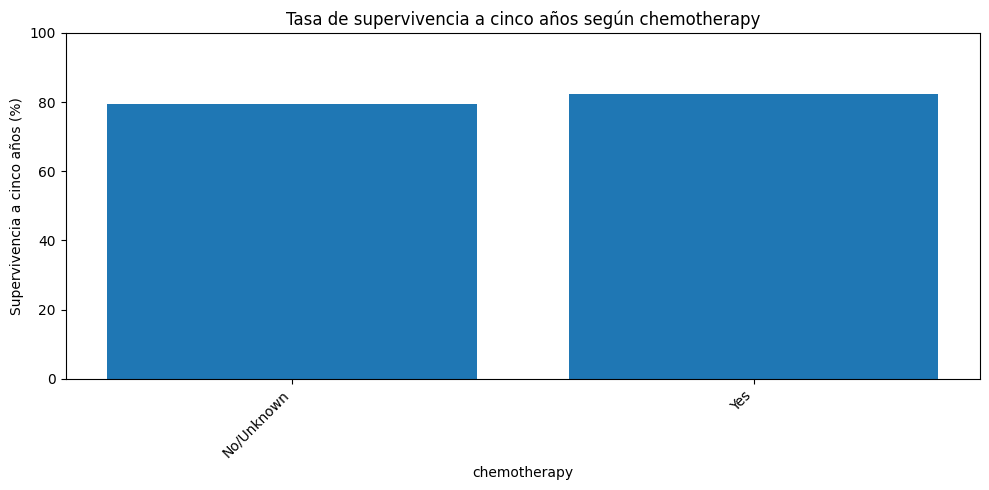

,chemotherapy,count,survival_5y_rate,percentage
0,No/Unknown,607861,79.56,60.97
1,Yes,389055,82.22,39.03


In [ ]:
plot_survival_rate_by_category(
    df_model_main,
    column="chemotherapy",
    top_n=None
)

La variable `chemotherapy` se distribuye en dos categorías principales. La categoría `No/Unknown` concentra 607.861 registros, lo que representa el 60,97 % del dataset principal, mientras que `Yes` incluye 389.055 registros, equivalentes al 39,03 %.

La tasa de supervivencia a cinco años es del 79,56 % para la categoría `No/Unknown` y del 82,22 % para los pacientes registrados con quimioterapia. La diferencia observada es moderada y debe interpretarse con cautela, ya que la variable `No/Unknown` combina tanto ausencia de quimioterapia como información desconocida.

Además, la administración de quimioterapia no es aleatoria, sino que depende de múltiples factores clínicos, como estadio, tipo histológico, edad, características tumorales y estrategia terapéutica. Por tanto, la asociación descriptiva observada no debe interpretarse como un efecto causal directo del tratamiento.

En la fase de modelado, `chemotherapy` se conservará inicialmente como variable categórica candidata. Su importancia predictiva deberá analizarse posteriormente junto con el resto de variables clínicas y teniendo en cuenta la ambigüedad de la categoría `No/Unknown`.

### Síntesis del análisis de variables de tratamiento

El análisis de las variables de tratamiento muestra diferencias descriptivas relevantes en la supervivencia a cinco años según cirugía, radioterapia y quimioterapia. Sin embargo, estas variables deben interpretarse con especial prudencia, ya que proceden de un registro observacional y el tratamiento recibido depende del perfil clínico del paciente.

La variable `surgery_primary_site` presenta una amplia variedad de códigos, con diferencias importantes en supervivencia entre categorías. Destaca especialmente el código `0`, asociado a una supervivencia considerablemente menor, aunque será necesario consultar la codificación exacta para interpretar clínicamente cada categoría.

En el caso de `radiation`, se observa una mayor supervivencia en pacientes con `Beam radiation` frente a la categoría `None/Unknown`, aunque esta diferencia puede estar influida por el estadio, el tipo de cirugía, la indicación clínica y otros factores no controlados en este análisis descriptivo.

La variable `chemotherapy` muestra una diferencia más moderada entre categorías, con una supervivencia ligeramente superior en los pacientes registrados como `Yes`. No obstante, la categoría `No/Unknown` combina ausencia de tratamiento con información desconocida, lo que limita su interpretación directa.

En conjunto, las variables de tratamiento se conservarán inicialmente como candidatas para el modelado, tratándolas como variables categóricas. Su interpretación posterior deberá apoyarse en técnicas de importancia de variables e interpretabilidad, evitando atribuir causalidad a asociaciones observacionales.

## 4.9 Revisión final de variables candidatas para modelado

Tras el análisis exploratorio, se revisan las variables disponibles en el dataset principal y se clasifican según el tipo de tratamiento que requerirán en la fase de preprocesamiento.

El objetivo de esta sección es dejar documentadas las decisiones principales antes de construir los pipelines de modelado. En particular, se identifican:

- Variables categóricas nominales.
- Variables categóricas codificadas como enteros.
- Variables con valores especiales o disponibilidad limitada.
- Variables que requieren tratamiento específico antes del modelado.

In [ ]:
df_model_main.columns

Index(['age_group', 'sex', 'race', 'year_diagnosis', 'marital_status',
       'primary_site', 'histologic_type', 'tumor_size', 'summary_stage',
       'surgery_primary_site', 'radiation', 'chemotherapy',
       'survived_5_years'],
      dtype='object')

In [ ]:
candidate_variables = pd.DataFrame({
    "variable": df_model_main.columns,
    "dtype": df_model_main.dtypes.astype(str).values,
    "n_unique": df_model_main.nunique(dropna=False).values
})

candidate_variables

,variable,dtype,n_unique
0,age_group,object,19
1,sex,object,2
2,race,object,5
3,year_diagnosis,int64,18
4,marital_status,object,7
5,primary_site,int64,9
6,histologic_type,int64,172
7,tumor_size,object,226
8,summary_stage,object,4
9,surgery_primary_site,int64,48


La tabla anterior muestra el tipo de dato y el número de valores únicos de cada variable del dataset principal. Esta revisión es importante porque algunas variables aparecen como numéricas, aunque en realidad representan códigos categóricos.

En particular, `primary_site`, `histologic_type` y `surgery_primary_site` deberán tratarse como variables categóricas, ya que sus valores son códigos clínicos o administrativos y no magnitudes numéricas continuas.

In [ ]:
categorical_features = [
    "age_group",
    "sex",
    "race",
    "marital_status",
    "primary_site",
    "histologic_type",
    "tumor_size",
    "summary_stage",
    "surgery_primary_site",
    "radiation",
    "chemotherapy"
]

numeric_features = [
    "year_diagnosis"
]

target = "survived_5_years"

print("Variables categóricas candidatas:")
print(categorical_features)

print("\nVariables numéricas candidatas:")
print(numeric_features)

print("\nVariable objetivo:")
print(target)

Variables categóricas candidatas:
['age_group', 'sex', 'race', 'marital_status', 'primary_site', 'histologic_type', 'tumor_size', 'summary_stage', 'surgery_primary_site', 'radiation', 'chemotherapy']

Variables numéricas candidatas:
['year_diagnosis']

Variable objetivo:
survived_5_years


La mayoría de variables disponibles para el modelado se tratarán como categóricas. Esto incluye tanto variables textuales como variables codificadas numéricamente, dado que en estos casos los números representan categorías clínicas y no cantidades continuas.

La única variable que inicialmente se mantiene como numérica es `year_diagnosis`. No obstante, su uso deberá evaluarse con cautela, ya que puede capturar efectos temporales relacionados con cambios en diagnóstico, tratamiento, seguimiento o registro.

En fases posteriores se valorará si `year_diagnosis` se incorpora como variable numérica, como variable categórica o si se excluye del modelo principal para evitar que el algoritmo aprenda patrones temporales no generalizables.

## 4.10 Consideraciones metodológicas derivadas del EDA

El análisis exploratorio realizado permite extraer varias conclusiones relevantes para la fase de modelado.

En primer lugar, el dataset principal contiene un volumen elevado de observaciones, incluso tras restringir el periodo a 2000--2017. Esto permite entrenar modelos predictivos con una base suficientemente amplia y reduce el riesgo de inestabilidad asociado a tamaños muestrales pequeños.

En segundo lugar, la variable objetivo presenta un desbalance moderado. La clase mayoritaria corresponde a pacientes que sobreviven al menos cinco años, mientras que la clase minoritaria corresponde a pacientes que fallecen antes de dicho horizonte temporal. Dado que esta clase minoritaria es clínicamente relevante, será necesario utilizar métricas de evaluación que no dependan únicamente de la exactitud global.

En tercer lugar, algunas variables muestran asociaciones descriptivas claras con la supervivencia a cinco años. Destaca especialmente `summary_stage`, donde los pacientes con enfermedad localizada presentan tasas de supervivencia muy superiores a los pacientes con enfermedad distante. También se observan patrones relevantes asociados a la edad, tipo histológico, cirugía y variables de tratamiento.

En cuarto lugar, existen variables con limitaciones importantes. La variable `tumor_size` presenta una proporción muy elevada de valores `Blank(s)`, por lo que su utilidad predictiva deberá evaluarse con cautela. Asimismo, algunas variables presentan alta cardinalidad, como `histologic_type` y `surgery_primary_site`, lo que requerirá un tratamiento adecuado durante la codificación.

Por último, las variables de tratamiento deben interpretarse como asociaciones observacionales. Las diferencias de supervivencia entre categorías de cirugía, radioterapia o quimioterapia no pueden interpretarse como efectos causales, ya que el tratamiento recibido depende de múltiples factores clínicos y no fue asignado aleatoriamente.

## 4.11 Resumen del análisis exploratorio

En esta sección se ha realizado un análisis exploratorio orientado al problema predictivo. Los principales resultados son:

- El dataset principal de modelado contiene 996.916 observaciones correspondientes al periodo 2000--2017.
- La variable objetivo presenta un desbalance moderado: el 80,60 % de los pacientes sobreviven al menos cinco años y el 19,40 % fallecen antes de dicho horizonte temporal.
- La edad muestra una relación descriptiva clara con la supervivencia, especialmente en los grupos de edad avanzada.
- El sexo está fuertemente desbalanceado, aunque los pacientes masculinos presentan menor supervivencia descriptiva que las mujeres.
- Se observan diferencias descriptivas de supervivencia entre grupos raciales y categorías de estado civil, aunque no deben interpretarse de forma causal.
- `summary_stage` presenta una asociación muy marcada con la supervivencia a cinco años.
- `tumor_size` tiene una disponibilidad limitada debido a la elevada proporción de valores `Blank(s)`.
- `primary_site`, `histologic_type` y `surgery_primary_site` deben tratarse como variables categóricas codificadas.
- Las variables de tratamiento muestran asociaciones descriptivas relevantes, pero su interpretación requiere cautela por el carácter observacional del dataset.

El siguiente paso del notebook será preparar los datos para el modelado mediante división en entrenamiento y prueba, codificación de variables categóricas, tratamiento de valores especiales y construcción de pipelines reproducibles.

## 4.12 Análisis univariante de asociación con la supervivencia

Antes del modelado se realiza un análisis univariante orientado a cuantificar la asociación de cada variable con la supervivencia a cinco años. Este análisis tiene un carácter exploratorio y **no se utiliza como único criterio para seleccionar o descartar covariables**, sino para identificar asociaciones preliminares y orientar la interpretación clínica posterior.

Se incluyen tres elementos:

1. Una tabla con el número y porcentaje de valores especiales o no informados por variable (para el apartado de descripción del conjunto de datos de la memoria).
2. Tests de independencia chi-cuadrado entre cada variable categórica y la variable objetivo.
3. *Odds ratios* con intervalos de confianza al 95 % para las variables clínicas de menor cardinalidad, representados mediante un *forest plot*.

Dado el gran tamaño del conjunto (cerca de un millón de observaciones), los *p*-valores de los tests resultan prácticamente nulos en casi todas las variables. Por ello, la interpretación se apoya principalmente en el **tamaño del efecto** (estadístico chi-cuadrado y *odds ratios*) y no en la significación estadística.

### 4.12.1 Valores especiales y datos no informados por variable

Se cuantifica, sobre el conjunto de datos original, la presencia de valores especiales (`Blank(s)`, `Unknown`, `Unknown/unstaged`, `None/Unknown`, `No/Unknown`, `99`, `999`, `TX`, `NX`) que representan ausencia de información o categorías no evaluables. Esta tabla justifica las decisiones posteriores de limpieza e imputación.

Debe tenerse en cuenta que en `radiation` y `chemotherapy` las categorías `None/Unknown` y `No/Unknown` combinan ausencia real de tratamiento con información desconocida, por lo que su porcentaje no debe interpretarse únicamente como dato faltante.

In [ ]:
special_values = ["Blank(s)", "Unknown", "Unknown/unstaged", "None/Unknown",
                  "No/Unknown", "99", "999", "TX", "NX"]

miss_rows = []
for col in df.columns:
    s = df[col].astype(str)
    n_special = s.isin(special_values).sum()
    miss_rows.append({
        "variable": col,
        "n_especiales": int(n_special),
        "pct_especiales": round(n_special / len(df) * 100, 2)
    })

missing_df = (
    pd.DataFrame(miss_rows)
    .sort_values("pct_especiales", ascending=False)
    .reset_index(drop=True)
)
missing_df

                     variable  n_especiales  pct_especiales
0             eod_stage_group       1054777           77.25
1                       eod_t       1038473           76.06
2                       eod_n       1031695           75.56
3                       eod_m       1019126           74.64
4                  tumor_size        915217           67.03
5                chemotherapy        845828           61.95
6                   radiation        642613           47.07
7               summary_stage        371975           27.24
8              marital_status         66668            4.88
9        surgery_primary_site         10450            0.77
10                       race          8777            0.64
11            survival_months          6052            0.44
12             year_diagnosis             0            0.00
13                        sex             0            0.00
14                  age_group             0            0.00
15              behavior_code           

### 4.12.2 Tests de asociación chi-cuadrado

Para cada variable categórica se construye una tabla de contingencia frente a `survived_5_years` y se aplica el test chi-cuadrado de independencia. Se informa además la frecuencia esperada mínima: cuando es inferior a 5, el test chi-cuadrado pierde validez y sería preferible la prueba exacta de Fisher o la agrupación de categorías poco frecuentes (situación que aparece en variables de alta cardinalidad como `histologic_type` o `tumor_size`).

In [ ]:
from scipy.stats import chi2_contingency

cat_vars = ["age_group", "sex", "race", "marital_status", "primary_site",
            "histologic_type", "tumor_size", "summary_stage",
            "surgery_primary_site", "radiation", "chemotherapy"]

assoc_rows = []
for col in cat_vars:
    ct = pd.crosstab(df_model_main[col], df_model_main["survived_5_years"])
    chi2, p, dof, expected = chi2_contingency(ct)
    min_exp = expected.min()
    assoc_rows.append({
        "variable": col,
        "n_categorias": int(ct.shape[0]),
        "chi2": round(chi2, 1),
        "dof": int(dof),
        "p_value": p,
        "min_freq_esperada": round(min_exp, 1),
        "test_recomendado": "Chi-cuadrado" if min_exp >= 5 else "Revisar (Fisher/agrupar)"
    })

assoc_df = (
    pd.DataFrame(assoc_rows)
    .sort_values("chi2", ascending=False)
    .reset_index(drop=True)
)
assoc_df

                variable  ...          test_recomendado
0   surgery_primary_site  ...              Chi-cuadrado
1          summary_stage  ...              Chi-cuadrado
2              age_group  ...  Revisar (Fisher/agrupar)
3        histologic_type  ...  Revisar (Fisher/agrupar)
4         marital_status  ...              Chi-cuadrado
5              radiation  ...              Chi-cuadrado
6           primary_site  ...              Chi-cuadrado
7             tumor_size  ...  Revisar (Fisher/agrupar)
8                   race  ...              Chi-cuadrado
9           chemotherapy  ...              Chi-cuadrado
10                   sex  ...              Chi-cuadrado

[11 rows x 7 columns]

### 4.12.3 Odds ratios y forest plot

Para las variables clínicas de menor cardinalidad se calculan *odds ratios* (OR) del evento **no supervivencia a cinco años** (clase 0) de cada categoría frente a una categoría de referencia (la más frecuente de cada variable; para la edad se toma `50-54 years`). Los intervalos de confianza al 95 % se obtienen por el método de Woolf sobre tablas 2×2, con corrección de Haldane-Anscombe cuando alguna casilla es cero. Un OR mayor que 1 indica mayor riesgo de no supervivencia respecto a la referencia; un OR menor que 1, menor riesgo.

Las variables de tratamiento proceden de un registro observacional, por lo que estos OR describen **asociaciones**, no efectos causales.

          variable  ...       n
0    summary_stage  ...  297022
1    summary_stage  ...   20318
2    summary_stage  ...   53980
3        age_group  ...   97188
4        age_group  ...   62817
5        age_group  ...  122200
6        age_group  ...  126639
7        age_group  ...   30412
8        age_group  ...  121753
9        age_group  ...   13354
10       age_group  ...    4314
11       age_group  ...     762
12       age_group  ...  102382
13       age_group  ...   85119
14       age_group  ...   62445
15       age_group  ...   36342
16       age_group  ...   17241
17             sex  ...    7343
18            race  ...    3547
19            race  ...   78151
20            race  ...    5914
21            race  ...  100866
22  marital_status  ...    1639
23  marital_status  ...  104397
24  marital_status  ...   10179
25  marital_status  ...  135613
26  marital_status  ...   47423
27  marital_status  ...  159948
28       radiation  ...   16574
29       radiation  ...    1906
30      

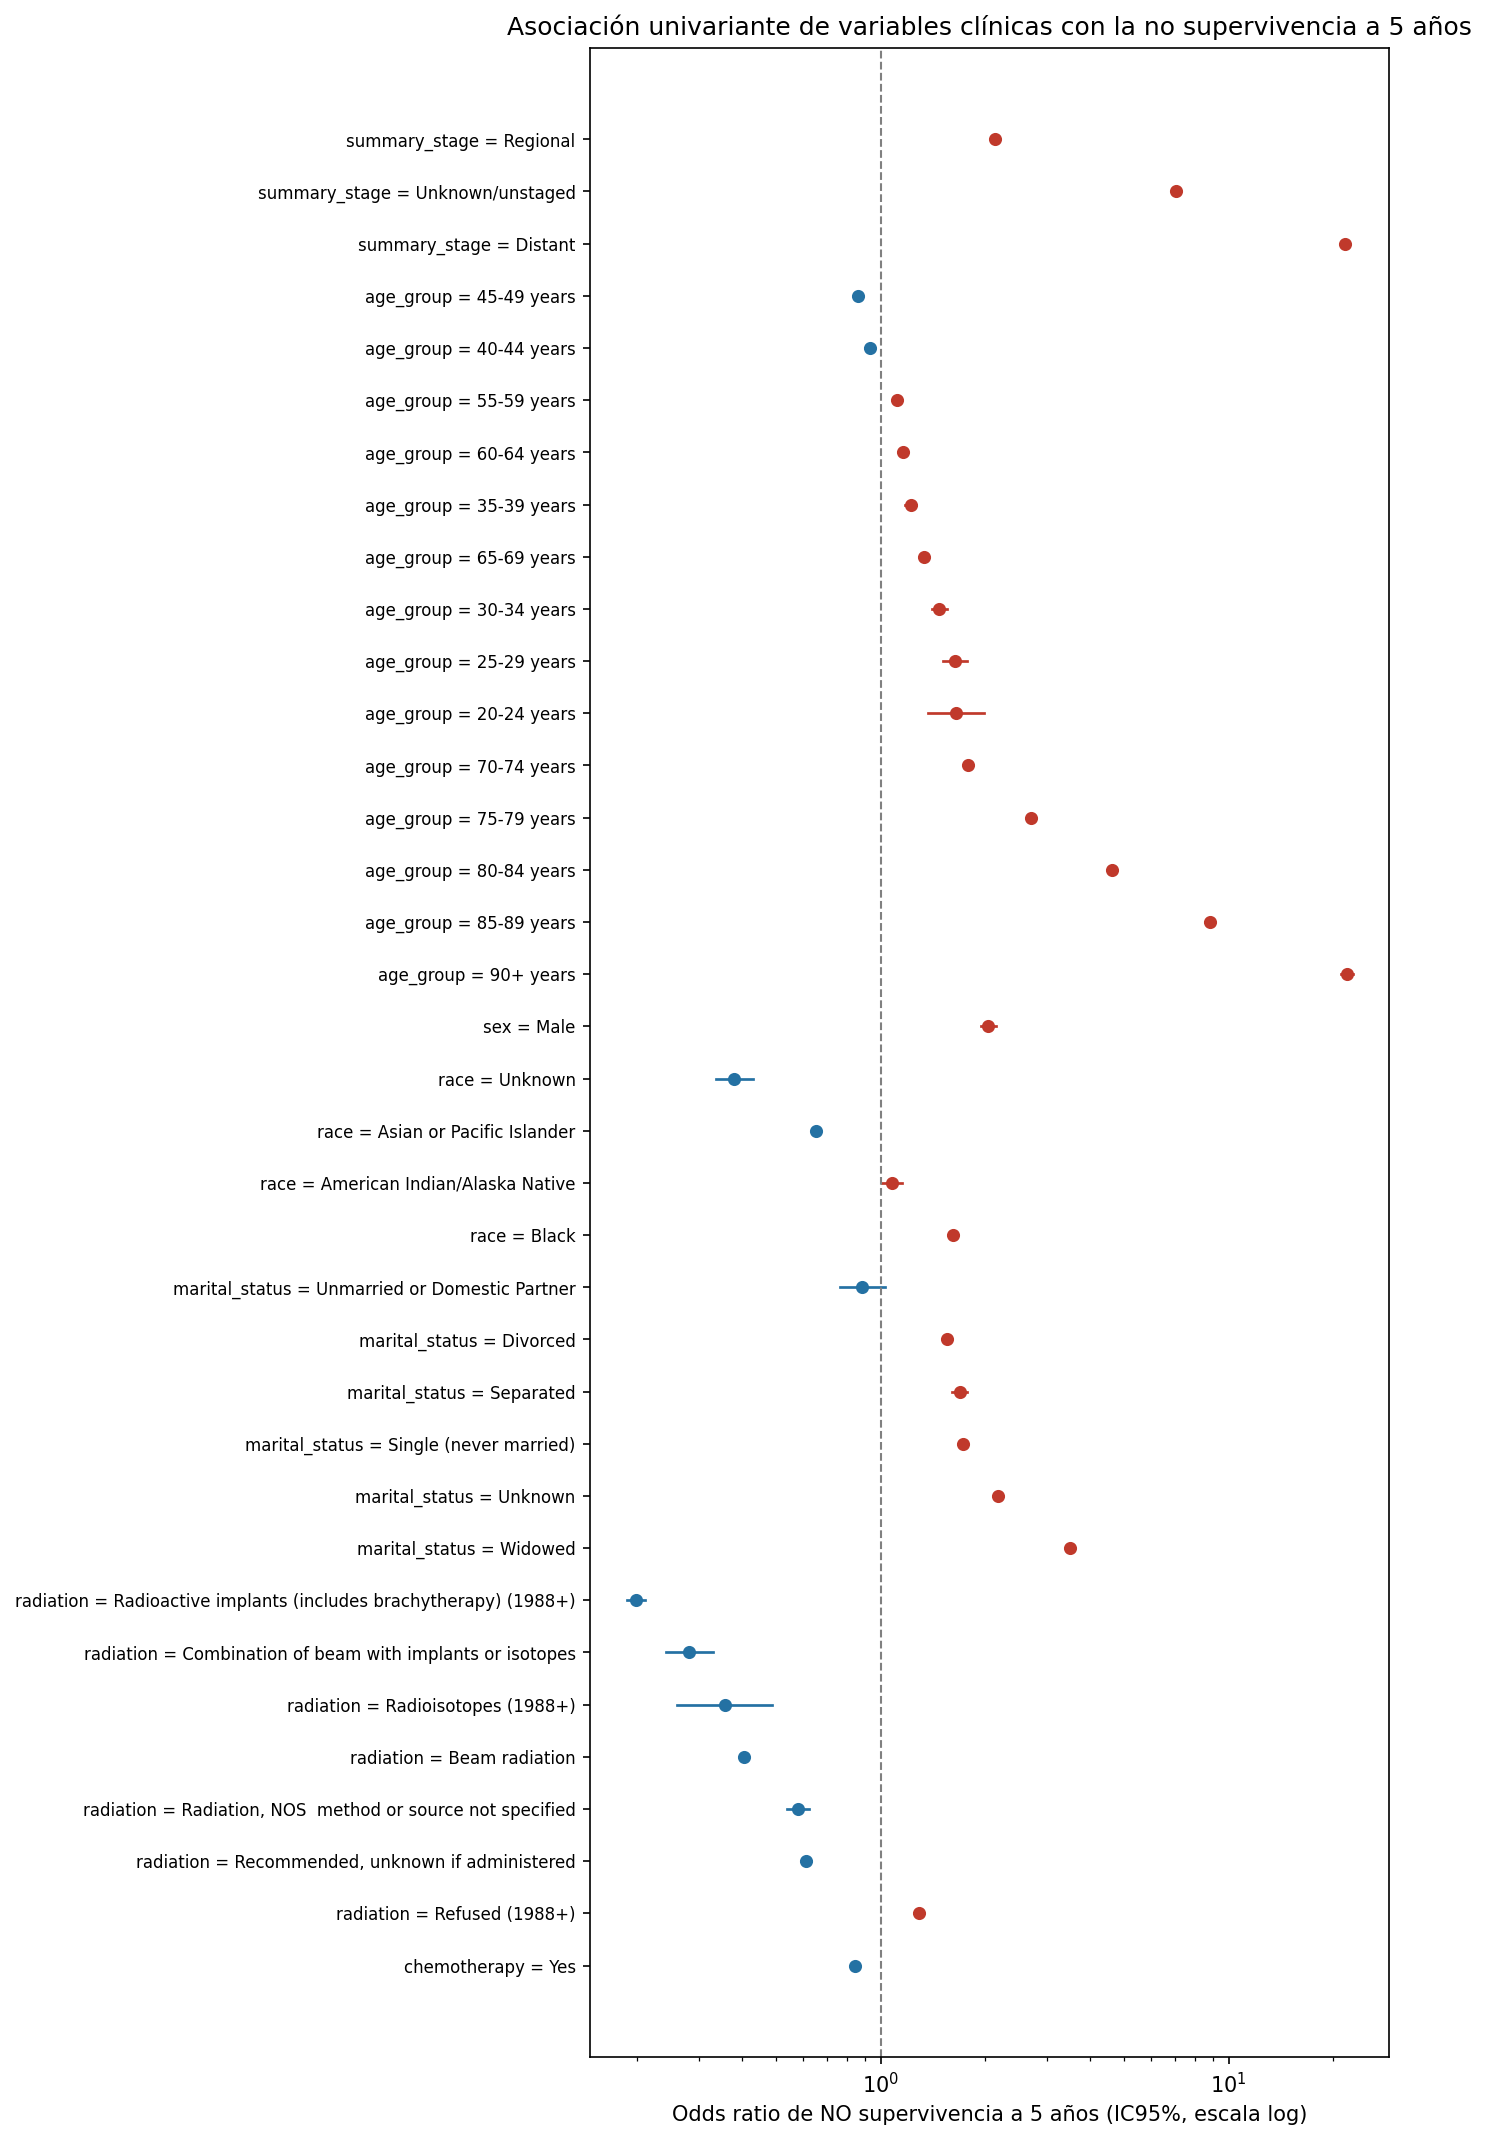

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
os.makedirs("figuras", exist_ok=True)

def odds_ratios_vs_ref(data, col, target="survived_5_years", ref_level=None, min_count=300):
    """OR de no supervivencia (clase 0) de cada nivel frente a la referencia.
    IC95% por el metodo de Woolf; correccion de Haldane-Anscombe si hay casillas a 0.
    La referencia es el nivel mas frecuente salvo que se indique."""
    vc = data[col].value_counts()
    levels = vc[vc >= min_count].index.tolist()
    if ref_level is None:
        ref_level = vc.index[0]
    ref = data[data[col] == ref_level]
    a_ref = (ref[target] == 0).sum(); b_ref = (ref[target] == 1).sum()
    out = []
    for lev in levels:
        if lev == ref_level:
            continue
        sub = data[data[col] == lev]
        a = (sub[target] == 0).sum(); b = (sub[target] == 1).sum()
        t = np.array([[a, b], [a_ref, b_ref]], dtype=float)
        if (t == 0).any():
            t += 0.5
        orr = (t[0, 0] * t[1, 1]) / (t[0, 1] * t[1, 0])
        se = np.sqrt((1.0 / t).sum())
        lo, hi = np.exp(np.log(orr) - 1.96 * se), np.exp(np.log(orr) + 1.96 * se)
        out.append({"variable": col, "nivel": str(lev), "referencia": str(ref_level),
                    "OR": round(orr, 3), "IC95_inf": round(lo, 3),
                    "IC95_sup": round(hi, 3), "n": int(a + b)})
    return pd.DataFrame(out)

forest_df = pd.concat([
    odds_ratios_vs_ref(df_model_main, "summary_stage"),
    odds_ratios_vs_ref(df_model_main, "age_group", ref_level="50-54 years"),
    odds_ratios_vs_ref(df_model_main, "sex"),
    odds_ratios_vs_ref(df_model_main, "race"),
    odds_ratios_vs_ref(df_model_main, "marital_status"),
    odds_ratios_vs_ref(df_model_main, "radiation"),
    odds_ratios_vs_ref(df_model_main, "chemotherapy"),
], ignore_index=True)

orden = ["summary_stage", "age_group", "sex", "race", "marital_status", "radiation", "chemotherapy"]
forest_df["__v"] = pd.Categorical(forest_df["variable"], categories=orden, ordered=True)
forest_df = forest_df.sort_values(["__v", "OR"]).drop(columns="__v").reset_index(drop=True)

plt.figure(figsize=(9.5, max(5, 0.40 * len(forest_df))))
labels = forest_df["variable"] + " = " + forest_df["nivel"]
colors = ["#c0392b" if orr > 1 else "#2471a3" for orr in forest_df["OR"]]
for i, (orr, lo, hi, c) in enumerate(zip(forest_df["OR"], forest_df["IC95_inf"],
                                         forest_df["IC95_sup"], colors)):
    plt.plot([lo, hi], [i, i], color=c, lw=1.3, zorder=1)
    plt.scatter([orr], [i], color=c, s=28, zorder=2)
plt.axvline(1.0, linestyle="--", color="gray", lw=1)
plt.xscale("log")
plt.yticks(range(len(forest_df)), labels, fontsize=8)
plt.gca().invert_yaxis()
plt.xlabel("Odds ratio de NO supervivencia a 5 años (IC95%, escala log)")
plt.title("Asociación univariante de variables clínicas con la no supervivencia a 5 años")
plt.tight_layout()
plt.savefig("figuras/forest_plot_or.png", dpi=300, bbox_inches="tight")
plt.show()

forest_df

# 5. Preprocesamiento para modelado

Una vez finalizado el análisis exploratorio, se prepara el dataset para el entrenamiento de modelos predictivos.

El objetivo de esta fase es transformar los datos en una estructura adecuada para los algoritmos de aprendizaje automático, manteniendo una separación estricta entre variables predictoras y variable objetivo.

Las principales tareas de esta sección son:

- Separar las variables predictoras (`X`) y la variable objetivo (`y`).
- Dividir el dataset en conjuntos de entrenamiento y prueba.
- Identificar variables categóricas y numéricas.
- Definir estrategias de imputación y codificación.
- Construir un pipeline reproducible de preprocesamiento.

Este enfoque permite evitar fuga de información y garantiza que las transformaciones se ajusten únicamente sobre el conjunto de entrenamiento.

## 5.1 Separación entre predictores y variable objetivo

Se separa el dataset principal en dos componentes:

- `X`: conjunto de variables predictoras.
- `y`: variable objetivo `survived_5_years`.

Esta separación es necesaria antes de dividir los datos en entrenamiento y prueba.

In [ ]:
X = df_model_main.drop(columns=["survived_5_years"])
y = df_model_main["survived_5_years"]

print(f"Dimensiones de X: {X.shape}")
print(f"Dimensiones de y: {y.shape}")

Dimensiones de X: (996916, 12)
Dimensiones de y: (996916,)


In [ ]:
X.head()

,age_group,sex,race,year_diagnosis,marital_status,primary_site,histologic_type,tumor_size,summary_stage,surgery_primary_site,radiation,chemotherapy
0,75-79 years,Female,White,2003,Divorced,506,8520,Blank(s),Regional,22,None/Unknown,No/Unknown
1,70-74 years,Female,Black,2010,Single (never married),509,8500,Blank(s),Localized,80,Beam radiation,No/Unknown
3,60-64 years,Female,White,2005,Widowed,501,8520,Blank(s),Regional,41,None/Unknown,No/Unknown
4,70-74 years,Female,White,2005,Widowed,509,8500,Blank(s),Regional,41,None/Unknown,No/Unknown
5,40-44 years,Female,White,2001,Married (including common law),504,8513,Blank(s),Localized,23,Beam radiation,Yes


In [ ]:
y.value_counts(normalize=True).mul(100).round(2)

,proportion
survived_5_years,
1,80.6
0,19.4


La separación entre predictores y variable objetivo permite aislar la información utilizada para entrenar los modelos de la etiqueta que se pretende predecir.

La variable objetivo mantiene la distribución observada en el análisis exploratorio, con una clase mayoritaria correspondiente a pacientes que sobreviven al menos cinco años y una clase minoritaria correspondiente a pacientes que fallecen antes de ese horizonte temporal.

## 5.2 División en entrenamiento y prueba

El dataset se divide en dos subconjuntos:

- Conjunto de entrenamiento: utilizado para ajustar los modelos.
- Conjunto de prueba: reservado para la evaluación final.

Se utiliza una división estratificada para conservar la proporción de clases de la variable objetivo en ambos subconjuntos. Esto es especialmente importante dado el desbalance moderado observado entre supervivientes y no supervivientes a cinco años.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

X_train: (797532, 12)
X_test: (199384, 12)
y_train: (797532,)
y_test: (199384,)


In [ ]:
train_target_distribution = (
    y_train
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

test_target_distribution = (
    y_test
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .round(2)
)

target_split_distribution = pd.DataFrame({
    "train_percentage": train_target_distribution,
    "test_percentage": test_target_distribution
})

target_split_distribution

,train_percentage,test_percentage
survived_5_years,,
0,19.4,19.4
1,80.6,80.6


La división estratificada permite mantener proporciones prácticamente idénticas de la variable objetivo en los conjuntos de entrenamiento y prueba.

Esto garantiza que el conjunto de prueba sea representativo del problema original y permite evaluar el rendimiento de los modelos sobre una muestra no utilizada durante el entrenamiento.

## 5.3 Identificación de tipos de variables

Antes de construir el pipeline de preprocesamiento, se identifican las variables categóricas y numéricas.

Aunque algunas variables aparecen codificadas como enteros, no todas deben tratarse como numéricas. En particular, `primary_site`, `histologic_type` y `surgery_primary_site` son códigos clínicos o administrativos, por lo que se consideran variables categóricas.

In [ ]:
categorical_features = [
    "age_group",
    "sex",
    "race",
    "marital_status",
    "primary_site",
    "histologic_type",
    "tumor_size",
    "summary_stage",
    "surgery_primary_site",
    "radiation",
    "chemotherapy"
]

numeric_features = [
    "year_diagnosis"
]

print(f"Número de variables categóricas: {len(categorical_features)}")
print(f"Número de variables numéricas: {len(numeric_features)}")

print("\nVariables categóricas:")
print(categorical_features)

print("\nVariables numéricas:")
print(numeric_features)

Número de variables categóricas: 11
Número de variables numéricas: 1

Variables categóricas:
['age_group', 'sex', 'race', 'marital_status', 'primary_site', 'histologic_type', 'tumor_size', 'summary_stage', 'surgery_primary_site', 'radiation', 'chemotherapy']

Variables numéricas:
['year_diagnosis']


In [ ]:
X_train[categorical_features] = X_train[categorical_features].astype("category")
X_test[categorical_features] = X_test[categorical_features].astype("category")

X_train[numeric_features].describe()

,year_diagnosis
count,797532.000000
mean,2008.902107
std,5.201362
min,2000.000000
25%,2004.000000
50%,2009.000000
75%,2013.000000
max,2017.000000


La mayoría de predictores se tratan como variables categóricas. Esto refleja la naturaleza del dataset SEER, compuesto principalmente por códigos clínicos, categorías diagnósticas y variables de tratamiento.

La única variable considerada inicialmente como numérica es `year_diagnosis`. No obstante, su inclusión deberá interpretarse con cautela, ya que puede capturar cambios temporales en diagnóstico, tratamiento, registro o seguimiento.

## 5.4 Revisión de valores especiales antes del modelado

Antes de construir el pipeline final, se revisan de nuevo los valores especiales presentes en el conjunto de entrenamiento. Esta comprobación permite identificar categorías como `Blank(s)`, `Unknown`, `Unknown/unstaged`, `999` o `No/Unknown`.

En esta fase no se eliminan automáticamente estos valores, ya que algunos pueden aportar información sobre la disponibilidad del dato o sobre características del registro. Sin embargo, deben quedar identificados para interpretar adecuadamente los resultados del modelo.

In [ ]:
special_values = [
    "Blank(s)",
    "Unknown",
    "Unknown/unstaged",
    "999",
    "99",
    "No/Unknown",
    "None/Unknown"
]

special_values_modeling = []

for col in categorical_features:
    counts = X_train[col].astype(str).value_counts(dropna=False)

    for value in special_values:
        if value in counts.index:
            special_values_modeling.append({
                "variable": col,
                "special_value": value,
                "count_train": counts[value],
                "percentage_train": round(counts[value] / len(X_train) * 100, 2)
            })

special_values_modeling = pd.DataFrame(special_values_modeling)

special_values_modeling

,variable,special_value,count_train,percentage_train
0,race,Unknown,2858,0.36
1,marital_status,Unknown,38026,4.77
2,tumor_size,Blank(s),698289,87.56
3,tumor_size,999,5101,0.64
4,summary_stage,Unknown/unstaged,16280,2.04
5,surgery_primary_site,99,2751,0.34
6,radiation,None/Unknown,385550,48.34
7,chemotherapy,No/Unknown,486340,60.98


La revisión de valores especiales en el conjunto de entrenamiento confirma que varias variables contienen categorías asociadas a información desconocida, no informada o ambigua.

El caso más relevante es `tumor_size`, donde la categoría `Blank(s)` aparece en 698.289 registros del conjunto de entrenamiento, lo que representa el 87,56 %. Además, el código `999`, asociado a tamaño desconocido o no especificado, aparece en el 0,64 %. Esta elevada proporción de ausencia de información limita la utilidad directa de la variable y obliga a interpretarla con cautela.

También se observan valores desconocidos en variables demográficas y clínicas. La categoría `Unknown` aparece en `race` con un 0,36 % y en `marital_status` con un 4,77 %. En `summary_stage`, la categoría `Unknown/unstaged` representa el 2,04 %, indicando ausencia o imposibilidad de estadificación.

En variables de tratamiento, la categoría `None/Unknown` en `radiation` representa el 48,34 %, mientras que `No/Unknown` en `chemotherapy` alcanza el 60,98 %. Estas categorías combinan ausencia de tratamiento con información desconocida, por lo que su interpretación clínica no es directa.

En esta fase se mantienen estos valores como categorías explícitas dentro del modelo. Esta decisión evita eliminar un volumen elevado de datos y permite que los algoritmos aprendan si la ausencia o ambigüedad de información tiene valor predictivo. No obstante, cualquier importancia asociada a estas categorías deberá interpretarse con prudencia, ya que puede reflejar patrones de registro además de características clínicas.

## 5.5 Pipeline de preprocesamiento

Se construye un pipeline de preprocesamiento para transformar las variables antes del entrenamiento de modelos.

El objetivo es definir un flujo reproducible que pueda aplicarse de forma consistente al conjunto de entrenamiento y, posteriormente, al conjunto de prueba. Esto es especialmente importante para evitar fuga de información, ya que las transformaciones deben ajustarse únicamente con los datos de entrenamiento.

El pipeline incluye:

- Imputación de valores faltantes en variables categóricas mediante la categoría más frecuente.
- Codificación One-Hot de variables categóricas.
- Imputación de valores numéricos mediante la mediana.
- Escalado de variables numéricas.

Aunque el dataset no presenta valores nulos explícitos relevantes en esta fase, se incluye imputación dentro del pipeline para garantizar robustez y evitar errores en validaciones o futuras particiones.

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ("categorical", categorical_transformer, categorical_features),
        ("numeric", numeric_transformer, numeric_features)
    ]
)

preprocessor

ColumnTransformer(transformers=[('categorical',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['age_group', 'sex', 'race', 'marital_status',
                                  'primary_site', 'histologic_type',
                                  'tumor_size', 'summary_stage',
                                  'surgery_primary_site', 'radiation',
                                  'chemotherapy']),
                                ('numeric',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['year_diagnosis'])])

El uso de `ColumnTransformer` permite aplicar transformaciones diferentes según el tipo de variable. Las variables categóricas se imputan, si fuera necesario, y posteriormente se codifican mediante One-Hot Encoding. La variable numérica `year_diagnosis` se imputa mediante la mediana y se estandariza.

El parámetro `handle_unknown="ignore"` en `OneHotEncoder` es especialmente importante, ya que permite aplicar el pipeline al conjunto de prueba aunque aparezcan categorías no observadas durante el entrenamiento.

Este pipeline se integrará posteriormente dentro de los modelos mediante objetos `Pipeline`, de forma que el preprocesamiento y el entrenamiento queden unidos en un flujo único y reproducible.

## 5.6 Comprobación del preprocesamiento

Antes de entrenar modelos predictivos, se realiza una comprobación del pipeline de preprocesamiento sobre el conjunto de entrenamiento.

Esta verificación permite confirmar que:

- Las variables categóricas se codifican correctamente.
- La variable numérica se escala adecuadamente.
- El pipeline puede ajustarse sin errores.
- El número final de variables generadas tras One-Hot Encoding es manejable.

In [ ]:
X_train_preprocessed = preprocessor.fit_transform(X_train)

print(f"Dimensiones originales de X_train: {X_train.shape}")
print(f"Dimensiones tras preprocesamiento: {X_train_preprocessed.shape}")
print(f"Tipo de matriz resultante: {type(X_train_preprocessed)}")

Dimensiones originales de X_train: (797532, 12)
Dimensiones tras preprocesamiento: (797532, 487)
Tipo de matriz resultante: <class 'scipy.sparse._csr.csr_matrix'>


In [ ]:
feature_names = preprocessor.get_feature_names_out()

print(f"Número de variables generadas tras codificación: {len(feature_names)}")
print("\nPrimeras 30 variables generadas:")
print(feature_names[:30])

Número de variables generadas tras codificación: 487

Primeras 30 variables generadas:
['categorical__age_group_01-04 years' 'categorical__age_group_05-09 years'
 'categorical__age_group_10-14 years' 'categorical__age_group_15-19 years'
 'categorical__age_group_20-24 years' 'categorical__age_group_25-29 years'
 'categorical__age_group_30-34 years' 'categorical__age_group_35-39 years'
 'categorical__age_group_40-44 years' 'categorical__age_group_45-49 years'
 'categorical__age_group_50-54 years' 'categorical__age_group_55-59 years'
 'categorical__age_group_60-64 years' 'categorical__age_group_65-69 years'
 'categorical__age_group_70-74 years' 'categorical__age_group_75-79 years'
 'categorical__age_group_80-84 years' 'categorical__age_group_85-89 years'
 'categorical__age_group_90+ years' 'categorical__sex_Female'
 'categorical__sex_Male' 'categorical__race_American Indian/Alaska Native'
 'categorical__race_Asian or Pacific Islander' 'categorical__race_Black'
 'categorical__race_Unknown'

In [ ]:
print(f"Densidad de la matriz preprocesada: {X_train_preprocessed.nnz / (X_train_preprocessed.shape[0] * X_train_preprocessed.shape[1]):.6f}")

Densidad de la matriz preprocesada: 0.024641


La comprobación del preprocesamiento confirma que el pipeline se ajusta correctamente sobre el conjunto de entrenamiento.

El conjunto original `X_train` contiene 797.532 observaciones y 12 variables predictoras. Tras aplicar el preprocesamiento, el número de columnas aumenta hasta 487 variables. Este incremento es consecuencia de la codificación One-Hot de las variables categóricas, especialmente de aquellas con mayor cardinalidad, como `histologic_type`, `tumor_size` y `surgery_primary_site`.

La matriz resultante es de tipo `csr_matrix`, es decir, una matriz dispersa. Este formato es adecuado para datos codificados mediante One-Hot Encoding, ya que la mayoría de valores generados son ceros. La densidad obtenida es 0,024641, lo que indica que aproximadamente solo el 2,46 % de las posiciones de la matriz contienen valores distintos de cero.

El número final de variables generadas es manejable para los modelos que se utilizarán en las siguientes fases. Por tanto, no es necesario aplicar en este punto una reducción adicional de dimensionalidad ni una agrupación obligatoria de categorías poco frecuentes, aunque esta posibilidad podrá reconsiderarse si algún modelo presenta problemas de rendimiento computacional o sobreajuste.

## 5.7 Resumen del preprocesamiento

En esta sección se ha preparado el dataset principal para el entrenamiento de modelos predictivos.

Las principales decisiones adoptadas han sido:

- Separar las variables predictoras y la variable objetivo.
- Dividir el dataset en entrenamiento y prueba mediante una partición estratificada.
- Tratar como categóricas las variables codificadas numéricamente que representan códigos clínicos o administrativos.
- Mantener `year_diagnosis` como única variable numérica inicial.
- Identificar valores especiales presentes en el conjunto de entrenamiento.
- Construir un pipeline de preprocesamiento basado en imputación, codificación One-Hot y escalado.
- Verificar que el pipeline transforma correctamente el conjunto de entrenamiento.

Tras el preprocesamiento, el conjunto de entrenamiento pasa de 12 variables originales a 487 variables transformadas. La matriz resultante es dispersa y presenta baja densidad, lo cual es esperable y adecuado para datos categóricos codificados mediante One-Hot Encoding.

El dataset queda preparado para la siguiente fase del proyecto: el entrenamiento de un modelo baseline que sirva como referencia inicial para comparar modelos más avanzados.

# 6. Modelo baseline

Una vez preparado el pipeline de preprocesamiento, se entrena un primer modelo baseline. El objetivo de este modelo inicial no es necesariamente obtener el mejor rendimiento posible, sino establecer una referencia sencilla y reproducible frente a la cual comparar modelos más avanzados.

En este trabajo se utiliza una regresión logística como modelo baseline por varias razones:

- Es un modelo ampliamente utilizado en problemas de clasificación binaria.
- Tiene un coste computacional bajo.
- Es más interpretable que modelos no lineales complejos.
- Permite obtener una primera referencia del rendimiento predictivo.
- Funciona adecuadamente con variables categóricas codificadas mediante One-Hot Encoding.

Dado que la variable objetivo presenta un desbalance moderado, se utiliza el parámetro `class_weight="balanced"` para compensar parcialmente la diferencia de frecuencia entre clases.

## 6.1 Entrenamiento del modelo baseline

Se construye un pipeline que integra el preprocesamiento definido anteriormente y el modelo de regresión logística.

De esta forma, el mismo flujo se encarga de transformar los datos y entrenar el modelo, evitando aplicar transformaciones manuales fuera del pipeline.

In [ ]:
from sklearn.linear_model import LogisticRegression

baseline_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

baseline_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['age_group', 'sex', 'race',
                                                   'marital_status',
                                                   'primary_site',
                                                   'histologic_type',
                                                   'tumor_size',
                                                   'summary_stage',
                                                   'surgery_primary_site',
                                                   'radiation',
                                                   'chemotherapy']),
                                                 ('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['year_diagnosis'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    n_jobs=-1, random_state=42))])

In [ ]:
baseline_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['age_group', 'sex', 'race',
                                                   'marital_status',
                                                   'primary_site',
                                                   'histologic_type',
                                                   'tumor_size',
                                                   'summary_stage',
                                                   'surgery_primary_site',
                                                   'radiation',
                                                   'chemotherapy']),
                                                 ('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['year_diagnosis'])])),
                ('classifier',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    n_jobs=-1, random_state=42))])

## 6.2 Evaluación del modelo baseline

Una vez entrenado el modelo baseline, se evalúa su rendimiento sobre el conjunto de prueba.

La evaluación se realiza utilizando varias métricas complementarias:

- `accuracy`: proporción global de predicciones correctas.
- `precision`: proporción de predicciones positivas que son realmente positivas.
- `recall`: proporción de positivos reales correctamente identificados.
- `F1-score`: media armónica entre precisión y recall.
- `ROC-AUC`: capacidad del modelo para discriminar entre ambas clases a distintos umbrales.

Dado que la clase minoritaria corresponde a pacientes que no alcanzan la supervivencia a cinco años, no se debe interpretar la exactitud global de forma aislada.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

y_pred_baseline = baseline_model.predict(X_test)
y_proba_baseline = baseline_model.predict_proba(X_test)[:, 1]

In [ ]:
baseline_metrics = {
    "accuracy": accuracy_score(y_test, y_pred_baseline),
    "precision": precision_score(y_test, y_pred_baseline),
    "recall": recall_score(y_test, y_pred_baseline),
    "f1_score": f1_score(y_test, y_pred_baseline),
    "roc_auc": roc_auc_score(y_test, y_proba_baseline)
}

baseline_metrics = pd.DataFrame([baseline_metrics]).round(4)

baseline_metrics

,accuracy,precision,recall,f1_score,roc_auc
0,0.7808,0.9162,0.8013,0.8549,0.8274


In [ ]:
print(classification_report(
    y_test,
    y_pred_baseline,
    target_names=["No sobrevive 5 años", "Sobrevive 5 años"]
))

                     precision    recall  f1-score   support

No sobrevive 5 años       0.46      0.70      0.55     38684
   Sobrevive 5 años       0.92      0.80      0.85    160700

           accuracy                           0.78    199384
          macro avg       0.69      0.75      0.70    199384
       weighted avg       0.83      0.78      0.80    199384



La regresión logística baseline obtiene una accuracy de 0,7808 y un AUC-ROC de 0,8274 sobre el conjunto de prueba. Estos resultados indican que, incluso con un modelo lineal relativamente sencillo, existe capacidad predictiva relevante a partir de las variables disponibles.

No obstante, el análisis por clase muestra diferencias importantes. Para la clase `Sobrevive 5 años`, el modelo alcanza una precisión de 0,92 y un recall de 0,80, lo que indica que identifica razonablemente bien a los pacientes que alcanzan el umbral de supervivencia a cinco años.

En cambio, para la clase `No sobrevive 5 años`, el modelo obtiene una precisión de 0,46 y un recall de 0,70. Esto significa que el modelo detecta aproximadamente el 70 % de los pacientes que no sobreviven cinco años, pero con un número considerable de falsos positivos. Es decir, muchos pacientes clasificados como no supervivientes realmente sí sobreviven al menos cinco años.

Este comportamiento es coherente con el uso de `class_weight="balanced"`, que favorece una mayor detección de la clase minoritaria a costa de reducir la precisión en dicha clase. Desde una perspectiva clínica, este equilibrio puede ser razonable en una primera aproximación, ya que resulta especialmente importante no ignorar a los pacientes con peor pronóstico.

El F1-score ponderado es 0,80, mientras que el promedio macro es 0,70, reflejando que el rendimiento no es homogéneo entre clases. Por tanto, este modelo baseline constituye una referencia útil, pero deja margen de mejora, especialmente en la reducción de falsos positivos y en el equilibrio entre precisión y recall para la clase minoritaria.

## 6.3 Matriz de confusión

La matriz de confusión permite analizar con más detalle los aciertos y errores del modelo en cada clase.

En este caso, resulta especialmente importante observar:

- Verdaderos negativos: pacientes que no sobreviven cinco años y son correctamente clasificados como no supervivientes.
- Falsos positivos: pacientes que no sobreviven cinco años pero son clasificados como supervivientes.
- Falsos negativos: pacientes que sobreviven cinco años pero son clasificados como no supervivientes.
- Verdaderos positivos: pacientes que sobreviven cinco años y son correctamente clasificados como supervivientes.

Esta matriz permite complementar las métricas agregadas y entender mejor el comportamiento del modelo.

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

cm_baseline = confusion_matrix(y_test, y_pred_baseline)

cm_baseline

array([[ 26907,  11777],
       [ 31932, 128768]])

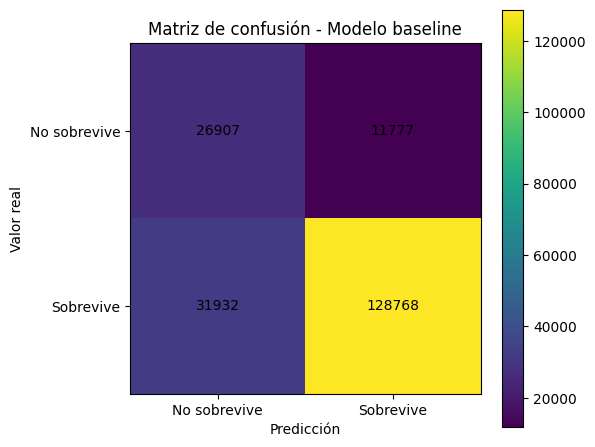

In [ ]:
plt.figure(figsize=(6, 5))

plt.imshow(cm_baseline)
plt.title("Matriz de confusión - Modelo baseline")
plt.xlabel("Predicción")
plt.ylabel("Valor real")

plt.xticks(
    ticks=[0, 1],
    labels=["No sobrevive", "Sobrevive"]
)
plt.yticks(
    ticks=[0, 1],
    labels=["No sobrevive", "Sobrevive"]
)

for i in range(cm_baseline.shape[0]):
    for j in range(cm_baseline.shape[1]):
        plt.text(
            j,
            i,
            cm_baseline[i, j],
            ha="center",
            va="center"
        )

plt.colorbar()
plt.tight_layout()
plt.show()

In [ ]:
tn, fp, fn, tp = cm_baseline.ravel()

confusion_summary = pd.DataFrame({
    "metric": [
        "Verdaderos negativos",
        "Falsos positivos",
        "Falsos negativos",
        "Verdaderos positivos"
    ],
    "count": [tn, fp, fn, tp]
})

confusion_summary

,metric,count
0,Verdaderos negativos,26907
1,Falsos positivos,11777
2,Falsos negativos,31932
3,Verdaderos positivos,128768


La matriz de confusión permite observar con mayor detalle el comportamiento del modelo baseline.

El modelo clasifica correctamente como no supervivientes a 26.907 pacientes que fallecen antes de los cinco años. Sin embargo, 11.777 pacientes que no sobreviven a cinco años son clasificados erróneamente como supervivientes. Estos falsos positivos son especialmente relevantes desde el punto de vista clínico, ya que representan casos de peor pronóstico que el modelo no identifica correctamente.

Por otro lado, el modelo clasifica correctamente como supervivientes a 128.768 pacientes, mientras que 31.932 pacientes que realmente sobreviven al menos cinco años son clasificados erróneamente como no supervivientes. Este número de falsos negativos es elevado en términos absolutos, aunque debe interpretarse teniendo en cuenta que la clase de supervivientes es mucho más numerosa.

En conjunto, la matriz de confusión confirma el comportamiento observado en el informe de clasificación: la regresión logística con pesos balanceados mejora la detección de la clase minoritaria, pero todavía comete un número considerable de errores en ambas direcciones. El modelo consigue detectar una parte importante de los pacientes que no sobreviven cinco años, pero a costa de clasificar erróneamente como no supervivientes a un número relevante de pacientes que sí alcanzan ese horizonte temporal.

Este análisis refuerza la necesidad de comparar el baseline con modelos más flexibles y de evaluar distintas métricas, especialmente aquellas sensibles al rendimiento en la clase minoritaria.

## 6.4 Curva ROC y AUC

La curva ROC permite analizar la capacidad discriminativa del modelo a distintos umbrales de decisión. A diferencia de métricas calculadas con un umbral fijo, como accuracy o F1-score, la curva ROC evalúa el comportamiento del modelo considerando todos los posibles puntos de corte.

El área bajo la curva ROC, o AUC-ROC, resume esta capacidad discriminativa en un único valor. Un valor cercano a 0,5 indica un comportamiento similar al azar, mientras que valores más próximos a 1 indican mayor capacidad para separar ambas clases.

In [ ]:
from sklearn.metrics import roc_curve, auc

fpr_baseline, tpr_baseline, thresholds_baseline = roc_curve(
    y_test,
    y_proba_baseline
)

roc_auc_baseline = auc(fpr_baseline, tpr_baseline)

roc_auc_baseline

np.float64(0.8274262984614476)

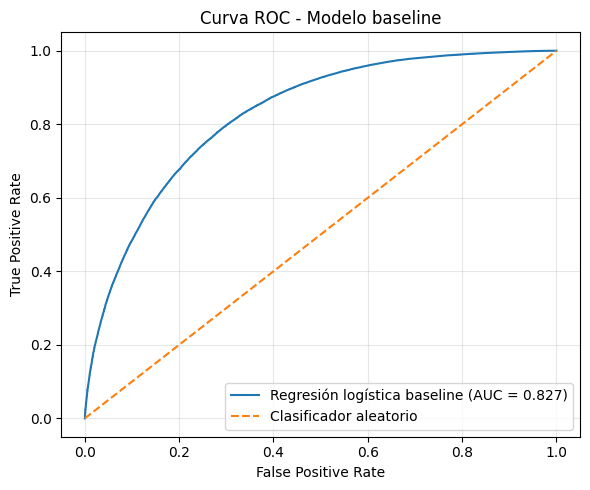

In [ ]:
plt.figure(figsize=(6, 5))

plt.plot(
    fpr_baseline,
    tpr_baseline,
    label=f"Regresión logística baseline (AUC = {roc_auc_baseline:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Clasificador aleatorio"
)

plt.title("Curva ROC - Modelo baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

El modelo baseline obtiene un AUC-ROC de 0,8274. Este valor indica que la regresión logística tiene una capacidad discriminativa razonablemente buena para separar pacientes que sobreviven al menos cinco años de aquellos que fallecen antes de ese horizonte temporal.

El resultado es especialmente relevante porque se obtiene con un modelo lineal e interpretable, lo que confirma que las variables disponibles contienen información predictiva útil. No obstante, el AUC debe interpretarse junto con el resto de métricas, ya que no refleja por sí solo el equilibrio entre precisión y recall en cada clase.

La curva ROC servirá como referencia para comparar modelos más complejos en fases posteriores. El objetivo será comprobar si algoritmos no lineales, como Random Forest o modelos de boosting, son capaces de mejorar la capacidad discriminativa del baseline sin empeorar de forma significativa la interpretabilidad ni el equilibrio entre clases.

## 6.5 Resumen del modelo baseline

En esta sección se ha entrenado y evaluado un primer modelo baseline basado en regresión logística con pesos balanceados.

Los principales resultados obtenidos son:

- Accuracy: 0,7808.
- Precision para la clase superviviente: 0,9162.
- Recall para la clase superviviente: 0,8013.
- F1-score global para la clase positiva: 0,8549.
- AUC-ROC: 0,8274.

El análisis por clase muestra que el modelo identifica razonablemente bien a los pacientes que sobreviven al menos cinco años, aunque presenta más dificultades para clasificar de forma precisa a los pacientes que fallecen antes de dicho horizonte temporal.

La matriz de confusión muestra que el modelo detecta correctamente 26.907 casos de no supervivencia y 128.768 casos de supervivencia. Sin embargo, también produce 11.777 falsos positivos y 31.932 falsos negativos.

En conjunto, la regresión logística constituye un baseline sólido y metodológicamente adecuado. El rendimiento obtenido confirma que existe señal predictiva en las variables seleccionadas, pero también deja margen de mejora, especialmente en el equilibrio entre clases y en la reducción de errores sobre la clase minoritaria.

En las siguientes fases se entrenarán modelos más flexibles para evaluar si son capaces de mejorar el rendimiento del baseline.

# 7. Entrenamiento de modelos avanzados

Una vez establecido el rendimiento del modelo baseline, se entrenan modelos más flexibles con el objetivo de evaluar si pueden mejorar la capacidad predictiva.

El modelo baseline basado en regresión logística ha proporcionado una referencia sólida, con un AUC-ROC de 0,8274. Sin embargo, al tratarse de un modelo lineal, puede tener limitaciones para capturar relaciones no lineales e interacciones complejas entre variables clínicas, demográficas y de tratamiento.

En esta sección se entrenarán modelos adicionales y se compararán con el baseline utilizando las mismas métricas de evaluación.

## 7.1 Función común de evaluación

Para comparar los modelos de forma homogénea, se define una función que calcula las principales métricas de clasificación sobre el conjunto de prueba.

La función devuelve:

- Accuracy.
- Precision.
- Recall.
- F1-score.
- ROC-AUC.
- Classification report.
- Matriz de confusión.

Esta función permitirá evaluar todos los modelos bajo el mismo criterio.

In [ ]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    confusion_matrix
)

def evaluate_model(model, X_test, y_test, model_name):
    """
    Evalúa un modelo de clasificación binaria sobre el conjunto de prueba.

    Parámetros:
    - model: pipeline o modelo entrenado.
    - X_test: variables predictoras del conjunto de prueba.
    - y_test: variable objetivo real.
    - model_name: nombre del modelo evaluado.

    Devuelve:
    - Diccionario con métricas principales.
    - Predicciones de clase.
    - Probabilidades estimadas para la clase positiva.
    - Matriz de confusión.
    """

    y_pred = model.predict(X_test)

    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
    else:
        y_proba = model.decision_function(X_test)

    metrics = {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1_score": f1_score(y_test, y_pred),
        "roc_auc": roc_auc_score(y_test, y_proba)
    }

    cm = confusion_matrix(y_test, y_pred)

    print(f"===== {model_name} =====")
    print("\nClassification report:")
    print(classification_report(
        y_test,
        y_pred,
        target_names=["No sobrevive 5 años", "Sobrevive 5 años"]
    ))

    print("\nMatriz de confusión:")
    print(cm)

    return metrics, y_pred, y_proba, cm

La función anterior permite estandarizar la evaluación de los modelos. A partir de este punto, todos los algoritmos entrenados se evaluarán de la misma forma, facilitando la comparación posterior.

Además, las métricas se almacenarán en una lista para construir una tabla final comparativa.

In [ ]:
model_results = []

baseline_result = {
    "model": "Logistic Regression Baseline",
    "accuracy": 0.7808,
    "precision": 0.9162,
    "recall": 0.8013,
    "f1_score": 0.8549,
    "roc_auc": 0.8274
}

model_results.append(baseline_result)

pd.DataFrame(model_results)

,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression Baseline,0.7808,0.9162,0.8013,0.8549,0.8274


La tabla de resultados se inicializa con el modelo baseline de regresión logística. Esta tabla se irá ampliando a medida que se entrenen modelos adicionales, permitiendo comparar el rendimiento de todos ellos bajo las mismas métricas.

El baseline servirá como referencia mínima: los modelos avanzados deberán mejorar, o al menos igualar, su rendimiento para justificar una mayor complejidad.

## 7.2 Random Forest

El primer modelo avanzado entrenado es un Random Forest. Este algoritmo construye un conjunto de árboles de decisión y combina sus predicciones, lo que permite capturar relaciones no lineales e interacciones entre variables.

A diferencia de la regresión logística, Random Forest no asume una relación lineal entre los predictores y la variable objetivo. Esto puede resultar útil en un problema clínico, donde la supervivencia puede depender de combinaciones complejas entre edad, estadio, tipo tumoral y tratamiento.

No obstante, dado el gran tamaño del dataset y el aumento de dimensionalidad producido por One-Hot Encoding, se utiliza una configuración controlada para limitar el coste computacional.

In [ ]:
from sklearn.ensemble import RandomForestClassifier

random_forest_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        min_samples_leaf=50,
        class_weight="balanced",
        random_state=42,
        n_jobs=-1
    ))
])

random_forest_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['age_group', 'sex', 'race',
                                                   'marital_status',
                                                   'primary_site',
                                                   'histologic_type',
                                                   'tumor_size',
                                                   'summary_stage',
                                                   'surgery_primary_site',
                                                   'radiation',
                                                   'chemotherapy']),
                                                 ('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['year_diagnosis'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=20,
                                        min_samples_leaf=50, n_jobs=-1,
                                        random_state=42))])

### Entrenamiento del modelo Random Forest

Se entrena el modelo Random Forest sobre el conjunto de entrenamiento. El preprocesamiento se aplica dentro del propio pipeline, garantizando que las transformaciones se ajustan únicamente con los datos de entrenamiento.

In [ ]:
random_forest_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['age_group', 'sex', 'race',
                                                   'marital_status',
                                                   'primary_site',
                                                   'histologic_type',
                                                   'tumor_size',
                                                   'summary_stage',
                                                   'surgery_primary_site',
                                                   'radiation',
                                                   'chemotherapy']),
                                                 ('numeric',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['year_diagnosis'])])),
                ('classifier',
                 RandomForestClassifier(class_weight='balanced', max_depth=20,
                                        min_samples_leaf=50, n_jobs=-1,
                                        random_state=42))])

### Evaluación del modelo Random Forest

Una vez entrenado el modelo Random Forest, se evalúa sobre el conjunto de prueba utilizando la función común de evaluación definida anteriormente.

Los resultados se añadirán a la tabla comparativa de modelos para contrastar su rendimiento frente al baseline de regresión logística.

In [ ]:
rf_metrics, y_pred_rf, y_proba_rf, cm_rf = evaluate_model(
    random_forest_model,
    X_test,
    y_test,
    model_name="Random Forest"
)

rf_metrics

===== Random Forest =====

Classification report:
                     precision    recall  f1-score   support

No sobrevive 5 años       0.45      0.70      0.54     38684
   Sobrevive 5 años       0.92      0.79      0.85    160700

           accuracy                           0.77    199384
          macro avg       0.68      0.74      0.70    199384
       weighted avg       0.82      0.77      0.79    199384


Matriz de confusión:
[[ 26898  11786]
 [ 33170 127530]]


{'model': 'Random Forest',
 'accuracy': 0.7745255386590699,
 'precision': 0.9154009589709725,
 'recall': 0.7935905413814561,
 'f1_score': 0.8501546584182177,
 'roc_auc': np.float64(0.8218693689947499)}

In [ ]:
model_results.append(rf_metrics)

results_df = pd.DataFrame(model_results).round(4)
results_df

,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression Baseline,0.7808,0.9162,0.8013,0.8549,0.8274
1,Random Forest,0.7745,0.9154,0.7936,0.8502,0.8219


El modelo Random Forest no mejora el rendimiento del baseline de regresión logística. Obtiene una accuracy de 0,7745 y un AUC-ROC de 0,8219, ambos ligeramente inferiores a los valores obtenidos por la regresión logística, que alcanzaba una accuracy de 0,7808 y un AUC-ROC de 0,8274.

El comportamiento por clase es muy similar al del baseline. Para la clase `No sobrevive 5 años`, Random Forest obtiene una precisión de 0,45 y un recall de 0,70. Esto indica que detecta una proporción relevante de pacientes que no alcanzan la supervivencia a cinco años, pero con una precisión limitada. Para la clase `Sobrevive 5 años`, alcanza una precisión de 0,92 y un recall de 0,79.

La matriz de confusión muestra 26.898 verdaderos negativos, 11.786 falsos positivos, 33.170 falsos negativos y 127.530 verdaderos positivos. En comparación con la regresión logística, el Random Forest mantiene prácticamente el mismo número de verdaderos negativos, pero aumenta los falsos negativos, lo que reduce ligeramente el recall de la clase superviviente.

Estos resultados sugieren que, con la configuración controlada utilizada, Random Forest no consigue capturar patrones adicionales que mejoren el modelo lineal. Es posible que una optimización más amplia de hiperparámetros mejore su rendimiento, pero dado el tamaño del dataset y el coste computacional asociado, se priorizará también la evaluación de otros modelos más adecuados para datos tabulares de gran volumen, como métodos de boosting.

## 7.3 XGBoost

El siguiente modelo evaluado es XGBoost, un algoritmo de boosting basado en árboles de decisión. A diferencia de Random Forest, que construye árboles de forma independiente, XGBoost entrena árboles de manera secuencial, intentando corregir los errores cometidos por los modelos anteriores.

Este tipo de modelos suele ofrecer buen rendimiento en datos tabulares y puede capturar relaciones no lineales e interacciones entre variables. Además, XGBoost puede trabajar eficientemente con matrices dispersas generadas por One-Hot Encoding.

Dado el tamaño del dataset, se utiliza una configuración inicial moderada para controlar el coste computacional.

In [ ]:
from xgboost import XGBClassifier

xgb_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=300,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),
        random_state=42,
        n_jobs=-1
    ))
])

xgb_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['age_group', 'sex', 'race',
                                                   'marital_status',
                                                   'primary_site',
                                                   'histologic_type',
                                                   'tumor_size',
                                                   'summary_stage',
                                                   'surgery_primary_site',
                                                   'radiation',
                                                   'chemother...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

### Entrenamiento del modelo XGBoost

Se entrena el modelo XGBoost sobre el conjunto de entrenamiento. El preprocesamiento se aplica dentro del pipeline, igual que en los modelos anteriores.

In [ ]:
xgb_model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['age_group', 'sex', 'race',
                                                   'marital_status',
                                                   'primary_site',
                                                   'histologic_type',
                                                   'tumor_size',
                                                   'summary_stage',
                                                   'surgery_primary_site',
                                                   'radiation',
                                                   'chemother...
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=0.05,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=4, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=300, n_jobs=-1,
                               num_parallel_tree=None, ...))])

### Evaluación del modelo XGBoost

Una vez entrenado el modelo XGBoost, se evalúa sobre el conjunto de prueba utilizando la misma función común empleada para los modelos anteriores.

Los resultados se incorporan a la tabla comparativa para analizar si el modelo de boosting mejora el rendimiento del baseline y del Random Forest.

In [ ]:
xgb_metrics, y_pred_xgb, y_proba_xgb, cm_xgb = evaluate_model(
    xgb_model,
    X_test,
    y_test,
    model_name="XGBoost"
)

xgb_metrics

===== XGBoost =====

Classification report:
                     precision    recall  f1-score   support

No sobrevive 5 años       0.45      0.70      0.55     38684
   Sobrevive 5 años       0.92      0.80      0.85    160700

           accuracy                           0.78    199384
          macro avg       0.69      0.75      0.70    199384
       weighted avg       0.83      0.78      0.79    199384


Matriz de confusión:
[[ 27104  11580]
 [ 32625 128075]]


{'model': 'XGBoost',
 'accuracy': 0.7782921397905549,
 'precision': 0.9170813791128137,
 'recall': 0.7969819539514623,
 'f1_score': 0.8528241580796058,
 'roc_auc': np.float64(0.828193204289835)}

In [ ]:
model_results.append(xgb_metrics)

results_df = pd.DataFrame(model_results).round(4)
results_df

,model,accuracy,precision,recall,f1_score,roc_auc
0,Logistic Regression Baseline,0.7808,0.9162,0.8013,0.8549,0.8274
1,Random Forest,0.7745,0.9154,0.7936,0.8502,0.8219
2,XGBoost,0.7783,0.9171,0.7970,0.8528,0.8282


El modelo XGBoost obtiene una accuracy de 0,7783 y un AUC-ROC de 0,8282. Este AUC es ligeramente superior al obtenido por la regresión logística baseline, que alcanzaba 0,8274, y también superior al Random Forest, que obtuvo 0,8219. Sin embargo, la mejora respecto al baseline es muy pequeña.

En el análisis por clase, XGBoost obtiene para la clase `No sobrevive 5 años` una precisión de 0,45, un recall de 0,70 y un F1-score de 0,55. Estos valores son prácticamente equivalentes a los obtenidos por la regresión logística, aunque con una ligera mejora en el número de verdaderos negativos.

Para la clase `Sobrevive 5 años`, el modelo alcanza una precisión de 0,92, un recall de 0,80 y un F1-score de 0,85. El comportamiento vuelve a ser muy similar al baseline, lo que indica que el modelo de boosting no aporta una mejora sustancial con la configuración inicial utilizada.

La matriz de confusión muestra 27.104 verdaderos negativos, 11.580 falsos positivos, 32.625 falsos negativos y 128.075 verdaderos positivos. En comparación con la regresión logística, XGBoost reduce ligeramente los falsos positivos y aumenta los verdaderos negativos, pero también incrementa los falsos negativos y reduce ligeramente los verdaderos positivos.

En conjunto, XGBoost ofrece el mejor AUC-ROC de los tres modelos evaluados hasta ahora, pero la diferencia frente al baseline es marginal. Esto sugiere que, con las variables actuales y el preprocesamiento aplicado, gran parte de la señal predictiva puede estar siendo capturada ya por el modelo lineal. No obstante, XGBoost sigue siendo un candidato relevante para una posible optimización de hiperparámetros.

## 7.4 Comparación parcial de modelos

Tras entrenar la regresión logística baseline, Random Forest y XGBoost, se comparan sus métricas principales sobre el conjunto de prueba.

Esta comparación permite evaluar si los modelos más complejos aportan una mejora sustancial respecto al baseline.

In [ ]:
results_df.sort_values(by="roc_auc", ascending=False)

,model,accuracy,precision,recall,f1_score,roc_auc
2,XGBoost,0.7783,0.9171,0.7970,0.8528,0.8282
0,Logistic Regression Baseline,0.7808,0.9162,0.8013,0.8549,0.8274
1,Random Forest,0.7745,0.9154,0.7936,0.8502,0.8219


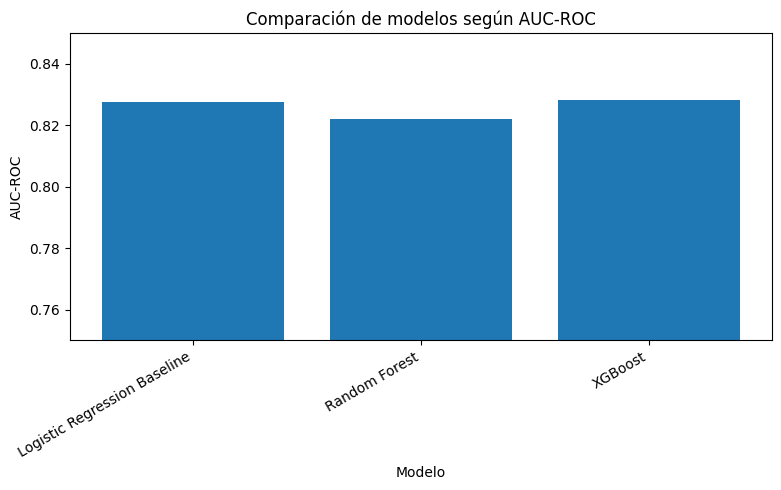

In [ ]:
plt.figure(figsize=(8, 5))

plt.bar(
    results_df["model"],
    results_df["roc_auc"]
)

plt.title("Comparación de modelos según AUC-ROC")
plt.xlabel("Modelo")
plt.ylabel("AUC-ROC")
plt.ylim(0.75, 0.85)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
metrics_to_plot = ["accuracy", "precision", "recall", "f1_score", "roc_auc"]

results_plot = results_df.set_index("model")[metrics_to_plot]

results_plot

,accuracy,precision,recall,f1_score,roc_auc
model,,,,,
Logistic Regression Baseline,0.7808,0.9162,0.8013,0.8549,0.8274
Random Forest,0.7745,0.9154,0.7936,0.8502,0.8219
XGBoost,0.7783,0.9171,0.7970,0.8528,0.8282


La comparación parcial muestra que los tres modelos presentan rendimientos muy similares. XGBoost obtiene el AUC-ROC más alto, aunque la diferencia respecto a la regresión logística baseline es muy reducida.

Esta situación sugiere que la complejidad adicional de los modelos basados en árboles no se traduce, por el momento, en una mejora clara del rendimiento predictivo. En consecuencia, será necesario valorar si merece la pena realizar una optimización de hiperparámetros o si resulta más adecuado priorizar un modelo más simple e interpretable.

## 7.5 Optimización ligera de XGBoost

Dado que XGBoost ha obtenido el mejor AUC-ROC entre los modelos evaluados, se realiza una optimización ligera de hiperparámetros.

El objetivo de esta búsqueda no es explorar exhaustivamente todo el espacio de parámetros, sino comprobar si una configuración ligeramente ajustada puede mejorar el rendimiento del modelo inicial.

Debido al tamaño del dataset, se limita el número de combinaciones evaluadas para mantener un coste computacional razonable.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import randint, uniform

xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        objective="binary:logistic",
        eval_metric="logloss",
        scale_pos_weight=(y_train.value_counts()[0] / y_train.value_counts()[1]),
        random_state=42,
        n_jobs=-1
    ))
])

param_distributions = {
    "classifier__n_estimators": randint(200, 500),
    "classifier__max_depth": randint(3, 7),
    "classifier__learning_rate": uniform(0.03, 0.07),
    "classifier__subsample": uniform(0.75, 0.25),
    "classifier__colsample_bytree": uniform(0.75, 0.25),
    "classifier__min_child_weight": randint(1, 8)
}

xgb_random_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_distributions,
    n_iter=10,
    scoring="roc_auc",
    cv=3,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

xgb_random_search

RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('categorical',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('encoder',
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['age_group',
                                                                                'sex',
                                                                                'race',
                                                                                'marital_status',
                                                                                'primary_site',
                                                                                'histologic_type',
                                                                                'tumor_size',
                                                                                'summary_stage',
                                                                                'surgery_pr...
                                        'classifier__min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f79bf51d580>,
                                        'classifier__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f79bf5db350>,
                                        'classifier__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7f79bf19eb40>},
                   random_state=42, scoring='roc_auc', verbose=1)

### Entrenamiento de la búsqueda aleatoria

Se ejecuta la búsqueda aleatoria sobre el conjunto de entrenamiento. La métrica utilizada para seleccionar el mejor modelo es `roc_auc`, ya que evalúa la capacidad discriminativa del modelo a distintos umbrales de decisión.

In [ ]:
xgb_random_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


RandomizedSearchCV(cv=3,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('categorical',
                                                                               Pipeline(steps=[('imputer',
                                                                                                SimpleImputer(strategy='most_frequent')),
                                                                                               ('encoder',
                                                                                                OneHotEncoder(handle_unknown='ignore'))]),
                                                                               ['age_group',
                                                                                'sex',
                                                                                'race',
                                                                                'marital_status',
                                                                                'primary_site',
                                                                                'histologic_type',
                                                                                'tumor_size',
                                                                                'summary_stage',
                                                                                'surgery_pr...
                                        'classifier__min_child_weight': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f79bf51d580>,
                                        'classifier__n_estimators': <scipy.stats._distn_infrastructure.rv_discrete_frozen object at 0x7f79bf5db350>,
                                        'classifier__subsample': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7f79bf19eb40>},
                   random_state=42, scoring='roc_auc', verbose=1)

In [ ]:
print("Mejores hiperparámetros encontrados:")
print(xgb_random_search.best_params_)

print("\nMejor AUC medio en validación cruzada:")
print(xgb_random_search.best_score_)

Mejores hiperparámetros encontrados:
{'classifier__colsample_bytree': np.float64(0.8102563665065029), 'classifier__learning_rate': np.float64(0.07782844631778207), 'classifier__max_depth': 6, 'classifier__min_child_weight': 5, 'classifier__n_estimators': 463, 'classifier__subsample': np.float64(0.7585971302788046)}

Mejor AUC medio en validación cruzada:
0.8313900637019924


In [ ]:
best_xgb_model = xgb_random_search.best_estimator_
best_xgb_model

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['age_group', 'sex', 'race',
                                                   'marital_status',
                                                   'primary_site',
                                                   'histologic_type',
                                                   'tumor_size',
                                                   'summary_stage',
                                                   'surgery_primary_site',
                                                   'radiation',
                                                   'chemother...
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None,
                               learning_rate=np.float64(0.07782844631778207),
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=6, max_leaves=None, min_child_weight=5,
                               missing=nan, monotone_constraints=None,
                               multi_strategy=None, n_estimators=463, n_jobs=-1,
                               num_parallel_tree=None, ...))])

La búsqueda aleatoria identifica una configuración de XGBoost con un AUC medio en validación cruzada de 0,8314. Este valor es superior al AUC obtenido por el XGBoost inicial sobre el conjunto de prueba, que era 0,8282, y también superior al baseline de regresión logística, que obtuvo 0,8274.

Los hiperparámetros seleccionados corresponden a un modelo algo más complejo que el XGBoost inicial, con `max_depth=6` y `n_estimators=463`. La tasa de aprendizaje seleccionada es aproximadamente 0,0778, junto con submuestreo de filas y columnas, lo que ayuda a controlar el sobreajuste.

No obstante, el resultado de validación cruzada debe confirmarse sobre el conjunto de prueba, que no ha sido utilizado para seleccionar los hiperparámetros. Por ello, el siguiente paso consiste en evaluar el mejor modelo encontrado sobre `X_test` y comparar sus resultados con el resto de modelos.

### Evaluación del XGBoost optimizado

Una vez seleccionada la mejor configuración mediante validación cruzada, se evalúa el modelo optimizado sobre el conjunto de prueba.

Esta evaluación permite comprobar si la mejora observada durante la búsqueda de hiperparámetros se mantiene sobre datos no utilizados durante el entrenamiento ni durante la selección del modelo.

In [ ]:
best_xgb_metrics, y_pred_best_xgb, y_proba_best_xgb, cm_best_xgb = evaluate_model(
    best_xgb_model,
    X_test,
    y_test,
    model_name="XGBoost Optimizado"
)

best_xgb_metrics

===== XGBoost Optimizado =====

Classification report:
                     precision    recall  f1-score   support

No sobrevive 5 años       0.45      0.71      0.55     38684
   Sobrevive 5 años       0.92      0.79      0.85    160700

           accuracy                           0.77    199384
          macro avg       0.68      0.75      0.70    199384
       weighted avg       0.83      0.77      0.79    199384


Matriz de confusión:
[[ 27594  11090]
 [ 33828 126872]]


{'model': 'XGBoost Optimizado',
 'accuracy': 0.7747161256670545,
 'precision': 0.9196155463098534,
 'recall': 0.7894959551960175,
 'f1_score': 0.8496025607542975,
 'roc_auc': np.float64(0.83162777799369)}

In [ ]:
model_results.append(best_xgb_metrics)

results_df = pd.DataFrame(model_results).round(4)
results_df.sort_values(by="roc_auc", ascending=False)

,model,accuracy,precision,recall,f1_score,roc_auc
3,XGBoost Optimizado,0.7747,0.9196,0.7895,0.8496,0.8316
2,XGBoost,0.7783,0.9171,0.7970,0.8528,0.8282
0,Logistic Regression Baseline,0.7808,0.9162,0.8013,0.8549,0.8274
1,Random Forest,0.7745,0.9154,0.7936,0.8502,0.8219


El XGBoost optimizado obtiene el mejor AUC-ROC de todos los modelos evaluados, con un valor de 0,8316. Este resultado mejora ligeramente al XGBoost inicial, que alcanzaba 0,8282, y al baseline de regresión logística, que obtenía 0,8274. Por tanto, la optimización ligera de hiperparámetros sí mejora la capacidad discriminativa global del modelo.

Sin embargo, esta mejora en AUC no se traduce en una mejora general de todas las métricas. La accuracy del modelo optimizado es 0,7747, inferior a la regresión logística baseline, que alcanzaba 0,7808. El F1-score de la clase positiva también disminuye ligeramente respecto al baseline, pasando de 0,8549 a 0,8496.

En el análisis por clase, el XGBoost optimizado obtiene para la clase `No sobrevive 5 años` una precisión de 0,45, un recall de 0,71 y un F1-score de 0,55. Este recall es ligeramente superior al de los modelos anteriores, lo que indica que el modelo optimizado identifica algo mejor a los pacientes que no alcanzan la supervivencia a cinco años.

La matriz de confusión muestra 27.594 verdaderos negativos y 11.090 falsos positivos para la clase de no supervivencia. En comparación con el XGBoost inicial, el modelo optimizado reduce los falsos positivos y aumenta los verdaderos negativos. Sin embargo, también aumenta los falsos negativos hasta 33.828 y reduce los verdaderos positivos a 126.872, lo que explica la caída en recall para la clase superviviente.

En conjunto, el XGBoost optimizado ofrece la mejor capacidad discriminativa medida por AUC-ROC, pero no domina claramente al baseline en todas las métricas. Esta situación refleja un compromiso entre detectar mejor a la clase minoritaria y mantener un buen rendimiento global. La elección final del modelo dependerá de qué métrica se considere prioritaria: si se prioriza AUC-ROC y detección de pacientes de peor pronóstico, el XGBoost optimizado es el candidato más fuerte; si se prioriza simplicidad, estabilidad e interpretabilidad, la regresión logística sigue siendo una alternativa muy competitiva.

## 7.6 Criterio de selección de métricas en contexto clínico

En un problema médico de predicción pronóstica, no todas las métricas tienen la misma importancia. La selección del modelo no debe basarse únicamente en la exactitud global, ya que el dataset presenta un desbalance moderado y la clase de mayor interés clínico es la de pacientes que no alcanzan la supervivencia a cinco años.

En este trabajo, la clase `0` representa a los pacientes que fallecen antes de los cinco años, mientras que la clase `1` representa a los pacientes que sobreviven al menos cinco años.

Desde una perspectiva clínica, uno de los errores más relevantes consiste en clasificar como superviviente a un paciente que realmente no alcanza la supervivencia a cinco años. Este tipo de error implica no identificar adecuadamente a un paciente de peor pronóstico.

Por este motivo, se presta especial atención a las métricas de la clase `No sobrevive 5 años`, especialmente:

- `recall` de la clase 0, porque mide la capacidad del modelo para identificar correctamente a los pacientes que realmente no sobreviven cinco años.
- `F1-score` de la clase 0, porque equilibra la detección de pacientes de alto riesgo con la precisión de esas predicciones.
- AUC-ROC, porque resume la capacidad discriminativa global del modelo a distintos umbrales de decisión.

La accuracy se mantiene como métrica descriptiva global, pero no se utiliza como criterio principal de selección del modelo, ya que puede verse favorecida por la clase mayoritaria.

In [ ]:
clinical_metrics = pd.DataFrame({
    "model": [
        "Logistic Regression Baseline",
        "Random Forest",
        "XGBoost",
        "XGBoost Optimizado"
    ],
    "precision_class_0": [0.46, 0.45, 0.45, 0.45],
    "recall_class_0": [0.70, 0.70, 0.70, 0.71],
    "f1_class_0": [0.55, 0.54, 0.55, 0.55],
    "roc_auc": [0.8274, 0.8219, 0.8282, 0.8316],
    "accuracy": [0.7808, 0.7745, 0.7783, 0.7747]
})

clinical_metrics.sort_values(
    by=["recall_class_0", "f1_class_0", "roc_auc"],
    ascending=False
)

,model,precision_class_0,recall_class_0,f1_class_0,roc_auc,accuracy
3,XGBoost Optimizado,0.45,0.71,0.55,0.8316,0.7747
2,XGBoost,0.45,0.70,0.55,0.8282,0.7783
0,Logistic Regression Baseline,0.46,0.70,0.55,0.8274,0.7808
1,Random Forest,0.45,0.70,0.54,0.8219,0.7745


Desde este criterio clínico, el XGBoost optimizado se posiciona como el modelo más interesante, ya que obtiene el mayor AUC-ROC y el mayor recall para la clase `No sobrevive 5 años`. Aunque su accuracy es inferior a la regresión logística, esta métrica no se considera prioritaria en este contexto debido al desbalance entre clases y a la relevancia clínica de identificar correctamente a los pacientes de peor pronóstico.

No obstante, la mejora respecto al baseline es moderada. La regresión logística sigue siendo un modelo de referencia muy competitivo por su simplicidad, estabilidad e interpretabilidad. Por tanto, la elección final no debe formularse únicamente como una comparación numérica, sino como un equilibrio entre rendimiento predictivo, interpretabilidad y utilidad clínica.

En este sentido, se consideran dos modelos especialmente relevantes para las siguientes fases:

- Regresión logística, como modelo simple, interpretable y con rendimiento competitivo.
- XGBoost optimizado, como modelo con mayor capacidad discriminativa global y mejor recall en la clase de mayor interés clínico.

## 7.7 Comparación final de modelos

Tras entrenar y evaluar los modelos considerados, se comparan sus métricas principales sobre el conjunto de prueba.

Esta comparación permite identificar qué modelo ofrece mejor rendimiento global y valorar el equilibrio entre capacidad predictiva, complejidad, interpretabilidad y utilidad clínica.

In [ ]:
results_df = pd.DataFrame(model_results).round(4)

results_df.sort_values(by="roc_auc", ascending=False)

,model,accuracy,precision,recall,f1_score,roc_auc
3,XGBoost Optimizado,0.7747,0.9196,0.7895,0.8496,0.8316
2,XGBoost,0.7783,0.9171,0.7970,0.8528,0.8282
0,Logistic Regression Baseline,0.7808,0.9162,0.8013,0.8549,0.8274
1,Random Forest,0.7745,0.9154,0.7936,0.8502,0.8219


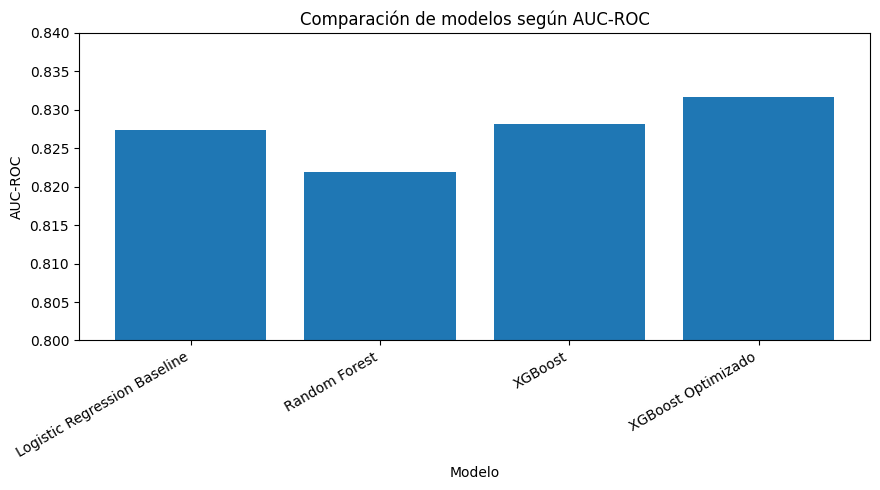

In [ ]:
plt.figure(figsize=(9, 5))

plt.bar(
    results_df["model"],
    results_df["roc_auc"]
)

plt.title("Comparación de modelos según AUC-ROC")
plt.xlabel("Modelo")
plt.ylabel("AUC-ROC")
plt.ylim(0.80, 0.84)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [ ]:
metrics_to_compare = ["accuracy", "precision", "recall", "f1_score", "roc_auc"]

comparison_table = (
    results_df
    .set_index("model")[metrics_to_compare]
    .sort_values(by="roc_auc", ascending=False)
)

comparison_table

,accuracy,precision,recall,f1_score,roc_auc
model,,,,,
XGBoost Optimizado,0.7747,0.9196,0.7895,0.8496,0.8316
XGBoost,0.7783,0.9171,0.7970,0.8528,0.8282
Logistic Regression Baseline,0.7808,0.9162,0.8013,0.8549,0.8274
Random Forest,0.7745,0.9154,0.7936,0.8502,0.8219


La comparación final muestra que el XGBoost optimizado obtiene el mejor AUC-ROC, con un valor de 0,8316. Le siguen el XGBoost inicial, con 0,8282, la regresión logística baseline, con 0,8274, y Random Forest, con 0,8219.

Sin embargo, las diferencias entre los tres mejores modelos son reducidas. La regresión logística obtiene la mayor accuracy, con 0,7808, y también el mayor F1-score para la clase positiva, con 0,8549. Esto confirma que el modelo baseline sigue siendo una alternativa muy competitiva, especialmente si se valora la simplicidad y la interpretabilidad.

Desde el punto de vista clínico, no obstante, la selección del modelo no debe basarse únicamente en accuracy. En este proyecto, la clase más relevante es la de pacientes que no alcanzan la supervivencia a cinco años. Por ello, se ha priorizado también el AUC-ROC y el recall de la clase minoritaria.

Bajo este criterio, el XGBoost optimizado se posiciona como el modelo más interesante, ya que alcanza la mayor capacidad discriminativa global y mejora ligeramente la detección de pacientes de peor pronóstico. No obstante, la mejora respecto al baseline es moderada, por lo que la regresión logística seguirá considerándose un modelo de referencia relevante en la fase de interpretabilidad.

Random Forest no mejora al baseline ni a XGBoost con la configuración utilizada, por lo que no parece ser el modelo más adecuado para este conjunto de datos en su configuración actual.

En conjunto, los resultados muestran que existe señal predictiva en las variables disponibles, aunque la complejidad adicional de los modelos no produce una mejora drástica. Por ello, las siguientes fases deberán centrarse no solo en el rendimiento, sino también en la interpretabilidad y en la utilidad clínica del modelo.

In [ ]:
from sklearn.utils import resample

def bootstrap_auc_ci(y_true, y_score, n_boot=1000, seed=42):
    rng = np.random.RandomState(seed)
    y_true = np.asarray(y_true)
    y_score = np.asarray(y_score)
    aucs = []
    for _ in range(n_boot):
        idx = rng.randint(0, len(y_true), len(y_true))
        if len(np.unique(y_true[idx])) < 2:
            continue
        aucs.append(roc_auc_score(y_true[idx], y_score[idx]))
    return np.percentile(aucs, [2.5, 97.5])

ci_log = bootstrap_auc_ci(y_test, y_proba_baseline)
ci_xgb = bootstrap_auc_ci(y_test, y_proba_best_xgb)

print(f"AUC Regresión logística: 0.8274  IC95% [{ci_log[0]:.4f}, {ci_log[1]:.4f}]")
print(f"AUC XGBoost optimizado:  0.8316  IC95% [{ci_xgb[0]:.4f}, {ci_xgb[1]:.4f}]")

AUC Regresión logística: 0.8274  IC95% [0.8251, 0.8297]
AUC XGBoost optimizado:  0.8316  IC95% [0.8294, 0.8339]


Para valorar si las diferencias en AUC-ROC son relevantes o atribuibles al azar, se estimaron intervalos de confianza del 95 % mediante bootstrap (1.000 remuestreos) sobre el conjunto de prueba.

La regresión logística baseline obtuvo un AUC de 0,8274 (IC95% 0,8251–0,8297), mientras que el XGBoost optimizado obtuvo un AUC de 0,8316 (IC95% 0,8294–0,8339). Los intervalos apenas se solapan, lo que sugiere que la ventaja del XGBoost es estadísticamente apreciable, favorecida por el gran tamaño del conjunto de prueba (199.384 observaciones).

No obstante, la magnitud de la diferencia es reducida, en torno a 0,004 puntos de AUC, por lo que su relevancia práctica es limitada. Debe tenerse en cuenta, además, que esta comparación se basa en intervalos estimados de forma independiente para cada modelo y no en una prueba pareada, por lo que constituye una aproximación orientativa y no una prueba formal de significación.

En conjunto, la regresión logística sigue siendo una alternativa competitiva cuando se prioriza la simplicidad y la interpretabilidad, mientras que el XGBoost optimizado resulta preferible si se prioriza la capacidad discriminativa global.

## 7.8 Ajuste del umbral de decisión

Hasta ahora, los modelos se han evaluado utilizando el umbral de decisión por defecto. En clasificación binaria, este umbral suele ser 0,5: si la probabilidad estimada de pertenecer a la clase positiva es igual o superior a 0,5, el modelo predice la clase `1`; en caso contrario, predice la clase `0`.

Sin embargo, en un problema médico este umbral no tiene por qué ser el más adecuado. En este trabajo, la clase `0` representa a los pacientes que no sobreviven cinco años, que es la clase de mayor interés clínico. Por tanto, puede ser conveniente ajustar el umbral para mejorar la detección de pacientes de peor pronóstico.

El objetivo de esta sección es analizar cómo cambian las métricas de la clase `No sobrevive 5 años` al modificar el umbral de decisión del modelo XGBoost optimizado.

### 7.8.1 Evaluación de distintos umbrales

El modelo XGBoost optimizado genera una probabilidad asociada a la clase positiva, es decir, a la clase `Sobrevive 5 años`.

Para obtener predicciones binarias, se aplica un umbral sobre dicha probabilidad:

- Si la probabilidad de supervivencia es mayor o igual al umbral, se predice `1`.
- Si la probabilidad de supervivencia es menor que el umbral, se predice `0`.

Reducir el umbral hace que más pacientes sean clasificados como supervivientes. Aumentarlo hace que el modelo sea más exigente para predecir supervivencia y, por tanto, clasifique más pacientes como no supervivientes.

Para seleccionar el umbral sin contaminar la evaluación final, el barrido de umbrales no se realiza sobre el conjunto de prueba, sino sobre el conjunto de entrenamiento mediante validación cruzada. Concretamente, se obtienen probabilidades *out-of-fold* (3 folds) sobre los datos de entrenamiento y se calculan las métricas de cada clase para cada umbral. De esta forma, el conjunto de prueba permanece intacto y no interviene en ningún momento en la elección del punto de corte.

In [ ]:
from sklearn.metrics import precision_recall_fscore_support
from sklearn.model_selection import cross_val_predict
from sklearn.base import clone

# Probabilidades out-of-fold sobre ENTRENAMIENTO.
# El umbral se selecciona sin usar en ningún momento el conjunto de test.
oof_proba_train = cross_val_predict(
    clone(best_xgb_model),
    X_train,
    y_train,
    cv=3,
    method="predict_proba",
    n_jobs=-1
)[:, 1]

threshold_results = []
thresholds = np.arange(0.30, 0.71, 0.02)

for threshold in thresholds:
    y_pred_threshold = (oof_proba_train >= threshold).astype(int)

    precision, recall, f1, support = precision_recall_fscore_support(
        y_train,
        y_pred_threshold,
        labels=[0, 1],
        zero_division=0
    )

    threshold_results.append({
        "threshold": round(threshold, 2),
        "precision_class_0": precision[0],
        "recall_class_0": recall[0],
        "f1_class_0": f1[0],
        "precision_class_1": precision[1],
        "recall_class_1": recall[1],
        "f1_class_1": f1[1],
        "accuracy": accuracy_score(y_train, y_pred_threshold)
    })

threshold_results = pd.DataFrame(threshold_results).round(4)
threshold_results

,threshold,precision_class_0,recall_class_0,f1_class_0,precision_class_1,recall_class_1,f1_class_1,accuracy
0,0.30,0.6203,0.5148,0.5626,0.8878,0.9241,0.9056,0.8447
1,0.32,0.6008,0.5368,0.5670,0.8913,0.9141,0.9026,0.8409
2,0.34,0.5819,0.5576,0.5695,0.8946,0.9036,0.8990,0.8364
3,0.36,0.5647,0.5765,0.5705,0.8975,0.8930,0.8953,0.8316
4,0.38,0.5484,0.5955,0.5710,0.9006,0.8820,0.8912,0.8264
5,0.40,0.5325,0.6150,0.5708,0.9037,0.8700,0.8865,0.8205
6,0.42,0.5160,0.6337,0.5688,0.9067,0.8569,0.8811,0.8136
7,0.44,0.4995,0.6526,0.5659,0.9097,0.8426,0.8749,0.8057
8,0.46,0.4833,0.6723,0.5623,0.9129,0.8270,0.8678,0.7970
9,0.48,0.4666,0.6917,0.5573,0.9160,0.8096,0.8595,0.7867


La tabla anterior, calculada sobre el conjunto de entrenamiento mediante validación cruzada, permite observar el compromiso entre precisión y recall al modificar el umbral de decisión. En particular, se presta atención al recall y al F1-score de la clase `0`, ya que esta clase representa a los pacientes que no alcanzan la supervivencia a cinco años.

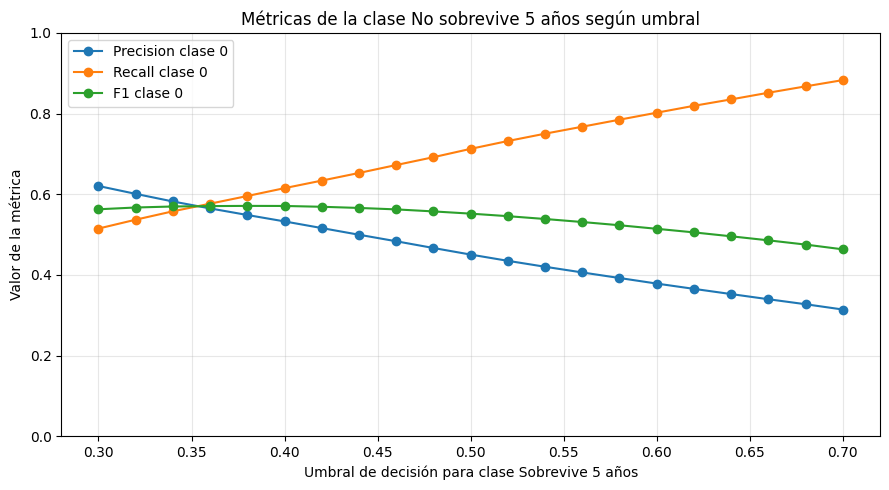

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    threshold_results["threshold"],
    threshold_results["precision_class_0"],
    marker="o",
    label="Precision clase 0"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["recall_class_0"],
    marker="o",
    label="Recall clase 0"
)

plt.plot(
    threshold_results["threshold"],
    threshold_results["f1_class_0"],
    marker="o",
    label="F1 clase 0"
)

plt.title("Métricas de la clase No sobrevive 5 años según umbral")
plt.xlabel("Umbral de decisión para clase Sobrevive 5 años")
plt.ylabel("Valor de la métrica")
plt.ylim(0, 1)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 7.8.2 Selección de un umbral alternativo

Una estrategia posible es seleccionar el umbral que maximiza el F1-score de la clase `No sobrevive 5 años`. Esta métrica equilibra la capacidad de detectar pacientes de alto riesgo con la precisión de dichas predicciones.

La selección se realiza utilizando las métricas obtenidas por validación cruzada sobre el conjunto de entrenamiento, de modo que el umbral queda fijado antes de evaluar el modelo sobre el conjunto de prueba.

Este criterio no pretende sustituir a la valoración clínica, pero permite adaptar la decisión del modelo al objetivo principal del proyecto: identificar adecuadamente a los pacientes con peor pronóstico.

In [ ]:
best_threshold_row = threshold_results.loc[
    threshold_results["f1_class_0"].idxmax()
]

best_threshold = best_threshold_row["threshold"]

best_threshold_row

,4
threshold,0.3800
precision_class_0,0.5484
recall_class_0,0.5955
f1_class_0,0.5710
precision_class_1,0.9006
recall_class_1,0.8820
f1_class_1,0.8912
accuracy,0.8264


El umbral que maximiza el F1-score de la clase `No sobrevive 5 años` sobre el conjunto de entrenamiento, evaluado mediante validación cruzada, es 0,38. Con este umbral, las métricas de selección para la clase 0 son una precisión de 0,5484, un recall de 0,5955 y un F1-score de 0,5710.

Al aplicar este mismo umbral, ya fijado, sobre el conjunto de prueba, se obtienen valores prácticamente idénticos para la clase 0: una precisión de 0,5457, un recall de 0,5985 y un F1-score de 0,5709. La coincidencia entre las métricas de entrenamiento y de prueba indica que la elección del umbral no produce sobreajuste.

Este resultado muestra que reducir el umbral de decisión respecto al valor por defecto mejora la precisión de las predicciones de no supervivencia y aumenta el F1-score de la clase clínicamente más crítica. Sin embargo, esta mejora se consigue a costa de reducir el recall de dicha clase, es decir, el modelo identifica menos pacientes que realmente no sobreviven a cinco años que con el umbral por defecto.

In [ ]:
y_pred_best_xgb_threshold = (y_proba_best_xgb >= best_threshold).astype(int)

print(f"Umbral seleccionado: {best_threshold}")

print(classification_report(
    y_test,
    y_pred_best_xgb_threshold,
    target_names=["No sobrevive 5 años", "Sobrevive 5 años"]
))

cm_best_xgb_threshold = confusion_matrix(y_test, y_pred_best_xgb_threshold)

cm_best_xgb_threshold

Umbral seleccionado: 0.38
                     precision    recall  f1-score   support

No sobrevive 5 años       0.55      0.60      0.57     38684
   Sobrevive 5 años       0.90      0.88      0.89    160700

           accuracy                           0.83    199384
          macro avg       0.72      0.74      0.73    199384
       weighted avg       0.83      0.83      0.83    199384



array([[ 23154,  15530],
       [ 19273, 141427]])

In [ ]:
tn_t, fp_t, fn_t, tp_t = cm_best_xgb_threshold.ravel()

threshold_confusion_summary = pd.DataFrame({
    "metric": [
        "Verdaderos negativos",
        "Falsos positivos",
        "Falsos negativos",
        "Verdaderos positivos"
    ],
    "count": [tn_t, fp_t, fn_t, tp_t]
})

threshold_confusion_summary

,metric,count
0,Verdaderos negativos,23154
1,Falsos positivos,15530
2,Falsos negativos,19273
3,Verdaderos positivos,141427


Con el umbral ajustado de 0,38, el modelo obtiene una accuracy de 0,8254, superior a la obtenida con el umbral por defecto. También mejora el F1-score de la clase `No sobrevive 5 años`, que pasa aproximadamente de 0,55 a 0,57.

La matriz de confusión muestra 23.154 verdaderos negativos y 15.530 falsos positivos para la clase de no supervivencia. En comparación con el umbral por defecto, el modelo detecta menos pacientes que realmente no sobreviven a cinco años, pero mejora la precisión de las predicciones negativas.

Por otro lado, el número de falsos negativos desde la perspectiva de la clase positiva disminuye notablemente, y el número de verdaderos positivos aumenta hasta 141.427. Esto explica la mejora de la accuracy global y del rendimiento sobre la clase mayoritaria.

Este resultado evidencia el compromiso existente entre sensibilidad hacia los pacientes de peor pronóstico y precisión global del sistema. El umbral ajustado mejora el equilibrio general y el F1-score de la clase 0, pero reduce la capacidad del modelo para capturar todos los pacientes que no alcanzan la supervivencia a cinco años.

### 7.8.3 Comparación entre umbral por defecto y umbral ajustado

Finalmente, se comparan las métricas principales del XGBoost optimizado con umbral por defecto y con el umbral ajustado.

In [ ]:
precision_t, recall_t, f1_t, _ = precision_recall_fscore_support(
    y_test,
    y_pred_best_xgb_threshold,
    labels=[0, 1],
    zero_division=0
)

threshold_comparison = pd.DataFrame({
    "model": [
        "XGBoost Optimizado - umbral 0.50",
        f"XGBoost Optimizado - umbral {best_threshold:.2f}"
    ],
    "precision_class_0": [0.45, precision_t[0]],
    "recall_class_0": [0.71, recall_t[0]],
    "f1_class_0": [0.55, f1_t[0]],
    "accuracy": [
        accuracy_score(y_test, y_pred_best_xgb),
        accuracy_score(y_test, y_pred_best_xgb_threshold)
    ],
    "roc_auc": [
        roc_auc_score(y_test, y_proba_best_xgb),
        roc_auc_score(y_test, y_proba_best_xgb)
    ]
}).round(4)

threshold_comparison

,model,precision_class_0,recall_class_0,f1_class_0,accuracy,roc_auc
0,XGBoost Optimizado - umbral 0.50,0.4500,0.7100,0.5500,0.7747,0.8316
1,XGBoost Optimizado - umbral 0.38,0.5457,0.5985,0.5709,0.8254,0.8316


La comparación entre umbrales muestra que el ajuste del punto de corte modifica de forma relevante el comportamiento del modelo.

Con el umbral por defecto de 0,50, el XGBoost optimizado prioriza la detección de pacientes que no sobreviven cinco años, alcanzando un recall de la clase 0 de aproximadamente 0,71. Sin embargo, esta estrategia tiene una precisión limitada para dicha clase, de 0,45, y una accuracy global de 0,7747.

Con el umbral ajustado de 0,38, la precisión de la clase 0 aumenta hasta 0,5457 y el F1-score mejora hasta 0,5709. Además, la accuracy global sube hasta 0,8254. No obstante, el recall de la clase 0 disminuye hasta 0,5985, lo que implica que el modelo deja de identificar una mayor proporción de pacientes que realmente no sobreviven a cinco años.

El AUC-ROC permanece constante en 0,8316, ya que esta métrica depende de las probabilidades estimadas por el modelo y no del umbral concreto utilizado para convertirlas en clases.

Desde una perspectiva clínica, la elección del umbral depende del objetivo prioritario. Si se busca maximizar la detección de pacientes de alto riesgo, el umbral por defecto resulta más sensible. Si se busca un equilibrio más estable entre precisión y recall, reduciendo falsos positivos y mejorando el F1-score de la clase 0, el umbral ajustado de 0,38 resulta más adecuado.

En este trabajo, ambos escenarios son informativos. El modelo con umbral por defecto se mantiene como referencia orientada a sensibilidad, mientras que el umbral ajustado se considera una alternativa más equilibrada para la toma de decisiones basada en riesgo.

## 7.9 Conclusión de la fase de modelado

La fase de modelado muestra que los modelos entrenados alcanzan una capacidad predictiva razonable para la predicción de supervivencia a cinco años en cáncer de mama.

La regresión logística baseline obtiene un rendimiento competitivo, lo que demuestra que una parte importante de la señal predictiva puede capturarse mediante un modelo lineal e interpretable. Los modelos basados en árboles no mejoran de forma drástica el rendimiento, aunque el XGBoost optimizado alcanza el mejor AUC-ROC, con un valor de 0,8316.

La incorporación del ajuste de umbral permite adaptar el comportamiento del modelo al contexto clínico. El umbral por defecto favorece una mayor detección de pacientes que no sobreviven cinco años, mientras que el umbral ajustado de 0,38 mejora el equilibrio entre precisión y recall para la clase de mayor interés clínico.

En conjunto, los resultados justifican continuar con una fase de interpretabilidad centrada principalmente en dos modelos: la regresión logística, por su simplicidad y transparencia, y el XGBoost optimizado, por ser el modelo con mayor capacidad discriminativa global.

# 8. Interpretabilidad del modelo

En problemas aplicados al ámbito sanitario, la evaluación de un modelo predictivo no debe limitarse al análisis de métricas de rendimiento. También es necesario comprender qué variables influyen en las predicciones y si los patrones aprendidos son coherentes desde el punto de vista clínico.

La interpretabilidad resulta especialmente importante en este trabajo por tres motivos:

- El problema se centra en la predicción de supervivencia a cinco años en cáncer de mama, un desenlace clínicamente relevante.
- El modelo podría utilizarse como herramienta de apoyo a la estratificación de riesgo, por lo que sus predicciones deben ser justificables.
- Algunas variables del dataset representan códigos clínicos, valores especiales o tratamientos, cuya interpretación requiere cautela.

En esta sección se analizan dos modelos:

- La regresión logística baseline, por su simplicidad e interpretabilidad directa mediante coeficientes.
- El XGBoost optimizado, por ser el modelo con mayor AUC-ROC y mejor capacidad discriminativa global.

## 8.1 Interpretabilidad de la regresión logística

La regresión logística permite analizar la contribución de cada variable transformada mediante sus coeficientes.

En este modelo, la clase positiva corresponde a `survived_5_years = 1`, es decir, pacientes que sobreviven al menos cinco años. Por tanto:

- Coeficientes positivos se asocian con mayor probabilidad de supervivencia a cinco años.
- Coeficientes negativos se asocian con menor probabilidad de supervivencia a cinco años.

Dado que las variables categóricas han sido codificadas mediante One-Hot Encoding, cada coeficiente corresponde a una categoría concreta de una variable original.

In [ ]:
logistic_preprocessor = baseline_model.named_steps["preprocessor"]
logistic_classifier = baseline_model.named_steps["classifier"]

logistic_feature_names = logistic_preprocessor.get_feature_names_out()
logistic_coefficients = logistic_classifier.coef_[0]

coef_df = pd.DataFrame({
    "feature": logistic_feature_names,
    "coefficient": logistic_coefficients
})

coef_df["abs_coefficient"] = coef_df["coefficient"].abs()

coef_df = coef_df.sort_values(
    by="abs_coefficient",
    ascending=False
)

coef_df.head(20)

,feature,coefficient,abs_coefficient
18,categorical__age_group_90+ years,-2.329348,2.329348
17,categorical__age_group_85-89 years,-1.640970,1.640970
424,categorical__summary_stage_Distant,-1.575141,1.575141
194,categorical__histologic_type_9120,-1.414805,1.414805
428,categorical__surgery_primary_site_0,-1.393258,1.393258
475,categorical__surgery_primary_site_99,-1.338811,1.338811
16,categorical__age_group_80-84 years,-1.080664,1.080664
24,categorical__race_Unknown,1.063737,1.063737
139,categorical__histologic_type_8530,-0.988365,0.988365
185,categorical__histologic_type_8980,-0.985375,0.985375


La tabla anterior muestra las variables transformadas con mayor peso absoluto en el modelo de regresión logística. Los coeficientes con mayor magnitud son los que más influyen en la predicción del modelo, aunque su interpretación debe realizarse teniendo en cuenta que las variables categóricas han sido codificadas mediante One-Hot Encoding.

A continuación se analizan por separado los coeficientes positivos y negativos más relevantes.

### 8.1.1 Variables asociadas a mayor supervivencia estimada

Se identifican las variables con coeficientes positivos más altos. Estas categorías están asociadas, dentro del modelo, con una mayor probabilidad estimada de supervivencia a cinco años.

In [ ]:
top_positive_coef = (
    coef_df
    .sort_values(by="coefficient", ascending=False)
    .head(20)
)

top_positive_coef

,feature,coefficient,abs_coefficient
24,categorical__race_Unknown,1.063737,1.063737
425,categorical__summary_stage_Localized,0.866991,0.866991
209,categorical__tumor_size_001,0.861719,0.861719
85,categorical__histologic_type_8211,0.800030,0.800030
9,categorical__age_group_45-49 years,0.799413,0.799413
83,categorical__histologic_type_8201,0.768329,0.768329
212,categorical__tumor_size_004,0.744450,0.744450
8,categorical__age_group_40-44 years,0.738774,0.738774
471,categorical__surgery_primary_site_75,0.738585,0.738585
208,categorical__tumor_size_000,0.727796,0.727796


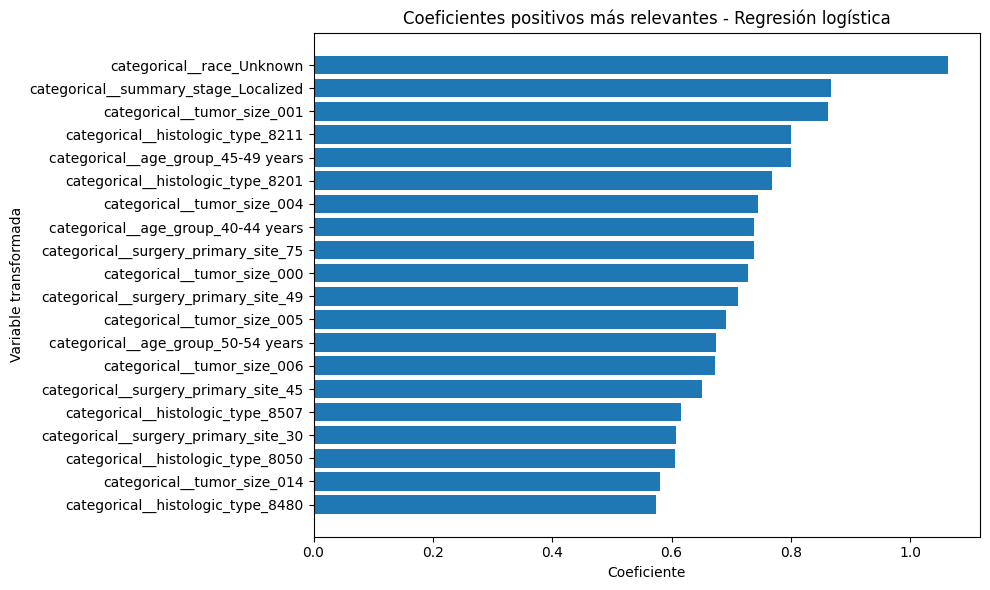

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_positive_coef["feature"][::-1],
    top_positive_coef["coefficient"][::-1]
)

plt.title("Coeficientes positivos más relevantes - Regresión logística")
plt.xlabel("Coeficiente")
plt.ylabel("Variable transformada")
plt.tight_layout()
plt.show()

Los coeficientes positivos de la regresión logística representan categorías asociadas a una mayor probabilidad estimada de supervivencia a cinco años.

Entre las variables con mayor coeficiente positivo aparece `summary_stage_Localized`, lo cual es clínicamente coherente: los pacientes con enfermedad localizada presentan mejor pronóstico que aquellos con enfermedad regional o distante. También aparecen grupos de edad intermedios, como `45-49 years`, `40-44 years` y `50-54 years`, que en el análisis exploratorio ya mostraban tasas elevadas de supervivencia.

También destacan algunos valores de `tumor_size` bajos, como `001`, `004`, `005` o `006`, asociados a mayor supervivencia estimada. Este patrón es clínicamente plausible, ya que tumores de menor tamaño suelen relacionarse con mejor pronóstico. No obstante, debe recordarse que la variable `tumor_size` presenta una proporción muy elevada de valores `Blank(s)`, por lo que su interpretación debe hacerse con cautela.

Aparecen además ciertos códigos histológicos, como `8211`, `8201`, `8507`, `8050` o `8480`, y códigos quirúrgicos como `75`, `49`, `45` o `30`, asociados positivamente con la supervivencia. Estas asociaciones pueden reflejar perfiles clínicos más favorables, procedimientos concretos o características de los pacientes que reciben determinados tratamientos.

La categoría `race_Unknown` aparece como el coeficiente positivo más alto. Este resultado debe interpretarse con especial prudencia, ya que no representa una categoría clínica o biológica clara, sino ausencia de información registrada. Su peso positivo puede deberse a características particulares de los registros con raza desconocida y no debe interpretarse como un efecto real de dicha categoría.

### 8.1.2 Variables asociadas a menor supervivencia estimada

Se identifican las variables con coeficientes negativos más bajos. Estas categorías están asociadas, dentro del modelo, con una menor probabilidad estimada de supervivencia a cinco años.

In [ ]:
top_negative_coef = (
    coef_df
    .sort_values(by="coefficient", ascending=True)
    .head(20)
)

top_negative_coef

,feature,coefficient,abs_coefficient
18,categorical__age_group_90+ years,-2.329348,2.329348
17,categorical__age_group_85-89 years,-1.640970,1.640970
424,categorical__summary_stage_Distant,-1.575141,1.575141
194,categorical__histologic_type_9120,-1.414805,1.414805
428,categorical__surgery_primary_site_0,-1.393258,1.393258
475,categorical__surgery_primary_site_99,-1.338811,1.338811
16,categorical__age_group_80-84 years,-1.080664,1.080664
139,categorical__histologic_type_8530,-0.988365,0.988365
185,categorical__histologic_type_8980,-0.985375,0.985375
152,categorical__histologic_type_8575,-0.751782,0.751782


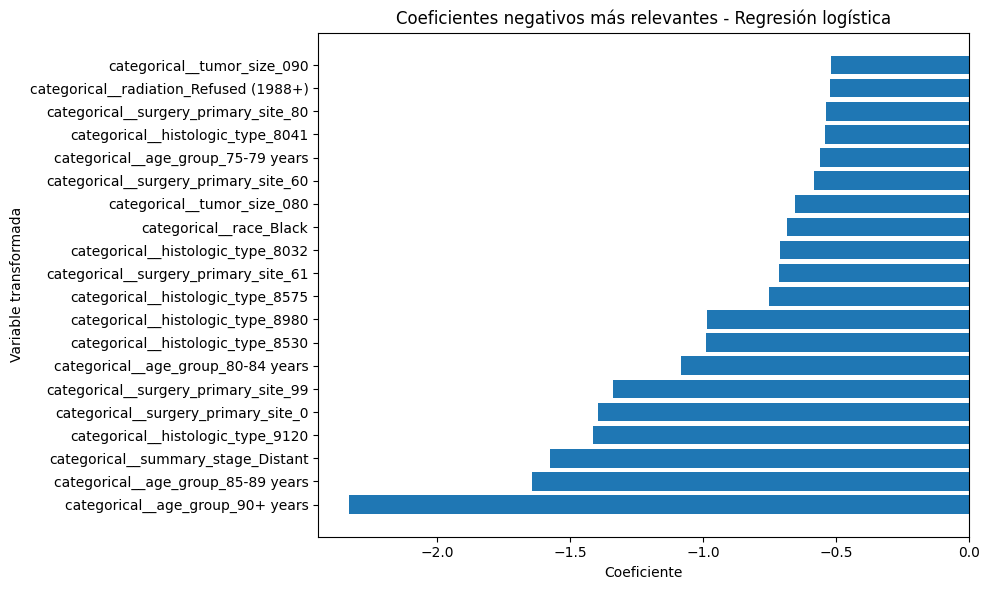

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_negative_coef["feature"],
    top_negative_coef["coefficient"]
)

plt.title("Coeficientes negativos más relevantes - Regresión logística")
plt.xlabel("Coeficiente")
plt.ylabel("Variable transformada")
plt.tight_layout()
plt.show()

Los coeficientes negativos representan categorías asociadas a una menor probabilidad estimada de supervivencia a cinco años.

Los coeficientes negativos más fuertes corresponden a los grupos de edad más avanzada: `90+ years`, `85-89 years` y `80-84 years`. Este patrón es coherente con el análisis exploratorio, donde se observó una disminución clara de la supervivencia a cinco años en edades avanzadas. La edad elevada puede estar asociada a mayor comorbilidad, menor tolerancia al tratamiento, mayor mortalidad competitiva y diferencias en el manejo clínico.

También aparece `summary_stage_Distant` como una de las variables con mayor peso negativo. Este resultado es clínicamente esperable, ya que la enfermedad distante representa un estadio avanzado y se asocia con un pronóstico considerablemente peor.

Entre las variables negativas también destacan códigos quirúrgicos como `surgery_primary_site_0` y `surgery_primary_site_99`. Aunque su interpretación clínica exacta requiere consultar la codificación específica de SEER, su asociación negativa puede estar relacionada con ausencia de cirugía, cirugía no realizada, no recomendada o información quirúrgica desconocida. Esto es coherente con perfiles clínicos potencialmente más graves o con peor estado general.

Asimismo, aparecen códigos histológicos como `9120`, `8530`, `8980`, `8575`, `8032` o `8041`, asociados a menor supervivencia estimada. Estos códigos podrían corresponder a subtipos tumorales con peor pronóstico o a categorías menos frecuentes con perfiles clínicos específicos.

La categoría `race_Black` también presenta un coeficiente negativo relevante. Esta asociación debe interpretarse con cautela, ya que no implica una relación causal directa. Puede reflejar diferencias en estadio al diagnóstico, acceso a tratamiento, comorbilidades, factores socioeconómicos o desigualdades estructurales no observadas directamente en el dataset.

Finalmente, aparecen categorías como `radiation_Refused (1988+)` y tamaños tumorales elevados como `080` y `090`, lo cual resulta coherente con un peor pronóstico o con situaciones clínicas más complejas.

### 8.1.3 Síntesis de la interpretabilidad de la regresión logística

La interpretación de los coeficientes de la regresión logística muestra patrones coherentes con el conocimiento clínico del cáncer de mama. Las variables asociadas a mejor pronóstico incluyen enfermedad localizada, edades intermedias y tamaños tumorales pequeños. Por el contrario, las variables asociadas a peor pronóstico incluyen edad avanzada, enfermedad distante, determinados códigos histológicos, códigos quirúrgicos potencialmente relacionados con ausencia o desconocimiento de cirugía y rechazo de radioterapia.

Estos resultados refuerzan la validez del modelo baseline, ya que las asociaciones aprendidas son plausibles desde el punto de vista clínico. No obstante, algunas categorías requieren interpretación cautelosa, especialmente aquellas que representan valores desconocidos, códigos administrativos o grupos con baja frecuencia.

La regresión logística ofrece, por tanto, una ventaja importante en términos de transparencia: permite identificar de forma directa qué categorías aumentan o reducen la probabilidad estimada de supervivencia a cinco años. Esta característica resulta especialmente valiosa en un contexto sanitario, donde la interpretabilidad del modelo es una condición fundamental para su posible uso como herramienta de apoyo.

## 8.2 Importancia de variables en XGBoost optimizado

Una vez analizada la regresión logística, se estudia la importancia de variables del modelo XGBoost optimizado.

A diferencia de la regresión logística, XGBoost no proporciona coeficientes directamente interpretables. Sin embargo, permite obtener medidas de importancia asociadas a las variables utilizadas por los árboles del modelo.

Estas medidas permiten identificar qué variables transformadas han contribuido en mayor medida a las decisiones del modelo.

In [ ]:
xgb_preprocessor = best_xgb_model.named_steps["preprocessor"]
xgb_classifier = best_xgb_model.named_steps["classifier"]

xgb_feature_names = xgb_preprocessor.get_feature_names_out()

xgb_importances = xgb_classifier.feature_importances_

xgb_importance_df = pd.DataFrame({
    "feature": xgb_feature_names,
    "importance": xgb_importances
})

xgb_importance_df = (
    xgb_importance_df
    .sort_values(by="importance", ascending=False)
    .reset_index(drop=True)
)

xgb_importance_df.head(30)

,feature,importance
0,categorical__surgery_primary_site_0,0.229358
1,categorical__summary_stage_Distant,0.091303
2,categorical__age_group_90+ years,0.058364
3,categorical__age_group_85-89 years,0.056088
4,categorical__age_group_80-84 years,0.043235
5,categorical__marital_status_Widowed,0.032970
6,categorical__summary_stage_Localized,0.031702
7,categorical__age_group_75-79 years,0.025036
8,categorical__surgery_primary_site_51,0.020201
9,categorical__histologic_type_8530,0.010406


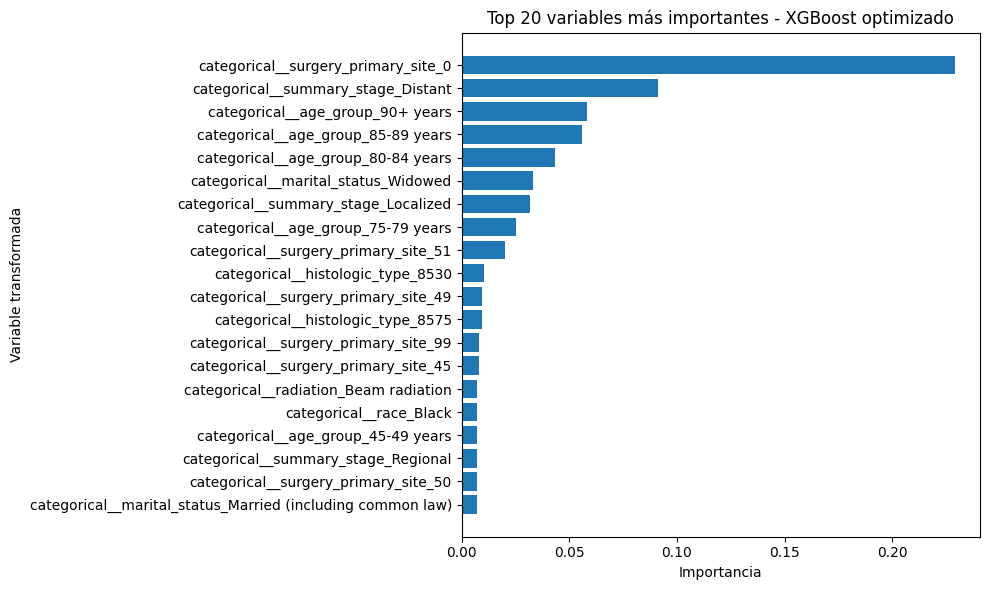

In [ ]:
top_xgb_importance = xgb_importance_df.head(20)

plt.figure(figsize=(10, 6))

plt.barh(
    top_xgb_importance["feature"][::-1],
    top_xgb_importance["importance"][::-1]
)

plt.title("Top 20 variables más importantes - XGBoost optimizado")
plt.xlabel("Importancia")
plt.ylabel("Variable transformada")
plt.tight_layout()
plt.show()

La importancia de variables del XGBoost optimizado muestra que el modelo concentra gran parte de su capacidad predictiva en un conjunto reducido de variables transformadas.

La variable más importante es `surgery_primary_site_0`, con una importancia de 0,2294. Este resultado indica que esta categoría quirúrgica tiene un peso muy elevado en las decisiones del modelo. Aunque la interpretación clínica exacta requiere consultar la codificación específica de SEER, durante el análisis exploratorio ya se observó que este código se asociaba con una tasa de supervivencia considerablemente inferior. Esto sugiere que puede estar relacionado con ausencia de cirugía, cirugía no realizada o situaciones clínicas de peor pronóstico.

La segunda variable más importante es `summary_stage_Distant`, con una importancia de 0,0913. Este resultado es clínicamente coherente, ya que la enfermedad distante representa un estadio avanzado y se asocia con una supervivencia a cinco años mucho menor.

También aparecen entre las variables más relevantes varios grupos de edad avanzada: `90+ years`, `85-89 years`, `80-84 years` y `75-79 years`. Esto confirma que la edad es uno de los factores más influyentes en la predicción del modelo, especialmente en los grupos de mayor edad, donde la supervivencia observada era notablemente inferior.

La variable `marital_status_Widowed` también aparece con una importancia elevada. Este resultado debe interpretarse con cautela, ya que puede estar actuando como variable indirecta de edad avanzada, apoyo social, comorbilidad u otros factores no observados.

Además, aparecen variables de estadificación como `summary_stage_Localized` y `summary_stage_Regional`, lo que refuerza la importancia de la extensión de la enfermedad en la predicción de supervivencia. También se observan códigos quirúrgicos, códigos histológicos, variables de radioterapia y categorías raciales entre las variables relevantes.

En conjunto, la importancia de variables de XGBoost es coherente con los patrones observados en el análisis exploratorio y con la interpretación de la regresión logística. Las variables más relevantes están relacionadas principalmente con cirugía, estadio, edad, estado civil, histología y tratamiento.

## 8.3 Comparación de interpretabilidad entre modelos

La regresión logística y XGBoost ofrecen aproximaciones diferentes a la interpretabilidad.

La regresión logística proporciona coeficientes directamente interpretables, que indican la dirección de la asociación entre cada categoría y la probabilidad estimada de supervivencia a cinco años. Esto permite identificar variables asociadas a mejor o peor pronóstico.

XGBoost, en cambio, proporciona medidas de importancia que indican qué variables han sido más relevantes en las particiones de los árboles, pero no muestran directamente si una categoría aumenta o reduce la probabilidad de supervivencia. Por tanto, su interpretación debe complementarse con el análisis exploratorio y, si se desea mayor detalle, con técnicas como SHAP.

A pesar de estas diferencias, ambos modelos coinciden en destacar variables clínicamente plausibles:

- Edad avanzada.
- Estadio distante.
- Estadio localizado.
- Códigos quirúrgicos concretos.
- Algunos tipos histológicos.
- Variables de tratamiento como radioterapia.
- Categorías demográficas como raza o estado civil.

Esta coincidencia entre modelos refuerza la consistencia de los resultados.

In [ ]:
top_logistic_features = set(
    coef_df
    .head(30)["feature"]
)

top_xgb_features = set(
    xgb_importance_df
    .head(30)["feature"]
)

common_top_features = sorted(
    top_logistic_features.intersection(top_xgb_features)
)

common_top_features

['categorical__age_group_40-44 years',
 'categorical__age_group_45-49 years',
 'categorical__age_group_50-54 years',
 'categorical__age_group_80-84 years',
 'categorical__age_group_85-89 years',
 'categorical__age_group_90+ years',
 'categorical__histologic_type_8530',
 'categorical__histologic_type_8575',
 'categorical__histologic_type_9120',
 'categorical__race_Black',
 'categorical__race_Unknown',
 'categorical__summary_stage_Distant',
 'categorical__summary_stage_Localized',
 'categorical__surgery_primary_site_0',
 'categorical__surgery_primary_site_45',
 'categorical__surgery_primary_site_49',
 'categorical__surgery_primary_site_99']

La comparación entre las variables más relevantes de la regresión logística y XGBoost muestra una coincidencia notable en varios grupos de variables.

Ambos modelos identifican como relevantes varios grupos de edad, especialmente edades avanzadas como `80-84 years`, `85-89 years` y `90+ years`, asociadas a peor pronóstico, y edades intermedias como `40-44 years`, `45-49 years` y `50-54 years`, asociadas a mejores tasas de supervivencia en el análisis exploratorio.

También coinciden en destacar variables de estadificación, especialmente `summary_stage_Distant` y `summary_stage_Localized`. Esta coincidencia es clínicamente coherente, ya que la extensión de la enfermedad es uno de los factores pronósticos más importantes en cáncer de mama.

Además, aparecen en ambos modelos varios códigos quirúrgicos, como `surgery_primary_site_0`, `45`, `49` y `99`. En particular, `surgery_primary_site_0` y `surgery_primary_site_99` se asocian a peor pronóstico en la regresión logística y tienen alta importancia en XGBoost. Esto sugiere que la información quirúrgica contiene señal predictiva relevante, aunque su interpretación clínica requiere revisar la codificación específica de SEER.

Ambos modelos también coinciden en algunos tipos histológicos, como `8530`, `8575` y `9120`, así como en categorías raciales como `race_Black` y `race_Unknown`. Estas asociaciones deben interpretarse con cautela, especialmente en el caso de variables demográficas o categorías desconocidas, ya que pueden reflejar factores no observados, diferencias de registro o desigualdades estructurales.

En conjunto, la coincidencia entre ambos modelos refuerza la consistencia de los resultados. Las variables identificadas como relevantes pertenecen a dimensiones clínicamente plausibles: edad, estadio, cirugía, histología y características demográficas.

## 8.4 Conclusiones de interpretabilidad

El análisis de interpretabilidad muestra que los modelos no funcionan como una caja negra completamente opaca, sino que sus predicciones se apoyan en variables coherentes con el conocimiento clínico del cáncer de mama.

La regresión logística permite observar directamente la dirección de las asociaciones. Sus coeficientes indican que la supervivencia estimada aumenta en pacientes con enfermedad localizada, edades intermedias y tamaños tumorales pequeños, mientras que disminuye en pacientes de edad avanzada, enfermedad distante, determinados tipos histológicos y categorías quirúrgicas asociadas a peor pronóstico.

El XGBoost optimizado, aunque menos interpretable de forma directa, confirma la importancia de variables similares. Sus principales variables de importancia se relacionan con cirugía, estadio, edad, estado civil, histología, radioterapia y raza.

La coincidencia entre ambos modelos aporta solidez al análisis, ya que las variables relevantes no dependen exclusivamente de un único algoritmo. Además, muchas de las asociaciones encontradas son coherentes con los resultados del análisis exploratorio.

No obstante, la interpretación debe realizarse con prudencia. Algunas variables representan códigos administrativos, valores desconocidos o categorías de baja frecuencia. Además, las variables de tratamiento proceden de un registro observacional, por lo que su importancia predictiva no debe interpretarse como un efecto causal.

En conjunto, la interpretabilidad refuerza la validez del enfoque predictivo y permite identificar los principales factores asociados a la supervivencia a cinco años en el conjunto de datos analizado.

# 9. Análisis de errores

Una vez entrenados, comparados e interpretados los modelos, se realiza un análisis de errores sobre el modelo seleccionado.

El objetivo de esta sección es estudiar en qué tipo de casos falla el modelo y si los errores se concentran en determinados perfiles clínicos o demográficos.

Este análisis es especialmente relevante en un contexto médico, ya que no todos los errores tienen la misma implicación. En este trabajo se distinguen dos tipos principales de error:

- Pacientes que no sobreviven cinco años pero son clasificados como supervivientes.
- Pacientes que sobreviven cinco años pero son clasificados como no supervivientes.

El análisis se realiza utilizando el XGBoost optimizado con umbral ajustado de 0,38, ya que este umbral ofreció un mejor equilibrio entre precisión y recall para la clase `No sobrevive 5 años`.

## 9.1 Construcción del dataset de errores

Se construye un dataframe auxiliar que contiene las variables originales del conjunto de prueba, la etiqueta real, la predicción del modelo y la probabilidad estimada de supervivencia a cinco años.

Este dataframe permitirá analizar los errores de forma interpretable, utilizando las variables originales antes del preprocesamiento.

In [ ]:
error_analysis_df = X_test.copy()

error_analysis_df["y_true"] = y_test.values
error_analysis_df["y_pred"] = y_pred_best_xgb_threshold
error_analysis_df["proba_survive_5y"] = y_proba_best_xgb

error_analysis_df["prediction_result"] = np.select(
    [
        (error_analysis_df["y_true"] == 0) & (error_analysis_df["y_pred"] == 0),
        (error_analysis_df["y_true"] == 0) & (error_analysis_df["y_pred"] == 1),
        (error_analysis_df["y_true"] == 1) & (error_analysis_df["y_pred"] == 0),
        (error_analysis_df["y_true"] == 1) & (error_analysis_df["y_pred"] == 1)
    ],
    [
        "True Negative",
        "False Positive",
        "False Negative",
        "True Positive"
    ],
    default="Unknown"
)

error_analysis_df.head()

,age_group,sex,race,year_diagnosis,marital_status,primary_site,histologic_type,tumor_size,summary_stage,surgery_primary_site,radiation,chemotherapy,y_true,y_pred,proba_survive_5y,prediction_result
623359,60-64 years,Female,White,2002,Married (including common law),504,8500,Blank(s),Distant,41,Beam radiation,No/Unknown,1,0,0.148894,False Negative
739315,65-69 years,Female,White,2007,Widowed,504,8500,Blank(s),Localized,0,None/Unknown,Yes,0,0,0.178652,True Negative
757357,65-69 years,Female,White,2009,Widowed,508,8500,Blank(s),Regional,22,Beam radiation,No/Unknown,1,1,0.589586,True Positive
499877,80-84 years,Female,White,2000,Widowed,501,8522,Blank(s),Regional,51,None/Unknown,Yes,1,0,0.200839,False Negative
46757,50-54 years,Female,White,2013,Single (never married),508,8520,Blank(s),Regional,20,Beam radiation,No/Unknown,1,1,0.778333,True Positive


In [ ]:
error_counts = (
    error_analysis_df["prediction_result"]
    .value_counts()
    .rename_axis("prediction_result")
    .reset_index(name="count")
)

error_counts["percentage"] = (
    error_counts["count"] / len(error_analysis_df) * 100
).round(2)

error_counts

,prediction_result,count,percentage
0,True Positive,141427,70.93
1,True Negative,23154,11.61
2,False Negative,19273,9.67
3,False Positive,15530,7.79


La distribución de aciertos y errores muestra que el modelo clasifica correctamente como supervivientes a 141.427 pacientes, equivalentes al 70,93 % del conjunto de prueba. También identifica correctamente como no supervivientes a 23.154 pacientes, que representan el 11,61 %.

En cuanto a los errores, se observan 19.273 falsos negativos, equivalentes al 9,67 %, y 15.530 falsos positivos, equivalentes al 7,79 %. En este análisis, los falsos positivos corresponden a pacientes que realmente no sobreviven cinco años pero que el modelo clasifica como supervivientes. Estos errores son especialmente relevantes desde el punto de vista clínico, ya que implican no identificar adecuadamente a pacientes de peor pronóstico.

Los falsos negativos, por su parte, corresponden a pacientes que sí sobreviven cinco años pero que el modelo clasifica como no supervivientes. Aunque también son importantes, su implicación clínica es diferente, ya que representan una sobreestimación del riesgo.

El análisis posterior se centrará en comparar los perfiles de falsos positivos y falsos negativos con los casos correctamente clasificados, prestando especial atención a variables como edad, estadio, tratamiento y probabilidad estimada de supervivencia.

## 9.2 Análisis de probabilidades estimadas

Se analiza la distribución de las probabilidades estimadas de supervivencia a cinco años según el tipo de acierto o error.

Este análisis permite comprobar si los errores del modelo se producen principalmente en casos cercanos al umbral de decisión o si existen errores con probabilidades extremas, que serían más preocupantes desde el punto de vista predictivo.

In [ ]:
probability_summary = (
    error_analysis_df
    .groupby("prediction_result")["proba_survive_5y"]
    .describe()
    .round(4)
)

probability_summary

,count,mean,std,min,25%,50%,75%,max
prediction_result,,,,,,,,
False Negative,19273.0,0.2419,0.0976,0.0045,0.1721,0.2600,0.3249,0.3800
False Positive,15530.0,0.6077,0.1435,0.3800,0.4851,0.5940,0.7205,0.9741
True Negative,23154.0,0.1518,0.1082,0.0033,0.0557,0.1229,0.2395,0.3800
True Positive,141427.0,0.7242,0.1485,0.3800,0.6167,0.7491,0.8465,0.9900


<Figure size 900x500 with 0 Axes>

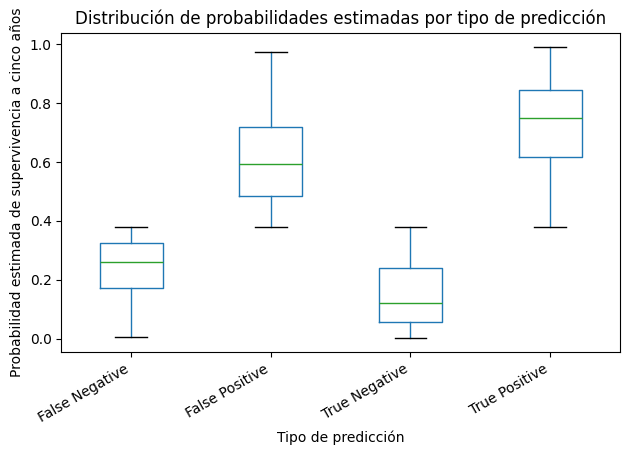

In [ ]:
plt.figure(figsize=(9, 5))

error_analysis_df.boxplot(
    column="proba_survive_5y",
    by="prediction_result",
    grid=False
)

plt.title("Distribución de probabilidades estimadas por tipo de predicción")
plt.suptitle("")
plt.xlabel("Tipo de predicción")
plt.ylabel("Probabilidad estimada de supervivencia a cinco años")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

La distribución de probabilidades estimadas muestra un comportamiento coherente con el umbral ajustado de 0,38.

Los verdaderos negativos, es decir, pacientes que no sobreviven cinco años y son correctamente identificados como no supervivientes, presentan probabilidades bajas de supervivencia. Su mediana es 0,1229 y el percentil 75 se sitúa en 0,2395, claramente por debajo del umbral de decisión. Esto indica que, en estos casos, el modelo suele asignar una baja probabilidad de supervivencia a pacientes de peor pronóstico.

Los verdaderos positivos presentan probabilidades elevadas de supervivencia, con una media de 0,7242 y una mediana de 0,7491. Esto sugiere que, en los pacientes correctamente clasificados como supervivientes, el modelo suele mostrar un nivel de confianza relativamente alto.

Los falsos negativos, que corresponden a pacientes que sobreviven cinco años pero son clasificados como no supervivientes, presentan probabilidades inferiores al umbral, con una media de 0,2419 y una mediana de 0,2600. Muchos de estos errores se concentran en valores relativamente próximos al umbral, especialmente en el rango intercuartílico superior, lo que indica que una parte de estos casos se encuentra en una zona de incertidumbre.

Los falsos positivos, que son los errores clínicamente más delicados en este contexto, presentan una media de probabilidad de supervivencia de 0,6077 y una mediana de 0,5940. Esto indica que el modelo asigna a estos pacientes una probabilidad moderada o alta de supervivencia, a pesar de que realmente no alcanzan los cinco años. Además, el valor máximo alcanza 0,9741, lo que muestra que existen algunos casos en los que el modelo se equivoca con alta confianza.

Este análisis sugiere que el modelo discrimina razonablemente bien entre perfiles extremos, pero todavía presenta errores relevantes en pacientes con características que aparentan un mejor pronóstico según las variables disponibles. Estos casos pueden deberse a factores no recogidos en el dataset, como comorbilidades, información molecular, recurrencias, adherencia terapéutica o detalles clínicos no disponibles en SEER.

## 9.3 Errores según estadio tumoral

Se analiza la distribución de los tipos de predicción según la variable `summary_stage`. Esta variable es una de las más relevantes desde el punto de vista clínico y ha aparecido como importante tanto en el análisis exploratorio como en la interpretabilidad de los modelos.

El objetivo es comprobar si los errores se concentran en determinados estadios de la enfermedad.

In [ ]:
error_by_stage = (
    error_analysis_df
    .groupby(["summary_stage", "prediction_result"])
    .size()
    .reset_index(name="count")
)

error_by_stage["percentage_within_stage"] = (
    error_by_stage
    .groupby("summary_stage")["count"]
    .transform(lambda x: x / x.sum() * 100)
    .round(2)
)

error_by_stage

/tmp/ipykernel_3835/2444689707.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["summary_stage", "prediction_result"])
/tmp/ipykernel_3835/2444689707.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("summary_stage")["count"]


,summary_stage,prediction_result,count,percentage_within_stage
0,Distant,False Negative,2643,24.32
1,Distant,False Positive,13,0.12
2,Distant,True Negative,8173,75.20
3,Distant,True Positive,39,0.36
4,Localized,False Negative,7466,5.97
5,Localized,False Positive,8981,7.19
6,Localized,True Negative,6150,4.92
7,Localized,True Positive,102382,81.92
8,Regional,False Negative,7967,13.39
9,Regional,False Positive,6371,10.71


In [ ]:
error_by_stage_pivot = error_by_stage.pivot(
    index="summary_stage",
    columns="prediction_result",
    values="percentage_within_stage"
).fillna(0)

error_by_stage_pivot

prediction_result,False Negative,False Positive,True Negative,True Positive
summary_stage,,,,
Distant,24.32,0.12,75.20,0.36
Localized,5.97,7.19,4.92,81.92
Regional,13.39,10.71,11.79,64.12
Unknown/unstaged,29.64,4.09,45.02,21.25


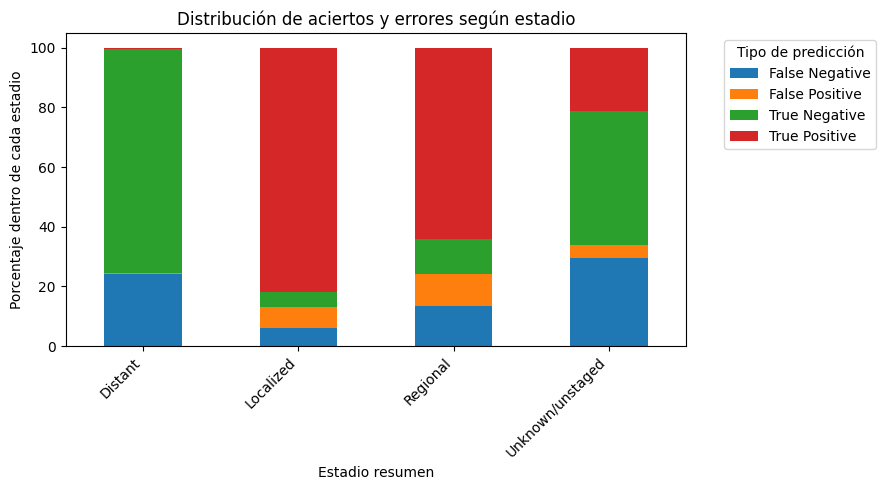

In [ ]:
error_by_stage_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(9, 5)
)

plt.title("Distribución de aciertos y errores según estadio")
plt.xlabel("Estadio resumen")
plt.ylabel("Porcentaje dentro de cada estadio")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Tipo de predicción", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

La distribución de aciertos y errores según `summary_stage` muestra patrones claramente diferenciados entre estadios.

En los pacientes con enfermedad `Distant`, el modelo identifica correctamente como no supervivientes al 75,20 % de los casos. Esto indica que, cuando la enfermedad está en estadio distante, el modelo tiende a reconocer adecuadamente el peor pronóstico. Sin embargo, también aparece un 24,32 % de falsos negativos, es decir, pacientes con enfermedad distante que sobreviven cinco años pero son clasificados como no supervivientes. En este grupo, los falsos positivos son prácticamente inexistentes, con un 0,12 %.

En los pacientes con enfermedad `Localized`, el modelo clasifica correctamente como supervivientes al 81,92 %. Esto es coherente con el buen pronóstico general de los casos localizados. No obstante, existe un 7,19 % de falsos positivos, correspondientes a pacientes con enfermedad localizada que no sobreviven cinco años pero que el modelo predice como supervivientes. Estos errores son clínicamente relevantes, ya que representan pacientes aparentemente de mejor pronóstico que finalmente presentan un desenlace desfavorable.

En la categoría `Regional`, el modelo muestra una distribución más equilibrada de errores. El 64,12 % son verdaderos positivos y el 11,79 % verdaderos negativos, pero aparecen también un 13,39 % de falsos negativos y un 10,71 % de falsos positivos. Esto sugiere que los casos regionales son más heterogéneos y difíciles de clasificar, probablemente porque agrupan pacientes con distintos grados de extensión tumoral y perfiles clínicos.

La categoría `Unknown/unstaged` presenta un comportamiento especialmente complejo. El 45,02 % de los casos son verdaderos negativos, pero también existe un 29,64 % de falsos negativos y solo un 21,25 % de verdaderos positivos. Esto confirma que la ausencia de estadificación introduce incertidumbre y puede agrupar perfiles clínicos muy distintos.

En conjunto, el análisis por estadio muestra que el modelo aprende patrones clínicamente plausibles: identifica bien el mal pronóstico de la enfermedad distante y el mejor pronóstico de la enfermedad localizada. Sin embargo, los errores se concentran en casos regionales, no estadificados y en pacientes localizados que presentan desenlaces peores de lo esperado.

## 9.4 Errores según grupo de edad

Se analiza la distribución de aciertos y errores según el grupo de edad. La edad ha aparecido como una variable relevante tanto en el análisis exploratorio como en la interpretabilidad de los modelos.

Este análisis permite comprobar si el modelo falla especialmente en pacientes jóvenes, de edad intermedia o de edad avanzada.

In [ ]:
error_by_age = (
    error_analysis_df
    .groupby(["age_group", "prediction_result"])
    .size()
    .reset_index(name="count")
)

error_by_age["percentage_within_age"] = (
    error_by_age
    .groupby("age_group")["count"]
    .transform(lambda x: x / x.sum() * 100)
    .round(2)
)

error_by_age_pivot = error_by_age.pivot(
    index="age_group",
    columns="prediction_result",
    values="percentage_within_age"
).fillna(0)

error_by_age_pivot

/tmp/ipykernel_3835/3988926394.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["age_group", "prediction_result"])
/tmp/ipykernel_3835/3988926394.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("age_group")["count"]


prediction_result,False Negative,False Positive,True Negative,True Positive
age_group,,,,
10-14 years,0.00,0.00,0.00,100.00
15-19 years,33.33,8.33,8.33,50.00
20-24 years,14.56,3.80,9.49,72.15
25-29 years,10.21,8.93,8.47,72.39
30-34 years,8.30,9.71,7.45,74.54
35-39 years,6.05,8.62,6.04,79.28
40-44 years,4.18,6.92,4.53,84.37
45-49 years,3.63,6.14,4.33,85.89
50-54 years,3.95,6.79,5.56,83.70


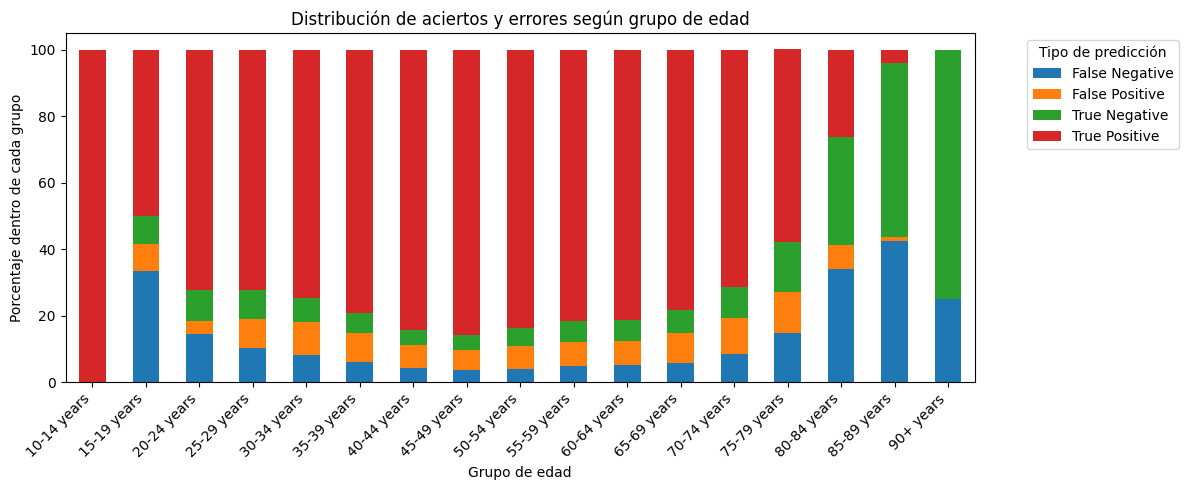

In [ ]:
error_by_age_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 5)
)

plt.title("Distribución de aciertos y errores según grupo de edad")
plt.xlabel("Grupo de edad")
plt.ylabel("Porcentaje dentro de cada grupo")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Tipo de predicción", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

La distribución de errores por grupo de edad muestra que el comportamiento del modelo varía de forma importante según la edad del paciente.

En los grupos de edad intermedia, especialmente entre `40-44 years` y `65-69 years`, el modelo presenta una proporción elevada de verdaderos positivos y una proporción relativamente baja de errores. Por ejemplo, en `45-49 years` el 85,89 % de los casos son verdaderos positivos, mientras que los falsos negativos representan el 3,63 % y los falsos positivos el 6,14 %. Este patrón es coherente con la mayor supervivencia observada en estos grupos durante el análisis exploratorio.

A partir de los 70 años se observa un cambio progresivo en el comportamiento del modelo. En `70-74 years`, los verdaderos positivos representan el 71,37 %, pero los falsos positivos aumentan hasta el 10,82 %. En `75-79 years`, los verdaderos positivos descienden al 57,78 % y aumentan tanto los verdaderos negativos como los falsos negativos.

En los grupos de edad avanzada, especialmente `80-84 years`, `85-89 years` y `90+ years`, el modelo tiende a clasificar una mayor proporción de pacientes como no supervivientes. En `85-89 years`, el 52,21 % de los casos son verdaderos negativos, pero también aparece un 42,45 % de falsos negativos. Esto indica que muchos pacientes de este grupo que sí sobreviven cinco años son clasificados erróneamente como no supervivientes. En `90+ years`, el modelo clasifica prácticamente todos los casos como no supervivientes, con un 75,00 % de verdaderos negativos y apenas un 0,09 % de verdaderos positivos.

En los grupos más jóvenes, los porcentajes deben interpretarse con cautela debido al menor tamaño muestral. Por ejemplo, categorías como `10-14 years` o `15-19 years` tienen muy pocos casos, por lo que pequeñas variaciones pueden generar porcentajes extremos.

En conjunto, el análisis confirma que la edad condiciona fuertemente el comportamiento del modelo. El modelo funciona de forma más estable en edades intermedias, mientras que en edades avanzadas tiende a asumir un peor pronóstico, lo que aumenta los falsos negativos en pacientes mayores que finalmente sí sobreviven cinco años.

## 9.5 Errores según variables de tratamiento

Se analiza la distribución de errores según algunas variables de tratamiento. Este análisis permite comprobar si el modelo falla de forma diferencial en pacientes con determinados códigos quirúrgicos o categorías de radioterapia.

Como en apartados anteriores, estas asociaciones deben interpretarse con cautela, ya que las variables de tratamiento proceden de datos observacionales y pueden estar condicionadas por el perfil clínico inicial del paciente.

### 9.5.1 Errores según cirugía sobre el sitio primario

In [ ]:
error_by_surgery = (
    error_analysis_df
    .groupby(["surgery_primary_site", "prediction_result"])
    .size()
    .reset_index(name="count")
)

error_by_surgery["percentage_within_surgery"] = (
    error_by_surgery
    .groupby("surgery_primary_site")["count"]
    .transform(lambda x: x / x.sum() * 100)
    .round(2)
)

# Se muestran únicamente los códigos quirúrgicos más frecuentes para facilitar la interpretación
top_surgery_codes = (
    error_analysis_df["surgery_primary_site"]
    .value_counts()
    .head(15)
    .index
)

error_by_surgery_pivot = (
    error_by_surgery[
        error_by_surgery["surgery_primary_site"].isin(top_surgery_codes)
    ]
    .pivot(
        index="surgery_primary_site",
        columns="prediction_result",
        values="percentage_within_surgery"
    )
    .fillna(0)
)

error_by_surgery_pivot

/tmp/ipykernel_3835/1820384949.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["surgery_primary_site", "prediction_result"])
/tmp/ipykernel_3835/1820384949.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("surgery_primary_site")["count"]


prediction_result,False Negative,False Positive,True Negative,True Positive
surgery_primary_site,,,,
0,29.30,1.28,64.12,5.30
20,4.87,7.99,4.62,82.53
22,5.72,7.82,4.92,81.53
23,2.36,6.85,1.42,89.37
24,4.58,7.45,4.01,83.96
30,0.75,5.86,0.75,92.64
40,11.14,9.65,10.41,68.79
41,11.38,9.84,9.50,69.28
42,2.59,8.30,1.68,87.43


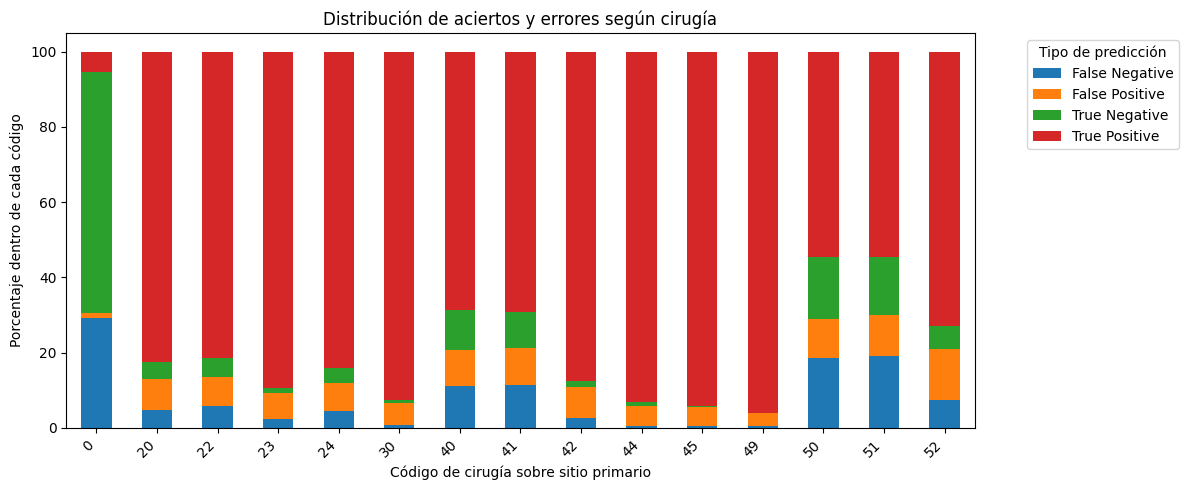

In [ ]:
error_by_surgery_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 5)
)

plt.title("Distribución de aciertos y errores según cirugía")
plt.xlabel("Código de cirugía sobre sitio primario")
plt.ylabel("Porcentaje dentro de cada código")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Tipo de predicción", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

La distribución de errores según `surgery_primary_site` muestra diferencias importantes entre códigos quirúrgicos.

El código `0` presenta un patrón claramente asociado a peor pronóstico. En este grupo, el 64,12 % de los casos son verdaderos negativos, es decir, pacientes que no sobreviven cinco años y son correctamente clasificados como no supervivientes. Sin embargo, también aparece un 29,30 % de falsos negativos, correspondientes a pacientes que sí sobreviven cinco años pero que el modelo clasifica como no supervivientes. Esto indica que el modelo tiende a asignar mal pronóstico a gran parte de los pacientes con este código.

Los códigos `20`, `22`, `23`, `24`, `30`, `42`, `44`, `45` y `49` presentan una proporción elevada de verdaderos positivos, generalmente superior al 80 %. En particular, los códigos `45` y `49` alcanzan proporciones de verdaderos positivos del 94,16 % y 95,97 %, respectivamente, lo que sugiere que el modelo identifica estos grupos como perfiles de mejor pronóstico.

Los códigos `50` y `51` presentan un patrón más complejo, con porcentajes relativamente altos de falsos negativos y verdaderos negativos. En ambos casos, aproximadamente el 55 % de los registros son verdaderos positivos, pero también aparecen porcentajes de falsos negativos cercanos al 19 % y verdaderos negativos en torno al 16 %. Esto sugiere que estos códigos agrupan pacientes con perfiles más heterogéneos o de mayor dificultad predictiva.

El código `52` muestra una proporción elevada de falsos positivos, del 13,63 %, lo que indica que en este grupo el modelo clasifica como supervivientes a una parte relevante de pacientes que realmente no alcanzan los cinco años.

En conjunto, este análisis confirma que la variable quirúrgica tiene una fuerte influencia en el comportamiento del modelo. No obstante, la interpretación clínica exacta requiere consultar la codificación específica de SEER, ya que los códigos representan procedimientos o situaciones quirúrgicas concretas y no deben interpretarse como valores numéricos ordinales.

### 9.5.2 Errores según radioterapia

Se analiza la distribución de aciertos y errores según la variable `radiation`. Esta variable fue relevante en el análisis exploratorio y aparece también entre las variables importantes del modelo XGBoost.

El objetivo es comprobar si los errores del modelo se distribuyen de forma diferente entre pacientes con radioterapia registrada, ausencia o desconocimiento de radioterapia, rechazo del tratamiento u otras modalidades.

In [ ]:
error_by_radiation = (
    error_analysis_df
    .groupby(["radiation", "prediction_result"])
    .size()
    .reset_index(name="count")
)

error_by_radiation["percentage_within_radiation"] = (
    error_by_radiation
    .groupby("radiation")["count"]
    .transform(lambda x: x / x.sum() * 100)
    .round(2)
)

error_by_radiation_pivot = error_by_radiation.pivot(
    index="radiation",
    columns="prediction_result",
    values="percentage_within_radiation"
).fillna(0)

error_by_radiation_pivot

/tmp/ipykernel_3835/4174515986.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby(["radiation", "prediction_result"])
/tmp/ipykernel_3835/4174515986.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("radiation")["count"]


prediction_result,False Negative,False Positive,True Negative,True Positive
radiation,,,,
Beam radiation,4.40,7.74,4.83,83.03
Combination of beam with implants or isotopes,3.49,7.53,1.88,87.10
None/Unknown,14.54,7.77,18.24,59.45
"Radiation, NOS method or source not specified",7.23,7.14,8.80,76.83
Radioactive implants (includes brachytherapy) (1988+),0.52,5.64,0.55,93.29
Radioisotopes (1988+),4.05,5.41,4.05,86.49
"Recommended, unknown if administered",9.20,10.05,7.17,73.57
Refused (1988+),21.34,8.63,21.89,48.14


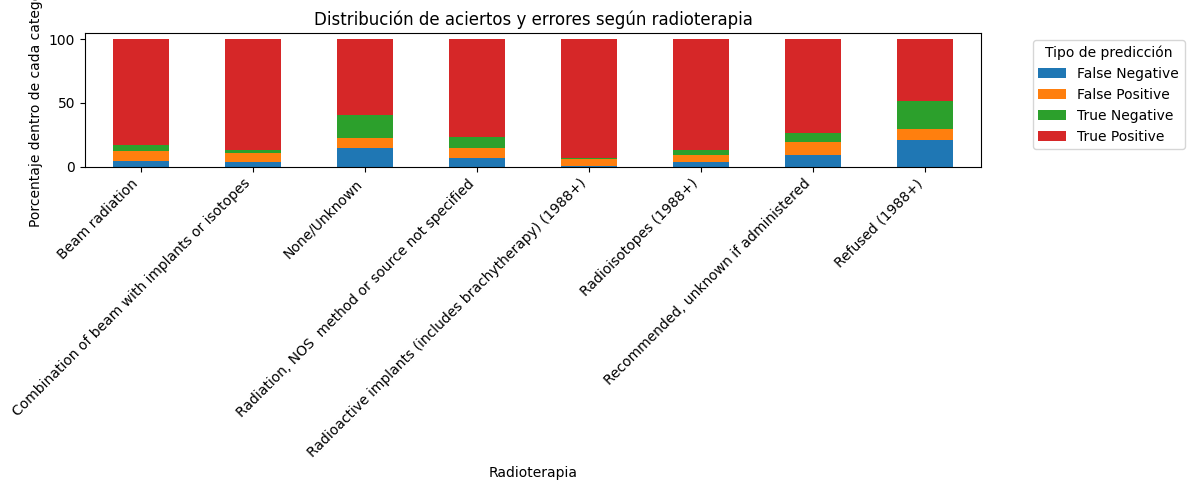

In [ ]:
error_by_radiation_pivot.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 5)
)

plt.title("Distribución de aciertos y errores según radioterapia")
plt.xlabel("Radioterapia")
plt.ylabel("Porcentaje dentro de cada categoría")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Tipo de predicción", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()

La distribución de errores según `radiation` muestra que el comportamiento del modelo varía de forma relevante entre categorías de radioterapia.

En la categoría `Beam radiation`, que era una de las más frecuentes en el dataset, el modelo clasifica correctamente como supervivientes al 83,03 % de los pacientes. Los falsos positivos representan el 7,74 % y los falsos negativos el 4,40 %, lo que indica un comportamiento relativamente estable en este grupo.

Las categorías asociadas a modalidades específicas de radioterapia, como `Radioactive implants`, `Combination of beam with implants or isotopes` y `Radioisotopes`, presentan porcentajes elevados de verdaderos positivos, superiores al 86 %. En particular, `Radioactive implants` alcanza un 93,29 % de verdaderos positivos. No obstante, estas categorías son menos frecuentes, por lo que su interpretación debe realizarse con cautela.

La categoría `None/Unknown` presenta un patrón más heterogéneo. Aunque el 59,45 % de los casos son verdaderos positivos, también aparece un 18,24 % de verdaderos negativos y un 14,54 % de falsos negativos. Esto sugiere que esta categoría agrupa perfiles muy distintos, ya que combina ausencia de radioterapia con información desconocida.

La categoría `Refused (1988+)` muestra un comportamiento especialmente relevante: solo el 48,14 % de los casos son verdaderos positivos, mientras que los verdaderos negativos representan el 21,89 % y los falsos negativos el 21,34 %. Esto indica que el modelo tiende a asociar esta categoría con peor pronóstico, aunque también clasifica erróneamente como no supervivientes a una proporción importante de pacientes que sí sobreviven cinco años.

La categoría `Recommended, unknown if administered` presenta un 10,05 % de falsos positivos, lo que indica cierta dificultad para identificar correctamente a pacientes que no sobreviven cinco años dentro de este grupo.

En conjunto, el análisis confirma que las variables de tratamiento influyen en el comportamiento del modelo, pero su interpretación debe realizarse con prudencia. Las categorías de radioterapia no reflejan únicamente el tratamiento recibido, sino también decisiones clínicas, características del tumor, estadio, perfil del paciente y posibles limitaciones de registro.

## 9.6 Síntesis del análisis de errores

El análisis de errores permite comprender mejor el comportamiento del modelo seleccionado más allá de las métricas agregadas.

El XGBoost optimizado con umbral ajustado clasifica correctamente a la mayoría de pacientes supervivientes y obtiene un equilibrio más favorable entre precisión y recall para la clase de no supervivencia. Sin embargo, todavía existen errores clínicamente relevantes, especialmente falsos positivos desde la perspectiva de la clase superviviente: pacientes que realmente no sobreviven cinco años pero son clasificados como supervivientes.

El análisis de probabilidades muestra que los verdaderos negativos suelen recibir probabilidades bajas de supervivencia, mientras que los verdaderos positivos presentan probabilidades elevadas. No obstante, los falsos positivos tienen probabilidades medias relativamente altas de supervivencia, lo que indica que algunos errores se producen con un nivel de confianza considerable. Esto sugiere que existen factores pronósticos no recogidos en las variables disponibles.

Por estadio, el modelo identifica bien el peor pronóstico de la enfermedad distante y el mejor pronóstico de la enfermedad localizada. Sin embargo, aparecen errores relevantes en pacientes con enfermedad regional, no estadificada y en casos localizados con desenlace desfavorable.

Por edad, el modelo funciona de forma más estable en grupos de edad intermedia, mientras que en edades avanzadas tiende a asumir un peor pronóstico. Esto genera falsos negativos en pacientes mayores que sí sobreviven cinco años.

Las variables de tratamiento también muestran patrones diferenciados de error. Algunos códigos quirúrgicos y categorías de radioterapia concentran mayor proporción de errores, aunque estas asociaciones deben interpretarse con cautela debido al carácter observacional del dataset.

En conjunto, el análisis de errores confirma que el modelo aprende patrones clínicamente plausibles, pero también evidencia sus limitaciones. Los errores pueden estar relacionados con información no disponible en el dataset, como comorbilidades, biomarcadores moleculares, recurrencias, adherencia al tratamiento, estado funcional o detalles terapéuticos más precisos.

Este análisis refuerza la necesidad de interpretar el modelo como una herramienta de apoyo a la estratificación de riesgo, no como un sistema autónomo de decisión clínica.

# 10. Conclusiones experimentales y limitaciones

En esta sección se sintetizan los principales resultados obtenidos a lo largo del notebook experimental. El objetivo es recoger las conclusiones más relevantes del proceso completo, desde la preparación de los datos hasta la evaluación e interpretación de los modelos predictivos.

También se identifican las principales limitaciones metodológicas del trabajo, especialmente aquellas derivadas del uso de datos observacionales, la definición de la variable objetivo y la información disponible en el registro SEER.

## 10.1 Conclusiones sobre el dataset y la limpieza

El trabajo se ha desarrollado utilizando un conjunto de datos procedente del programa SEER, centrado en pacientes diagnosticados de cáncer de mama. El dataset inicial contenía un volumen elevado de observaciones y variables clínico-epidemiológicas, lo que permitió plantear el problema desde una perspectiva propia de Big Data Science.

Durante la fase de limpieza y preparación se identificaron varios aspectos relevantes:

- La existencia de valores especiales como `Blank(s)`, `Unknown`, `Unknown/unstaged`, `999`, `99`, `No/Unknown` o `None/Unknown`.
- La necesidad de convertir `survival_months` a formato numérico.
- La exclusión de registros con supervivencia desconocida.
- La eliminación de variables sin variabilidad, como `behavior_code`.
- La exclusión de variables EOD 2018 del modelo principal por su disponibilidad temporal limitada.
- La eliminación de variables directamente relacionadas con el desenlace para evitar fuga de información.

Una decisión metodológica especialmente importante fue restringir el dataset principal de modelado al periodo 2000--2017. Esta restricción se aplicó porque los años 2018--2022 no disponían de seguimiento suficiente para evaluar de forma comparable la supervivencia a cinco años. Tras esta decisión, el dataset principal quedó formado por 996.916 observaciones.

## 10.2 Conclusiones sobre la variable objetivo

La variable objetivo `survived_5_years` se definió como una variable binaria:

- `1`: pacientes que sobreviven al menos 60 meses desde el diagnóstico.
- `0`: pacientes que fallecen antes de alcanzar los 60 meses.

La definición de esta variable requirió tratar adecuadamente la censura. En particular, los pacientes vivos con menos de 60 meses de seguimiento fueron excluidos, ya que no era posible determinar de forma fiable si alcanzarían o no la supervivencia a cinco años.

Tras restringir el dataset al periodo 2000--2017, la variable objetivo presentó una distribución moderadamente desbalanceada:

- 803.498 pacientes sobrevivieron al menos cinco años, representando el 80,60 %.
- 193.418 pacientes fallecieron antes de cinco años, representando el 19,40 %.

Este desbalance condicionó la selección de métricas y justificó prestar especial atención a la clase minoritaria, correspondiente a pacientes con peor pronóstico.

## 10.3 Conclusiones del análisis exploratorio

El análisis exploratorio permitió identificar asociaciones descriptivas relevantes entre las variables disponibles y la supervivencia a cinco años.

Entre los patrones más destacados se encuentran:

- La edad mostró una relación clara con la supervivencia. Los grupos de edad intermedia presentaron tasas de supervivencia más elevadas, mientras que los grupos de edad avanzada mostraron una disminución progresiva del pronóstico.
- La variable `summary_stage` presentó una de las asociaciones más fuertes con la supervivencia. Los pacientes con enfermedad localizada tuvieron una supervivencia muy superior a los pacientes con enfermedad distante.
- La variable `tumor_size` mostró patrones clínicamente plausibles en los valores informados, pero su utilidad quedó limitada por la elevada proporción de valores `Blank(s)`.
- Algunas variables codificadas, como `primary_site`, `histologic_type` y `surgery_primary_site`, mostraron diferencias relevantes entre categorías, aunque deben interpretarse como variables categóricas y no numéricas.
- Las variables de tratamiento, como cirugía, radioterapia y quimioterapia, presentaron asociaciones descriptivas con la supervivencia, pero no pueden interpretarse causalmente debido al carácter observacional del dataset.

Este análisis permitió orientar las decisiones de preprocesamiento y confirmó que las variables disponibles contienen señal predictiva útil para el modelado.

## 10.4 Conclusiones del modelado predictivo

Se entrenaron y evaluaron distintos modelos de clasificación supervisada para predecir la supervivencia a cinco años:

- Regresión logística baseline.
- Random Forest.
- XGBoost.
- XGBoost optimizado mediante búsqueda aleatoria ligera.

Los resultados mostraron que todos los modelos alcanzaron una capacidad predictiva razonable, con valores de AUC-ROC en torno a 0,82--0,83.

La regresión logística obtuvo un rendimiento muy competitivo, con una accuracy de 0,7808 y un AUC-ROC de 0,8274. Este resultado es relevante porque se trata de un modelo simple e interpretable, lo que lo convierte en una referencia sólida para un contexto sanitario.

El Random Forest no mejoró al baseline, obteniendo un AUC-ROC de 0,8219. Por su parte, el XGBoost inicial alcanzó un AUC-ROC de 0,8282, ligeramente superior al baseline. La optimización ligera de XGBoost permitió mejorar el AUC-ROC hasta 0,8316, convirtiéndolo en el modelo con mayor capacidad discriminativa global.

No obstante, la mejora del XGBoost optimizado respecto a la regresión logística fue de magnitud reducida. Mediante intervalos de confianza por bootstrap del 95 % se comprobó que dicha mejora es estadísticamente apreciable —los intervalos de ambos modelos apenas se solapan (logística: 0,8251–0,8297; XGBoost: 0,8294–0,8339)—, si bien su relevancia práctica es limitada, en torno a 0,004 puntos de AUC. Este resultado sugiere que gran parte de la señal predictiva disponible puede capturarse mediante relaciones relativamente simples, y que el uso de modelos más complejos no garantiza necesariamente una mejora sustancial.

Dado el contexto clínico del problema, la selección del modelo no se basó únicamente en la accuracy. Se priorizó también el recall y el F1-score de la clase `No sobrevive 5 años`, ya que esta clase representa a los pacientes de mayor interés clínico.

## 10.5 Conclusiones sobre el ajuste de umbral

Además de comparar modelos, se realizó un ajuste del umbral de decisión del XGBoost optimizado. Esta fase permitió adaptar el comportamiento del modelo al objetivo clínico del proyecto.

Con el umbral por defecto de 0,50, el modelo presentaba mayor recall para la clase `No sobrevive 5 años`, identificando una mayor proporción de pacientes de peor pronóstico. Sin embargo, esta configuración tenía menor precisión para dicha clase.

Al ajustar el umbral a 0,38, se obtuvo un mejor equilibrio entre precisión y recall para la clase 0. En concreto:

- La precisión de la clase 0 aumentó hasta 0,5457.
- El recall de la clase 0 fue 0,5985.
- El F1-score de la clase 0 mejoró hasta 0,5709.
- La accuracy global aumentó hasta 0,8254.

Este resultado muestra que el umbral de decisión tiene un impacto relevante en el comportamiento del modelo. En un contexto clínico, la elección del umbral debe depender del objetivo prioritario: maximizar la detección de pacientes de alto riesgo o buscar un equilibrio más estable entre precisión y recall.

En este trabajo, el XGBoost optimizado con umbral ajustado se considera una alternativa equilibrada, mientras que el umbral por defecto se mantiene como referencia cuando se prioriza la sensibilidad hacia pacientes de peor pronóstico.

## 10.6 Conclusiones sobre interpretabilidad

El análisis de interpretabilidad permitió comprobar que los modelos se apoyan en variables clínicamente plausibles.

En la regresión logística, los coeficientes positivos se asociaron con mayor probabilidad estimada de supervivencia a cinco años. Entre ellos destacaron la enfermedad localizada, edades intermedias, tamaños tumorales pequeños y determinados códigos quirúrgicos e histológicos.

Los coeficientes negativos se asociaron con menor probabilidad estimada de supervivencia. Entre los factores más relevantes aparecieron la edad avanzada, la enfermedad distante, determinados códigos histológicos, códigos quirúrgicos asociados a peor pronóstico y el rechazo de radioterapia.

En el XGBoost optimizado, las variables más importantes estuvieron relacionadas con cirugía, estadio, edad, estado civil, histología, radioterapia y raza. Destacaron especialmente `surgery_primary_site_0`, `summary_stage_Distant` y grupos de edad avanzada.

La comparación entre ambos modelos mostró coincidencias relevantes en variables como edad, estadio, cirugía e histología. Esta coherencia refuerza la validez de los patrones aprendidos y sugiere que los modelos no están basando sus predicciones en variables arbitrarias.

No obstante, algunas variables importantes requieren interpretación cautelosa, especialmente aquellas relacionadas con códigos administrativos, valores desconocidos o tratamientos observacionales.

## 10.7 Conclusiones del análisis de errores

El análisis de errores permitió estudiar en mayor detalle los casos en los que el modelo falla.

El modelo XGBoost optimizado con umbral ajustado clasificó correctamente a la mayoría de pacientes supervivientes y mostró un equilibrio razonable entre precisión y recall para la clase de no supervivencia. Sin embargo, persistieron errores clínicamente relevantes.

Los falsos positivos, es decir, pacientes que realmente no sobreviven cinco años pero son clasificados como supervivientes, representan un tipo de error especialmente delicado, ya que implican no identificar adecuadamente a pacientes de peor pronóstico.

El análisis por probabilidades mostró que los verdaderos negativos suelen recibir probabilidades bajas de supervivencia, mientras que los verdaderos positivos presentan probabilidades elevadas. Sin embargo, algunos falsos positivos reciben probabilidades moderadas o altas de supervivencia, lo que sugiere la existencia de factores pronósticos no recogidos por las variables disponibles.

El análisis por estadio mostró que el modelo identifica bien el mal pronóstico de la enfermedad distante y el buen pronóstico de la enfermedad localizada, aunque presenta más dificultad en casos regionales, no estadificados o localizados con desenlace desfavorable.

Por edad, el modelo funciona mejor en grupos intermedios y tiende a asumir peor pronóstico en edades avanzadas. Esto genera errores en pacientes mayores que finalmente sí sobreviven cinco años.

En conjunto, el análisis de errores confirma que el modelo aprende patrones coherentes, pero también evidencia limitaciones propias de los datos disponibles.

## 10.8 Limitaciones del trabajo

Aunque los resultados obtenidos son sólidos y metodológicamente coherentes, el trabajo presenta varias limitaciones que deben tenerse en cuenta.

En primer lugar, el estudio se basa en datos observacionales procedentes de un registro poblacional. Esto implica que las asociaciones encontradas no deben interpretarse como relaciones causales. En particular, las variables de tratamiento pueden estar condicionadas por el estado clínico del paciente, el estadio tumoral, la edad, las preferencias terapéuticas y otros factores no observados.

En segundo lugar, la formulación del problema como clasificación binaria simplifica la naturaleza temporal de la supervivencia. Aunque la supervivencia a cinco años es un indicador ampliamente utilizado, el uso de una etiqueta binaria implica perder información temporal detallada. Un enfoque complementario sería aplicar modelos específicos de análisis de supervivencia.

En tercer lugar, fue necesario excluir pacientes vivos con menos de 60 meses de seguimiento para evitar etiquetas inciertas. Esta decisión mejora la fiabilidad de la variable objetivo, pero reduce el número de registros disponibles y obliga a restringir el periodo principal de modelado a 2000--2017.

En cuarto lugar, algunas variables presentan valores desconocidos o no informados. Destaca especialmente `tumor_size`, con una proporción muy elevada de valores `Blank(s)`, lo que limita su utilidad directa.

En quinto lugar, el dataset no incluye información clínica potencialmente relevante, como biomarcadores moleculares, comorbilidades, estado funcional, recurrencias, adherencia al tratamiento, características genéticas o detalles terapéuticos más específicos.

En sexto lugar, la validación se ha realizado mediante una partición train-test interna. Aunque esta estrategia permite evaluar el rendimiento sobre datos no utilizados durante el entrenamiento, sería necesario realizar validación externa con otros conjuntos de datos para valorar la generalización del modelo.

Finalmente, los modelos desarrollados deben entenderse como herramientas experimentales de apoyo a la estratificación de riesgo, no como sistemas autónomos de decisión clínica.

## 10.9 Conclusión general

El notebook ha desarrollado un pipeline completo de análisis predictivo para estimar la supervivencia a cinco años en pacientes con cáncer de mama utilizando datos clínico-epidemiológicos del programa SEER.

El proceso ha incluido la carga y comprensión del dataset, limpieza inicial, tratamiento de valores especiales, definición rigurosa de la variable objetivo, análisis exploratorio, preprocesamiento, entrenamiento de modelos, ajuste de umbral, interpretabilidad y análisis de errores.

Los resultados muestran que es posible obtener modelos con capacidad predictiva razonable utilizando variables clínicas, demográficas y de tratamiento disponibles en registros poblacionales. El mejor modelo en términos de AUC-ROC fue el XGBoost optimizado, mientras que la regresión logística destacó por su simplicidad e interpretabilidad.

Desde una perspectiva clínica, el trabajo demuestra la importancia de no evaluar los modelos únicamente mediante accuracy. En este problema, la identificación de pacientes que no alcanzan la supervivencia a cinco años es especialmente relevante, por lo que métricas como recall, F1-score de la clase minoritaria y AUC-ROC deben ocupar un papel central.

El análisis de interpretabilidad y errores confirma que los modelos aprenden patrones coherentes con el conocimiento clínico, especialmente relacionados con edad, estadio, cirugía e histología. Sin embargo, también pone de manifiesto limitaciones relevantes derivadas de la naturaleza observacional del dataset y de la ausencia de información clínica adicional.

En conjunto, el trabajo proporciona una base sólida para el desarrollo de modelos predictivos de supervivencia a cinco años en cáncer de mama, manteniendo una perspectiva prudente, interpretable y alineada con las exigencias de un contexto sanitario.